# Modelo de Fidelización y Recompra — Online Retail II

**Máster en Ciencia de Datos e IA — Evolve Academy**  
**Autor:** Alejandro Pujana Quintero  
**Dataset:** Online Retail II — transacciones 01/12/2009 al 09/12/2011  
**Objetivo:** Clasificación binaria para predecir qué clientes volverán a comprar
después de una fecha de corte, con el fin de lanzar acciones diferenciadas de
fidelización (alta probabilidad) y retención (baja probabilidad).

## Índice

1. [Carga e inspección inicial](#seccion-1)
2. [Limpieza de datos](#seccion-2)
3. [Análisis Exploratorio](#seccion-3)
4. [Construcción del dataset de modelado](#seccion-4)
5. [Feature Engineering y preprocesamiento](#seccion-5)
6. [Modelado](#seccion-6)
7. [Optimización con Optuna](#seccion-7)
8. [Evaluación final](#seccion-8)
9. [Explicabilidad](#seccion-9)
10. [Conclusiones y recomendaciones de negocio](#seccion-10)

In [743]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Localización automática de la raíz del proyecto ──────────────────────────
# El kernel puede arrancar desde distintos directorios según la configuración.
# Subimos niveles hasta encontrar la carpeta DATA/ para fijar la raíz.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd
for _ in range(5):
    if (PROJECT_ROOT / 'DATA').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
print(f'Directorio de trabajo: {PROJECT_ROOT}')

# ── Rutas ─────────────────────────────────────────────────────────────────────
RAW_DATA   = PROJECT_ROOT / 'DATA' / 'raw_data'
CLEAN_DATA = PROJECT_ROOT / 'DATA' / 'clean_data'
CLEAN_DATA.mkdir(parents=True, exist_ok=True)  # crea la carpeta si no existe (reproducibilidad)

CSV_2009   = RAW_DATA  / 'online_retail_II.xlsx - Year 2009-2010.csv'
CSV_2010   = RAW_DATA  / 'online_retail_II.xlsx - Year 2010-2011.csv'
PKL_PATH   = CLEAN_DATA / 'online_retail_clean.pkl'
PKL_CANCEL = CLEAN_DATA / 'online_retail_cancel.pkl'

# ── Configuración de visualización ───────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Librerías cargadas correctamente.')

Directorio de trabajo: /Users/usuario/Downloads/DATA_SCIENCE/Quinto_Módulo_ML/Proyecto_ML_Pujana
Librerías cargadas correctamente.


---
<a id="seccion-1"></a>
## 1. Carga e inspección inicial

El dataset original se distribuye en dos hojas Excel que cubren períodos consecutivos:

| Archivo | Período | Filas aprox. |
|---|---|---|
| Year 2009-2010.csv | 01/12/2009 → 09/12/2010 | ~525.000 |
| Year 2010-2011.csv | 01/12/2010 → 09/12/2011 | ~542.000 |

Ambas hojas se concatenan en un único dataset. Existe un solapamiento de 9 días
en diciembre de 2010 (~23.000 filas duplicadas) que se elimina automáticamente.

Usar el dataset completo (2009-2011) permite tener ~21 meses de historial de
compra para construir features robustas, con la fecha de corte fijada en el
**30 de septiembre de 2011** y los últimos 3 meses (oct-dic 2011) como ventana
de etiqueta para la variable `recompra`.

La transformación central del proyecto convierte estas ~1.000.000 filas de
registro transaccional en ~5.900 filas de perfil de cliente — una por persona —
resumiendo su historial de compra. Esa agregación ocurre en la sección 4;
aquí limpiamos el registro bruto para que sea fiable.

**Columnas del dataset:**

| Columna | Tipo | Descripción |
|---|---|---|
| `Invoice` | string | Identificador de factura. Empieza por 'C' si es cancelación |
| `StockCode` | string | Código del producto |
| `Description` | string | Descripción del producto |
| `Quantity` | int | Unidades compradas (negativo = devolución/ajuste interno) |
| `InvoiceDate` | datetime | Fecha y hora de la transacción |
| `Price` | float | Precio unitario en libras esterlinas |
| `Customer ID` | string | Identificador del cliente (puede ser nulo) |
| `Country` | string | País del cliente |

In [744]:
# Carga de ambas hojas con el mismo formato de fecha y tipo de Customer ID.
# date_format='%m/%d/%y %H:%M' especifica el patrón exacto (ej: 12/1/09 7:45).
read_params = dict(
    parse_dates=['InvoiceDate'],
    date_format='%m/%d/%y %H:%M',
    dtype={'Customer ID': str}
)

df_2009 = pd.read_csv(CSV_2009, **read_params)
df_2010 = pd.read_csv(CSV_2010, **read_params)

print(f'Hoja 2009-2010: {len(df_2009):,} filas  |  '
      f'{df_2009["InvoiceDate"].min().date()} → {df_2009["InvoiceDate"].max().date()}')
print(f'Hoja 2010-2011: {len(df_2010):,} filas  |  '
      f'{df_2010["InvoiceDate"].min().date()} → {df_2010["InvoiceDate"].max().date()}')

Hoja 2009-2010: 525,461 filas  |  2009-12-01 → 2010-12-09
Hoja 2010-2011: 541,910 filas  |  2010-12-01 → 2011-12-09


In [745]:
# Concatenamos y eliminamos filas duplicadas del solapamiento de diciembre 2010.
# ignore_index=True reinicia el índice; drop_duplicates() elimina filas idénticas.
df_raw = pd.concat([df_2009, df_2010], ignore_index=True).drop_duplicates()

print(f'Dataset combinado: {len(df_raw):,} filas únicas')
print(f'Rango temporal:    {df_raw["InvoiceDate"].min().date()} → {df_raw["InvoiceDate"].max().date()}')

Dataset combinado: 1,033,036 filas únicas
Rango temporal:    2009-12-01 → 2011-12-09


In [746]:
# Resumen estructural: tipo de cada columna y cuántos valores no nulos tiene.
df_raw.info()

<class 'pandas.DataFrame'>
Index: 1033036 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1033036 non-null  str           
 1   StockCode    1033036 non-null  str           
 2   Description  1028761 non-null  str           
 3   Quantity     1033036 non-null  int64         
 4   InvoiceDate  1033036 non-null  datetime64[us]
 5   Price        1033036 non-null  float64       
 6   Customer ID  797885 non-null   str           
 7   Country      1033036 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 70.9 MB


### 1.1 Estadísticas descriptivas

`describe()` por defecto solo muestra columnas numéricas (Quantity y Price).
Para columnas de texto usamos `describe(include='object')`, que devuelve cuatro
estadísticas: `count` (valores no nulos), `unique` (valores distintos),
`top` (valor más frecuente) y `freq` (cuántas veces aparece ese top).
Los números en `count`, `unique` y `freq` son estadísticas, no valores de columna.

In [747]:
# Variables numéricas: mínimos negativos en Quantity y Price confirman necesidad de limpiar.
print('=== Variables numéricas ===')
df_raw.describe()

=== Variables numéricas ===


,Quantity,InvoiceDate,Price
count,"1,033,036.00",1033036,"1,033,036.00"
mean,10.08,2011-01-03 14:30:35.429548,4.61
min,"-80,995.00",2009-12-01 07:45:00,"-53,594.36"
25%,1.00,2010-07-05 11:38:00,1.25
50%,3.00,2010-12-09 13:34:00,2.10
75%,10.00,2011-07-27 13:17:00,4.15
max,"80,995.00",2011-12-09 12:50:00,"38,970.00"
std,175.20,NaN,122.40


In [748]:
# Variables de texto: cardinalidad (unique), valor más frecuente (top) y su frecuencia.
print('=== Variables de texto ===')
df_raw.describe(include='object')

=== Variables de texto ===


/var/folders/gr/x74fxxks023bs6mqtcx2022r0000gn/T/ipykernel_15913/3992224359.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include='object')


,Invoice,StockCode,Description,Customer ID,Country
count,1033036,1033036,1028761,797885,1033036
unique,53628,5305,5698,5942,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17841,United Kingdom
freq,1114,5653,5740,12638,948321


### 1.2 Valores nulos

Solo dos columnas tienen valores faltantes:

- **Description (~0,5%):** Texto libre que no entra al modelo como variable predictora.

- **Customer ID (~20%):** Compras *guest* (sin cuenta registrada). El cliente compra
  sin crear cuenta y el sistema no puede asignarle un ID. No es un error del dataset
  sino una limitación real del negocio que se documenta como tal.

> *Equivalente econométrico:* los nulos en Customer ID equivalen a observaciones
> sin identificador de individuo en un panel de datos — imposibles de incluir en
> una regresión de efectos fijos por individuo.

In [749]:
# Conteo y porcentaje de nulos. Solo muestra las columnas con algún nulo.
nulos     = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)

nulos_df = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0]

print('=== Valores nulos por columna ===')
print(nulos_df.to_string())

=== Valores nulos por columna ===
              Nulos  % del total
Description    4275         0.41
Customer ID  235151        22.76


---
<a id="seccion-2"></a>
## 2. Limpieza de datos

Cada paso de limpieza responde a una misma pregunta: **¿esta fila representa una
compra real de un cliente identificado?** Si la respuesta es no, la fila no aporta
información útil para predecir comportamiento de recompra.

El principio guía es el mismo que en econometría al definir la muestra de una
regresión: toda exclusión debe tener justificación explícita y cuantificarse su
impacto en el N disponible.

In [750]:
# Punto de partida: N del dataset combinado y deduplicado; copia de trabajo.
# La lista 'impacto' acumulará el efecto de cada paso para la tabla resumen final.
n_original = len(df_raw)
df = df_raw.copy()
impacto = []

print(f'Punto de partida: {n_original:,} filas')

Punto de partida: 1,033,036 filas


### 2.1 Extracción de datos de cancelación

En este dataset, las devoluciones de clientes se registran como facturas de
cancelación con prefijo 'C'. Antes de eliminarlas del flujo principal las
extraemos, ya que contienen información de comportamiento útil para el modelo.
En la sección 4 construiremos dos variables por cliente:

- `ratio_cancelaciones`: unidades canceladas / unidades compradas totales
- `tiene_cancelaciones`: 1 si el cliente canceló alguna vez, 0 si nunca canceló

Ambas variables se unirán al perfil de cada cliente mediante un `merge` sobre
`Customer ID` al construir el dataset de modelado.

**Nota sobre Quantity < 0 fuera de facturas 'C':** son ajustes internos de
inventario (pérdidas, daños de almacén) con Price = 0 y sin Customer ID —
no representan devoluciones de clientes y se eliminan al filtrar Customer ID nulo.

> *Equivalente econométrico:* extraer una variable de control antes de restringir
> la muestra, para poder usarla como regresor en el modelo final.

In [751]:
# Extraemos cancelaciones con Customer ID ANTES de eliminarlas del flujo principal.
df_cancel = df[
    df['Invoice'].str.startswith('C') & df['Customer ID'].notna()
].copy()

print(f'Filas de cancelación con Customer ID: {len(df_cancel):,}')
print(f'Clientes únicos con cancelaciones:    {df_cancel["Customer ID"].nunique():,}')

Filas de cancelación con Customer ID: 18,390
Clientes únicos con cancelaciones:    2,572


### 2.2 Eliminación de cancelaciones del flujo principal

**Decisión:** Eliminar del dataset de compras todas las facturas cuyo código
comienza por 'C'.

**Justificación:** Las cancelaciones no representan comportamiento de compra.
Si las incluimos, un cliente que cancela frecuentemente aparecería con alta
**Frecuencia** en el RFM — una señal falsa que el modelo aprendería de forma
incorrecta.

> *Equivalente econométrico:* igual que excluir observaciones con errores de
> medida en la variable dependiente — si Y tiene ruido sistemático, el modelo
> aprende ese ruido, no la señal real.

In [752]:
# ~ invierte la máscara booleana: conservamos solo facturas que NO empiezan por 'C'.
n_antes      = len(df)
df           = df[~df['Invoice'].str.startswith('C')]
n_eliminadas = n_antes - len(df)

impacto.append({'Paso': '2.2 Cancelaciones', 'Filas eliminadas': n_eliminadas,
                '% del total': round(n_eliminadas / n_original * 100, 2),
                'Filas restantes': len(df)})

print(f'Cancelaciones eliminadas: {n_eliminadas:,} ({n_eliminadas/n_original*100:.1f}%)')
print(f'Filas restantes: {len(df):,}')

Cancelaciones eliminadas: 19,104 (1.8%)
Filas restantes: 1,013,932


### 2.3 Filas sin Customer ID

**Decisión:** Eliminar filas donde `Customer ID` es nulo.

**Justificación:** La unidad de análisis del modelo es el **cliente**, no la
transacción. Sin ID, la fila no puede asignarse a ninguna persona y no contribuye
al perfil de nadie.

**Limitación documentada:** El ~20% de transacciones sin Customer ID corresponde
a compradores *guest* (sin cuenta). Son transacciones reales que no podemos usar
y se documentan como limitación del análisis.

> *Equivalente econométrico:* observaciones sin identificador de individuo en un
> panel de datos — imposibles de incluir en una regresión de efectos fijos.

In [753]:
# .notna() devuelve True donde hay valor, False donde hay NaN.
n_antes      = len(df)
df           = df[df['Customer ID'].notna()]
n_eliminadas = n_antes - len(df)

impacto.append({'Paso': '2.3 Customer ID nulo', 'Filas eliminadas': n_eliminadas,
                '% del total': round(n_eliminadas / n_original * 100, 2),
                'Filas restantes': len(df)})

print(f'Sin Customer ID eliminadas: {n_eliminadas:,} ({n_eliminadas/n_original*100:.1f}%)')
print(f'Filas restantes: {len(df):,}')

Sin Customer ID eliminadas: 234,437 (22.7%)
Filas restantes: 779,495


### 2.4 Precios y cantidades inválidas

**Decisión:** Eliminar filas con `Price ≤ 0` o `Quantity ≤ 0`.

- **Price ≤ 0:** precio cero o negativo es un error de datos o ajuste contable.
  Distorsionaría la variable Monetario del RFM (`Quantity × Price`).

- **Quantity ≤ 0:** tras filtrar cancelaciones ('C'), las cantidades negativas
  restantes son ajustes internos de inventario con Price = 0 y sin Customer ID.

> *Equivalente econométrico:* eliminar valores codificados como error (cero o
> negativos en variables de volumen) antes de incluirlas en la regresión.

In [754]:
# El operador & requiere que ambas condiciones sean True para conservar la fila.
n_antes      = len(df)
df           = df[(df['Price'] > 0) & (df['Quantity'] > 0)]
n_eliminadas = n_antes - len(df)

impacto.append({'Paso': '2.4 Precio/Cantidad inválidos', 'Filas eliminadas': n_eliminadas,
                '% del total': round(n_eliminadas / n_original * 100, 2),
                'Filas restantes': len(df)})

print(f'Precio/cantidad inválidos: {n_eliminadas:,} ({n_eliminadas/n_original*100:.2f}%)')
print(f'Filas restantes: {len(df):,}')

Precio/cantidad inválidos: 70 (0.01%)
Filas restantes: 779,425


### 2.5 Resumen de limpieza

Tabla consolidada del impacto de cada decisión de limpieza. Estos números
alimentan directamente el slide 1 de la presentación final, donde se comunicará
qué porcentaje del dataset fue excluido y por qué.

In [755]:
# Tabla resumen con el impacto acumulado de cada paso de limpieza.
df_impacto = pd.DataFrame(impacto)
print('=== RESUMEN DE LIMPIEZA ===')
print(df_impacto.to_string(index=False))

total_excluido = n_original - len(df)
total_clientes = df['Customer ID'].nunique()
pct_cancel     = df_cancel['Customer ID'].nunique() / total_clientes * 100

print(f'\nTotal excluido del flujo principal: {total_excluido:,} ({total_excluido/n_original*100:.1f}%)')
print(f'Dataset de compras limpias:         {len(df):,} filas')
print(f'Clientes únicos identificados:      {total_clientes:,}')
print(f'Clientes con cancelaciones:         {df_cancel["Customer ID"].nunique():,} ({pct_cancel:.1f}%)')
print(f'Rango temporal:                     {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')

=== RESUMEN DE LIMPIEZA ===
                         Paso  Filas eliminadas  % del total  Filas restantes
            2.2 Cancelaciones             19104         1.85          1013932
         2.3 Customer ID nulo            234437        22.69           779495
2.4 Precio/Cantidad inválidos                70         0.01           779425

Total excluido del flujo principal: 253,611 (24.6%)
Dataset de compras limpias:         779,425 filas
Clientes únicos identificados:      5,878
Clientes con cancelaciones:         2,572 (43.8%)
Rango temporal:                     2009-12-01 → 2011-12-09


### 2.6 Guardar versión limpia

Guardamos dos archivos pickle en `DATA/clean_data/`:

- **`online_retail_clean.pkl`:** compras válidas — base para las variables RFM
  (Recencia, Frecuencia, Monetario).

- **`online_retail_cancel.pkl`:** cancelaciones por cliente — base para
  `ratio_cancelaciones` y `tiene_cancelaciones`. En la sección 4, ambos
  datasets se agregan por `Customer ID` (1 fila por cliente) y se unen
  con un `merge` para construir el dataset final de modelado.

El formato `.pkl` preserva los tipos de datos correctos y carga mucho más
rápido que el CSV en las secciones siguientes.

In [756]:
# Guardamos compras limpias y cancelaciones por separado para uso en sección 4.
df.to_pickle(PKL_PATH)
df_cancel.to_pickle(PKL_CANCEL)

print(f'Compras limpias → {PKL_PATH.name}   ({df.shape[0]:,} filas)')
print(f'Cancelaciones  → {PKL_CANCEL.name}  ({df_cancel.shape[0]:,} filas)')

Compras limpias → online_retail_clean.pkl   (779,425 filas)
Cancelaciones  → online_retail_cancel.pkl  (18,390 filas)


---
<a id="seccion-3"></a>
## 3. Análisis Exploratorio

El análisis exploratorio tiene dos objetivos en este proyecto:

1. **Descriptivo:** entender la distribución de las variables y detectar anomalías
   antes de construir las features del modelo.
2. **Estratégico:** identificar los patrones de negocio más relevantes que
   motivarán las decisiones técnicas y aparecerán en la presentación final.

Trabajamos sobre el dataset de compras limpias y añadimos `revenue = Quantity × Price`.

In [757]:
df = pd.read_pickle(PKL_PATH)
df['revenue'] = df['Quantity'] * df['Price']

print(f'Dataset cargado: {len(df):,} filas × {df.shape[1]} columnas')
print(f'Rango temporal:  {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
df.head(5)

Dataset cargado: 779,425 filas × 9 columnas
Rango temporal:  2009-12-01 → 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


### 3.1 Estadísticos descriptivos

| Estadístico | Qué mide | Cuándo usarlo |
|---|---|---|
| Media | Promedio aritmético | Distribuciones simétricas sin outliers |
| Mediana | Valor central (P50) | Distribuciones asimétricas o con outliers |
| Std | Dispersión alrededor de la media | Comparar variabilidad entre variables |
| IQR | Rango del 50% central | Robusto ante outliers, base para detección |
| Skewness | Asimetría (+: cola derecha) | Elegir media vs mediana como representativo |
| Curtosis | Altura del pico (0 = normal) | Detectar distribuciones con outliers extremos |

In [758]:
NUM_COLS = ['Quantity', 'Price', 'revenue']

stats = pd.DataFrame({
    'media'    : df[NUM_COLS].mean(),
    'mediana'  : df[NUM_COLS].median(),
    'std'      : df[NUM_COLS].std(),
    'Q1'       : df[NUM_COLS].quantile(0.25),
    'Q3'       : df[NUM_COLS].quantile(0.75),
    'IQR'      : df[NUM_COLS].quantile(0.75) - df[NUM_COLS].quantile(0.25),
    'skewness' : df[NUM_COLS].skew(),
    'curtosis' : df[NUM_COLS].kurtosis(),
    'min'      : df[NUM_COLS].min(),
    'max'      : df[NUM_COLS].max(),
}).round(3)

display(stats)

,media,mediana,std,Q1,Q3,IQR,skewness,curtosis,min,max
Quantity,13.49,6.00,145.86,2.00,12.00,10.00,401.12,"208,835.59",1.00,"80,995.00"
Price,3.22,1.95,29.68,1.25,3.75,2.50,240.55,"71,987.19",0.00,"10,953.50"
revenue,22.29,12.48,227.43,4.95,19.80,14.85,579.58,"404,279.97",0.00,"168,469.60"


### Interpretación variable por variable

**`Quantity`** — Media 13,5 vs mediana 6 unidades por línea de producto. La media
está inflada por los mayoristas que piden cientos o miles de unidades de un mismo
artículo. La mediana (6 unidades) representa al cliente retail típico. La std
de 145 —muy superior a la de Price— confirma que la variabilidad extrema viene
de las cantidades, no del precio.

**`Price`** — Mayoría de artículos entre £1 y £5 (regalo de bajo coste). Cola
derecha con artículos premium. La mediana es más representativa del precio
típico del catálogo.

**`revenue`** — Combinación del sesgo de ambas variables. Curtosis extrema confirma
facturas mayoristas de alto valor que distorsionarían el modelado si no se trata.

**¿Por qué log1p normaliza el sesgo?**  
El logaritmo comprime diferencias grandes preservando el orden:
```
revenue bruto: £1  →  £10  →  £100  →  £1.000  →  £10.000
log1p(revenue): 0  →  2,3  →   4,6  →    6,9   →     9,2
```
Una distribución exponencial (la que tienen Quantity y revenue) pasa a ser
aproximadamente lineal. `log1p(x) = log(x+1)` evita el problema de log(0).

> *Equivalente econométrico:* idéntico al uso de `log(salario)` en la ecuación
> de Mincer — los coeficientes se interpretan en variación porcentual, no absoluta.

### 3.2 Distribuciones — Histogramas

Histogramas capados en el **percentil 99** de cada variable. Sin este capado,
los valores extremos de los mayoristas comprimen la distribución retail en
las primeras barras. La línea roja indica la mediana.

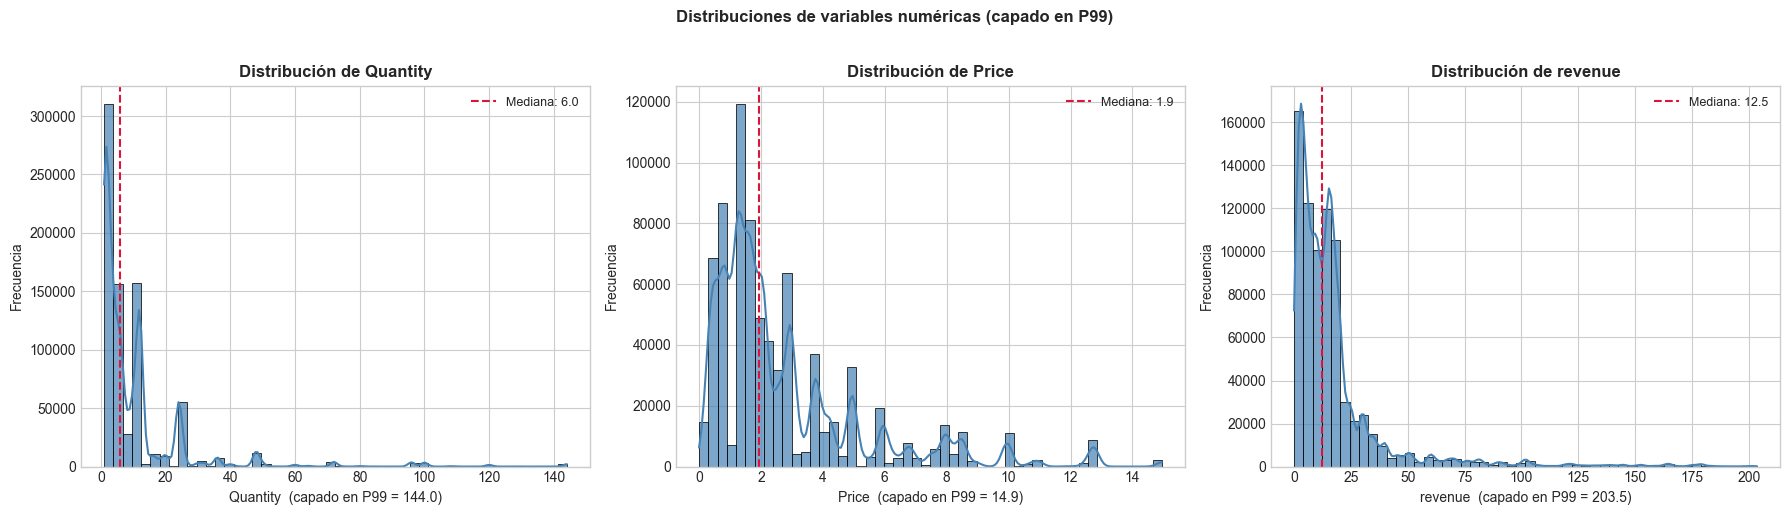

Hallazgo: sesgo positivo extremo en las tres variables → justifica log1p en el modelado.


In [759]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, NUM_COLS):
    p99   = df[col].quantile(0.99)
    datos = df[col][df[col] <= p99]
    sns.histplot(datos, kde=True, bins=50, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(df[col].median(), color='crimson', linestyle='--', linewidth=1.5,
               label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(f'{col}  (capado en P99 = {p99:.1f})')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribuciones de variables numéricas (capado en P99)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Hallazgo: sesgo positivo extremo en las tres variables → justifica log1p en el modelado.')

### 3.3 Detección de outliers — Método IQR

**IQR vs Z-Score:** el Z-Score asume distribución normal. Con skewness tan alto,
la media y la std se distorsionan y sobredetectan outliers. El IQR es no
paramétrico: usa Q1 y Q3, estadísticos robustos ante asimetría.

**Decisión:** los outliers son **clientes mayoristas**, no errores de datos.
Son pedidos legítimos de distribuidores. No se eliminan — se identifican con
la variable `ticket_medio` en la sección 4.

In [760]:
registros = []
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > lim_sup)).sum()
    registros.append({'variable': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                      'límite_sup': round(lim_sup,2), 'n_outliers': n,
                      '% outliers': round(n/len(df)*100, 2)})

display(pd.DataFrame(registros).set_index('variable'))
print('Hallazgo: outliers corresponden a pedidos mayoristas — valores legítimos de negocio.')

,Q1,Q3,límite_sup,n_outliers,% outliers
variable,,,,,
Quantity,2.00,12.00,27.00,51119,6.56
Price,1.25,3.75,7.50,65463,8.40
revenue,4.95,19.80,42.08,63562,8.15


Hallazgo: outliers corresponden a pedidos mayoristas — valores legítimos de negocio.


### 3.4 Análisis temporal — Ventas por mes

Revenue total agrupado por mes para identificar estacionalidad. La fecha de
corte (30 sep 2011) cae justo antes del pico navideño de 2011, garantizando
que la ventana de etiqueta (oct-dic 2011) capture el período más discriminante
para predecir recompra.

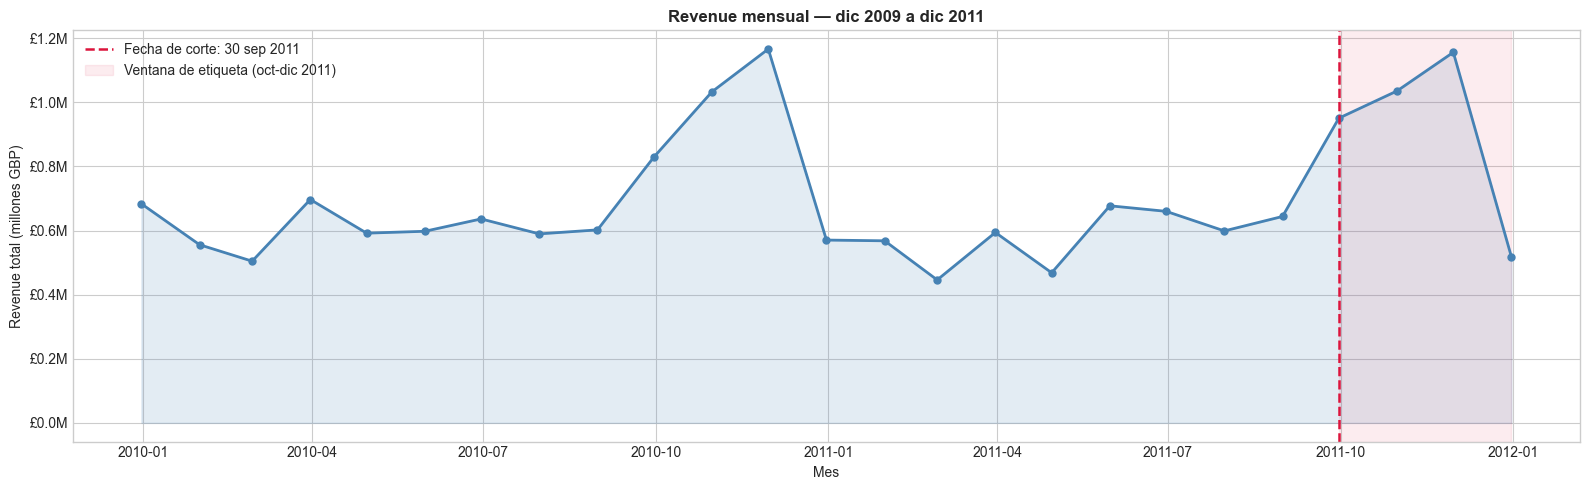

Mes con mayor revenue: November 2010 (£1.17M)


In [761]:
df_monthly = (
    df.set_index('InvoiceDate')
    .groupby(pd.Grouper(freq='ME'))['revenue']
    .sum().reset_index()
)
df_monthly.columns = ['mes', 'revenue_total']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_monthly['mes'], df_monthly['revenue_total']/1e6,
        marker='o', linewidth=2, markersize=5, color='steelblue')
ax.fill_between(df_monthly['mes'], df_monthly['revenue_total']/1e6, alpha=0.15, color='steelblue')

cutoff = pd.Timestamp('2011-09-30')
ax.axvline(cutoff, color='crimson', linestyle='--', linewidth=1.8, label='Fecha de corte: 30 sep 2011')
ax.axvspan(cutoff, df_monthly['mes'].max(), alpha=0.08, color='crimson',
           label='Ventana de etiqueta (oct-dic 2011)')
ax.set_title('Revenue mensual — dic 2009 a dic 2011', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Revenue total (millones GBP)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

top = df_monthly.loc[df_monthly['revenue_total'].idxmax()]
print(f'Mes con mayor revenue: {top["mes"].strftime("%B %Y")} (£{top["revenue_total"]/1e6:.2f}M)')

### 3.5 Análisis geográfico

El negocio es fundamentalmente británico. La concentración geográfica justifica
codificar `Country` como variable binaria `es_uk` en lugar de one-hot encoding
de 40 países — evita añadir ruido sin valor predictivo.

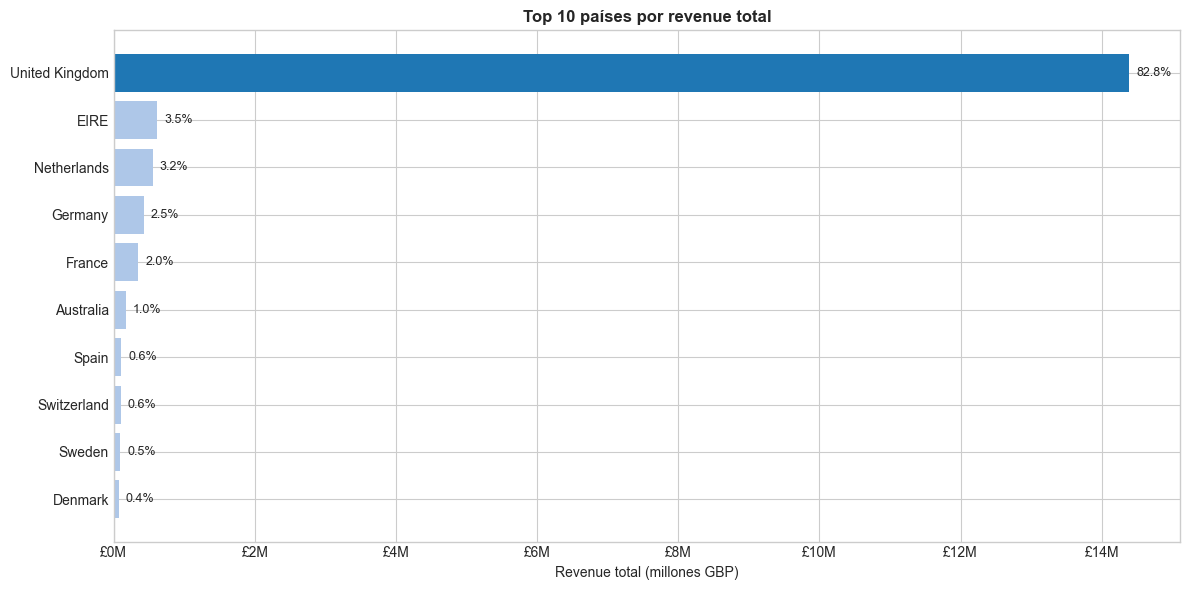

Reino Unido: 82.8% del revenue total. 39 países restantes: 17.2%.


In [762]:
revenue_pais = (
    df.groupby('Country')['revenue'].sum()
    .sort_values(ascending=False).reset_index()
)
revenue_pais['% del total'] = (revenue_pais['revenue'] / revenue_pais['revenue'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
top10   = revenue_pais.head(10)
colores = ['#1f77b4' if c == 'United Kingdom' else '#aec7e8' for c in top10['Country']]
bars    = ax.barh(top10['Country'][::-1], top10['revenue'][::-1]/1e6, color=colores[::-1])
for bar, pct in zip(bars, top10['% del total'][::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_title('Top 10 países por revenue total', fontweight='bold')
ax.set_xlabel('Revenue total (millones GBP)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}M'))
plt.tight_layout()
plt.show()

pct_uk = revenue_pais.loc[revenue_pais['Country']=='United Kingdom','% del total'].values[0]
print(f'Reino Unido: {pct_uk:.1f}% del revenue total. 39 países restantes: {100-pct_uk:.1f}%.')

### 3.6 Perfil de cliente

Agregamos por `Customer ID` para ver cómo se distribuyen los clientes según
su comportamiento de compra. Calculamos tres métricas por cliente:

- **frecuencia:** número de facturas distintas (veces que realizó un pedido)
- **gasto_total:** revenue acumulado en los 21 meses de observación
- **ticket_medio:** gasto_total / frecuencia — gasto promedio por pedido

El `ticket_medio` es la métrica más informativa del perfil porque distingue
el comportamiento mayorista del retail de forma directa y sin necesidad de
un umbral externo.

In [763]:
# Agregación exploratoria por cliente (solo para visualización — la construcción
# formal del perfil RFM con fecha de corte ocurre en la sección 4).
clientes = df.groupby('Customer ID').agg(
    frecuencia  = ('Invoice',   'nunique'),
    gasto_total = ('revenue',   'sum'),
    n_productos = ('StockCode', 'nunique'),
).reset_index()
clientes['ticket_medio'] = clientes['gasto_total'] / clientes['frecuencia']

print(f'Clientes únicos: {len(clientes):,}')
display(clientes[['frecuencia','gasto_total','ticket_medio']].describe().round(2))

Clientes únicos: 5,878


,frecuencia,gasto_total,ticket_medio
count,"5,878.00","5,878.00","5,878.00"
mean,6.29,"2,955.90",385.18
std,13.01,"14,440.85","1,214.29"
min,1.00,2.95,2.95
25%,1.00,342.28,176.68
50%,3.00,867.74,279.24
75%,7.00,"2,248.30",414.90
max,398.00,"580,987.04","84,236.25"


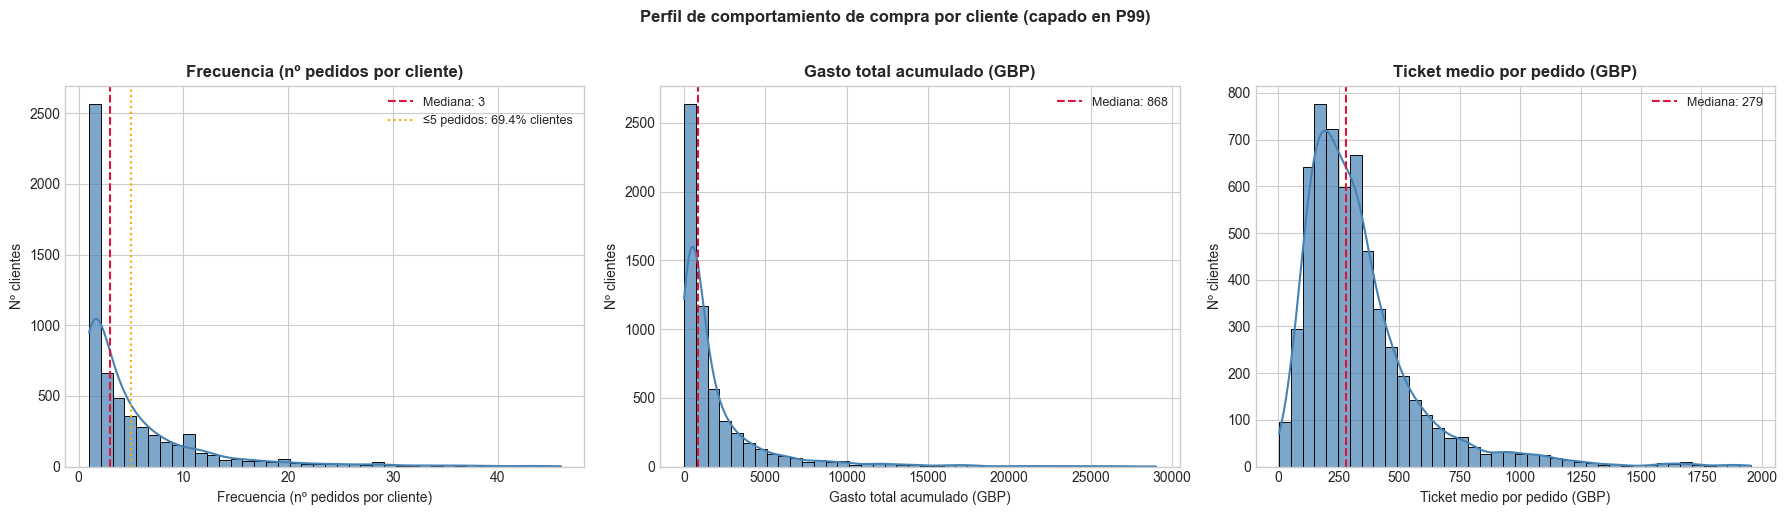

Compradores esporádicos (≤5 pedidos en 21 meses): 69.4% de los clientes
Mediana: 3 pedidos | Ticket medio mediana: £279


In [764]:
# Distribuciones del perfil de cliente, capadas en P99 para mostrar la masa retail.
# El 69.4% de clientes tiene 5 o menos pedidos — visible como la masa izquierda
# del histograma de frecuencia. Este cálculo es: (frecuencia <= 5).mean() * 100.
pct_esporadico = (clientes['frecuencia'] <= 5).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_cli = [
    ('frecuencia',   'Frecuencia (nº pedidos por cliente)'),
    ('gasto_total',  'Gasto total acumulado (GBP)'),
    ('ticket_medio', 'Ticket medio por pedido (GBP)'),
]
for ax, (col, label) in zip(axes, vars_cli):
    p99   = clientes[col].quantile(0.99)
    datos = clientes[col][clientes[col] <= p99]
    sns.histplot(datos, kde=True, bins=40, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(clientes[col].median(), color='crimson', linestyle='--', linewidth=1.5,
               label=f'Mediana: {clientes[col].median():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Nº clientes')
    ax.legend(fontsize=9)
    if col == 'frecuencia':
        ax.axvline(5, color='orange', linestyle=':', linewidth=1.5,
                   label=f'≤5 pedidos: {pct_esporadico:.1f}% clientes')
        ax.legend(fontsize=9)

plt.suptitle('Perfil de comportamiento de compra por cliente (capado en P99)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Compradores esporádicos (≤5 pedidos en 21 meses): {pct_esporadico:.1f}% de los clientes')
print(f'Mediana: {clientes["frecuencia"].median():.0f} pedidos | Ticket medio mediana: £{clientes["ticket_medio"].median():.0f}')

### 3.7 Segmentación retail vs mayorista — Scatter

El scatter `frecuencia × ticket_medio` separa visualmente los dos grandes
segmentos del negocio. Presentamos dos vistas complementarias:

**Vista 1 (sin capar):** muestra el espacio completo incluyendo los clientes
mayoristas extremos. Revela dos perfiles mayoristas distintos:
- **Alta frecuencia + ticket muy alto:** distribuidor que hace pedidos regulares
  y de gran volumen (cliente clave que necesita gestión de cuenta dedicada)
- **Baja frecuencia + ticket muy alto:** empresa que hace 1-2 pedidos masivos
  al año, típicamente de temporada (requiere estrategia de contrato anual)

**Vista 2 (capada en P94):** muestra la masa de clientes retail. El objetivo
del negocio se lee en este gráfico: mover los puntos azules hacia la derecha
(más frecuencia) y hacia la zona de ticket moderado, indicando fidelización.

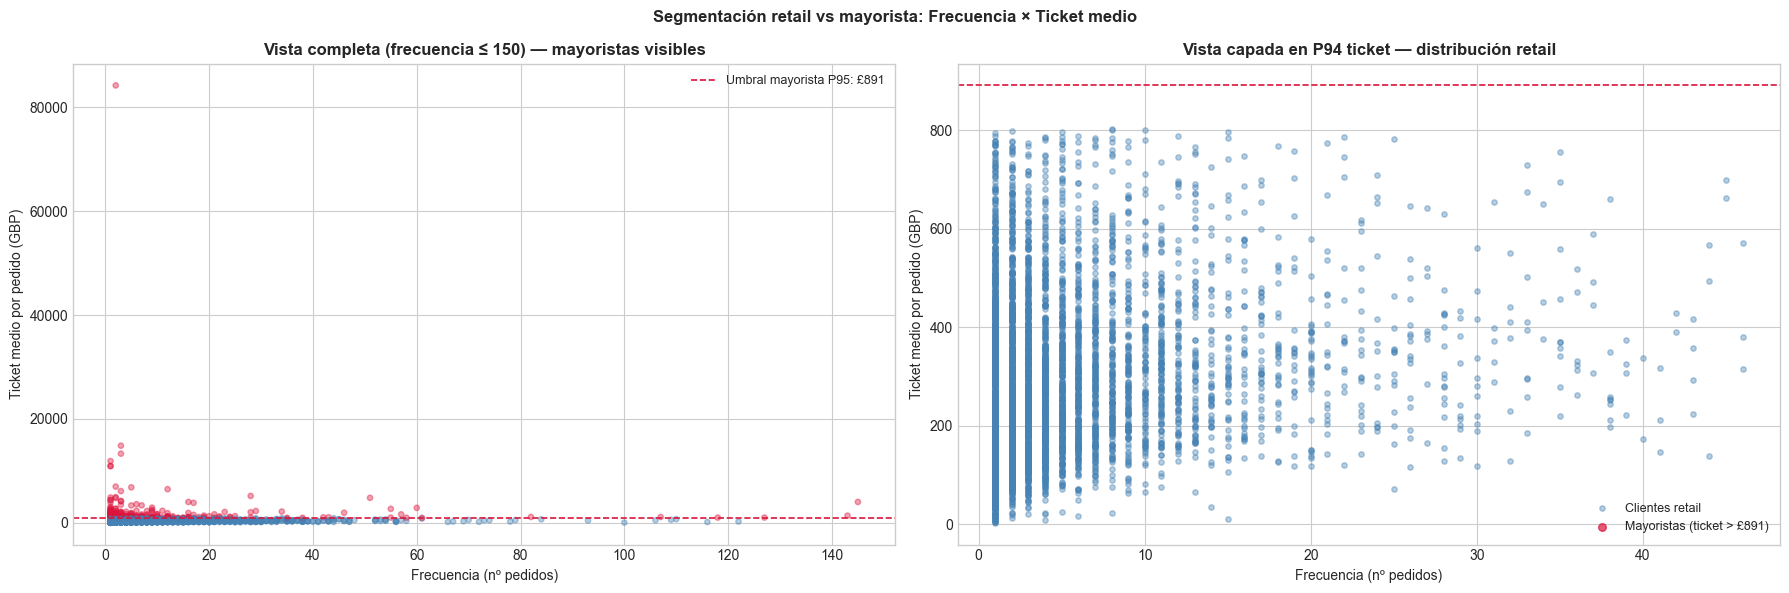

Mayoristas (P95 ticket > £891): 294 clientes (5.0%)


In [765]:
umbral_mayorista = clientes['ticket_medio'].quantile(0.95)
clientes['es_mayorista'] = clientes['ticket_medio'] > umbral_mayorista

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Vista 1: capada en frecuencia ≤ 150 para visualizar mejor los puntos mayoristas.
# Los dos perfiles mayoristas (alta frecuencia vs baja frecuencia + ticket extremo)
# son más legibles con este rango.
df_v1 = clientes[clientes['frecuencia'] <= 150]
colores_v1 = df_v1['es_mayorista'].map({False: 'steelblue', True: 'crimson'})
axes[0].scatter(df_v1['frecuencia'], df_v1['ticket_medio'],
                c=colores_v1, alpha=0.4, s=15)
axes[0].axhline(umbral_mayorista, color='crimson', linestyle='--', linewidth=1.2,
                label=f'Umbral mayorista P95: £{umbral_mayorista:.0f}')
axes[0].set_xlabel('Frecuencia (nº pedidos)')
axes[0].set_ylabel('Ticket medio por pedido (GBP)')
axes[0].set_title('Vista completa (frecuencia ≤ 150) — mayoristas visibles', fontweight='bold')
axes[0].legend(fontsize=9)

# Vista 2: capada en P94 ticket y P99 frecuencia — distribución retail
p94_t = clientes['ticket_medio'].quantile(0.94)
p99_f = clientes['frecuencia'].quantile(0.99)
df_sc = clientes[(clientes['ticket_medio'] <= p94_t) & (clientes['frecuencia'] <= p99_f)]
retail_sc    = df_sc[~df_sc['es_mayorista']]
mayorista_sc = df_sc[df_sc['es_mayorista']]
axes[1].scatter(retail_sc['frecuencia'],    retail_sc['ticket_medio'],
                c='steelblue', alpha=0.4, s=15, label='Clientes retail')
axes[1].scatter(mayorista_sc['frecuencia'], mayorista_sc['ticket_medio'],
                c='crimson',  alpha=0.7, s=30, label=f'Mayoristas (ticket > £{umbral_mayorista:.0f})')
axes[1].axhline(umbral_mayorista, color='crimson', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Frecuencia (nº pedidos)')
axes[1].set_ylabel('Ticket medio por pedido (GBP)')
axes[1].set_title('Vista capada en P94 ticket — distribución retail', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Segmentación retail vs mayorista: Frecuencia × Ticket medio', fontweight='bold')
plt.tight_layout()
plt.show()

n_may = clientes['es_mayorista'].sum()
print(f'Mayoristas (P95 ticket > £{umbral_mayorista:.0f}): {n_may} clientes ({n_may/len(clientes)*100:.1f}%)')

### 3.8 Concentración del revenue — Curva de Lorenz

Cuantificamos la concentración del revenue entre clientes. El cálculo:
- Ordenamos clientes de menor a mayor gasto
- `pct_revenue` al 80% de clientes = revenue generado por el 80% inferior
- Revenue del top 20% = 100% − revenue del 80% inferior

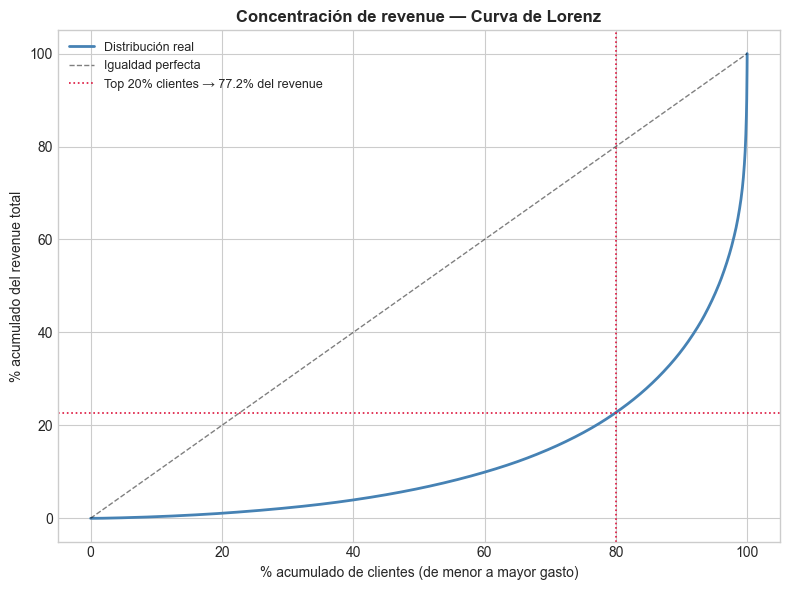

Top 20% de clientes → 77.2% del revenue
Bottom 80% de clientes → 22.8% del revenue
El top 20% genera 3.4x más revenue que el 80% inferior combinado.


In [766]:
# Curva de Lorenz: ordenamos de menor a mayor gasto y calculamos acumulados.
clientes_sorted = clientes.sort_values('gasto_total').reset_index(drop=True)
clientes_sorted['pct_clientes'] = (clientes_sorted.index + 1) / len(clientes_sorted) * 100
clientes_sorted['pct_revenue']  = (
    clientes_sorted['gasto_total'].cumsum() / clientes_sorted['gasto_total'].sum() * 100
)

# El top 20% genera = 100 - (lo que genera el bottom 80%)
pct_bottom80 = clientes_sorted[clientes_sorted['pct_clientes'] >= 80]['pct_revenue'].min()
pct_top20    = 100 - pct_bottom80
ratio_pareto = pct_top20 / pct_bottom80  # cuántas veces más genera el top 20%

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(clientes_sorted['pct_clientes'], clientes_sorted['pct_revenue'],
        color='steelblue', linewidth=2, label='Distribución real')
ax.plot([0,100],[0,100], 'k--', linewidth=1, alpha=0.5, label='Igualdad perfecta')
ax.axvline(80, color='crimson', linestyle=':', linewidth=1.2)
ax.axhline(pct_bottom80, color='crimson', linestyle=':', linewidth=1.2,
           label=f'Top 20% clientes → {pct_top20:.1f}% del revenue')
ax.set_xlabel('% acumulado de clientes (de menor a mayor gasto)')
ax.set_ylabel('% acumulado del revenue total')
ax.set_title('Concentración de revenue — Curva de Lorenz', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Top 20% de clientes → {pct_top20:.1f}% del revenue')
print(f'Bottom 80% de clientes → {pct_bottom80:.1f}% del revenue')
print(f'El top 20% genera {ratio_pareto:.1f}x más revenue que el 80% inferior combinado.')

### 3.9 EDA de cancelaciones

Las cancelaciones son una señal directa de insatisfacción. Analizamos su
distribución y perfil para:

1. Cuantificar qué proporción del negocio las experimenta
2. Entender si se concentran en clientes retail o mayoristas
3. Anticipar el diseño de la feature `ratio_cancelaciones` de la sección 4

**Nota sobre dos modelos:** la diferencia entre retail y mayorista es tan marcada
que un modelo separado por segmento sería más preciso. Para el alcance de este
proyecto se usa un único modelo con `ticket_medio` y `es_mayorista` como features,
dejando el enfoque de dos modelos como propuesta de mejora futura.

In [767]:
df_cancel = pd.read_pickle(PKL_CANCEL)

# Cancelaciones agregadas por cliente
cancel_cli = (
    df_cancel.groupby('Customer ID')['Invoice']
    .nunique().reset_index()
    .rename(columns={'Invoice': 'n_cancelaciones'})
)

n_con = len(cancel_cli)
n_sin = len(clientes) - n_con
print(f'Clientes con cancelaciones: {n_con:,} ({n_con/len(clientes)*100:.1f}%)')
print(f'Clientes sin cancelaciones: {n_sin:,} ({n_sin/len(clientes)*100:.1f}%)')
display(cancel_cli['n_cancelaciones'].describe().rename('cancelaciones por cliente').to_frame().T.round(2))

Clientes con cancelaciones: 2,572 (43.8%)
Clientes sin cancelaciones: 3,306 (56.2%)


,count,mean,std,min,25%,50%,75%,max
cancelaciones por cliente,"2,572.00",3.07,5.05,1.00,1.00,2.00,3.00,112.00


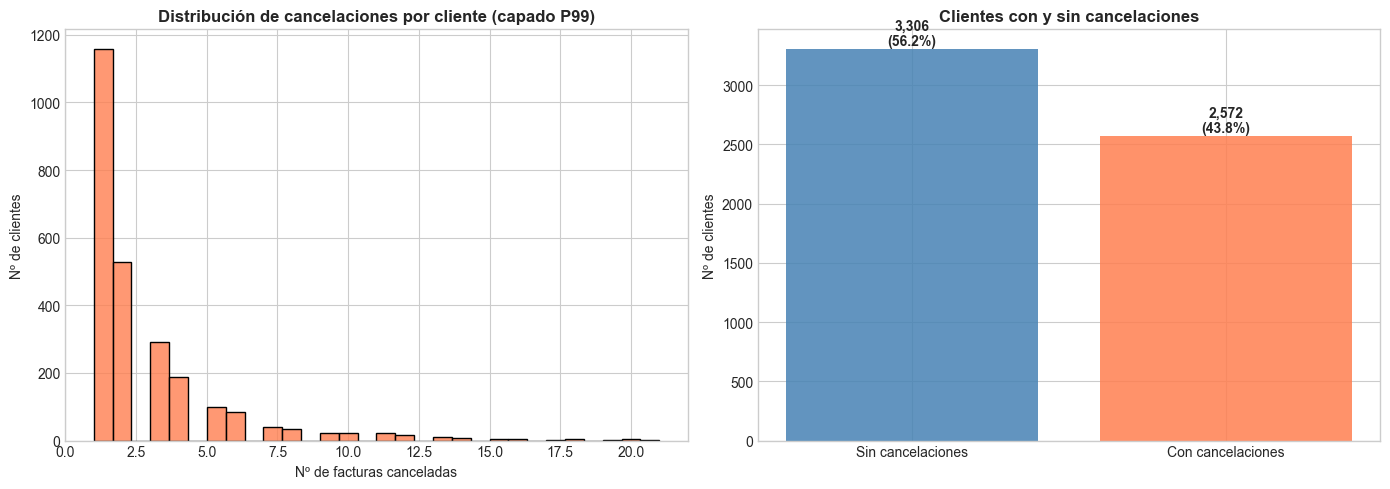

In [768]:
# Gráfica 1: distribución de cancelaciones + clientes con/sin cancelaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_c = cancel_cli['n_cancelaciones'].quantile(0.99)
sns.histplot(
    cancel_cli[cancel_cli['n_cancelaciones'] <= p99_c]['n_cancelaciones'],
    kde=False, bins=30, ax=axes[0], color='coral', alpha=0.8
)
axes[0].set_title('Distribución de cancelaciones por cliente (capado P99)', fontweight='bold')
axes[0].set_xlabel('Nº de facturas canceladas')
axes[0].set_ylabel('Nº de clientes')

axes[1].bar(['Sin cancelaciones','Con cancelaciones'], [n_sin, n_con],
            color=['steelblue','coral'], alpha=0.85)
for i, (n, label) in enumerate([(n_sin, n_sin/len(clientes)*100),
                                  (n_con, n_con/len(clientes)*100)]):
    axes[1].text(i, n+30, f'{n:,}\n({label:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clientes con y sin cancelaciones', fontweight='bold')
axes[1].set_ylabel('Nº de clientes')

plt.tight_layout()
plt.show()

In [769]:
df_cancel = pd.read_pickle(PKL_CANCEL)

cancel_cli = (
    df_cancel.groupby('Customer ID')['Invoice']
    .nunique().reset_index()
    .rename(columns={'Invoice': 'n_cancelaciones'})
)

n_con = len(cancel_cli)
n_sin = len(clientes) - n_con
print(f'Clientes con cancelaciones: {n_con:,} ({n_con/len(clientes)*100:.1f}%)')
print(f'Clientes sin cancelaciones: {n_sin:,} ({n_sin/len(clientes)*100:.1f}%)')
display(cancel_cli['n_cancelaciones'].describe().rename('cancelaciones por cliente').to_frame().T.round(2))

# Perfil de los que cancelan vs los que no cancelan
clientes_cancel = clientes.merge(cancel_cli, on='Customer ID', how='left')
clientes_cancel['tiene_cancel'] = clientes_cancel['n_cancelaciones'].notna()

# TASA de cancelación por segmento (más informativo que el % dentro del grupo)
may_cancel = clientes_cancel[clientes_cancel['es_mayorista']  & clientes_cancel['tiene_cancel']].shape[0]
ret_cancel = clientes_cancel[~clientes_cancel['es_mayorista'] & clientes_cancel['tiene_cancel']].shape[0]
n_may_tot  = clientes_cancel['es_mayorista'].sum()
n_ret_tot  = (~clientes_cancel['es_mayorista']).sum()

print(f'\nTasa de cancelación por segmento:')
print(f'  Mayoristas: {may_cancel} de {n_may_tot} cancelaron ({may_cancel/n_may_tot*100:.1f}% de los mayoristas)')
print(f'  Retail:     {ret_cancel} de {n_ret_tot} cancelaron ({ret_cancel/n_ret_tot*100:.1f}% de los retail)')
print(f'\nVolumen de cancelaciones:')
print(f'  Mayoristas representan el {may_cancel/n_con*100:.1f}% de los {n_con:,} clientes que cancelaron')
print(f'  Retail representa el {ret_cancel/n_con*100:.1f}% de los {n_con:,} clientes que cancelaron')

Clientes con cancelaciones: 2,572 (43.8%)
Clientes sin cancelaciones: 3,306 (56.2%)


,count,mean,std,min,25%,50%,75%,max
cancelaciones por cliente,"2,572.00",3.07,5.05,1.00,1.00,2.00,3.00,112.00



Tasa de cancelación por segmento:
  Mayoristas: 174 de 294 cancelaron (59.2% de los mayoristas)
  Retail:     2337 de 5584 cancelaron (41.9% de los retail)

Volumen de cancelaciones:
  Mayoristas representan el 6.8% de los 2,572 clientes que cancelaron
  Retail representa el 90.9% de los 2,572 clientes que cancelaron


**Interpretación del perfil de cancelaciones:**

Los datos revelan dos lecturas complementarias:

- **Tasa por segmento:** el 59,2% de los mayoristas canceló al menos una vez,
  frente al 41,9% de los retail. Los mayoristas cancelan más *per capita* —
  sus cancelaciones son principalmente operativas: ajustes de pedidos grandes
  entre empresa y distribuidor antes de servirse.

- **Volumen:** como los retail son el 95% de los clientes, el 90,9% de los
  2.572 clientes que cancelaron son retail. El volumen de cancelaciones es
  dominado por los minoristas.

**Implicación para el modelo:** `ratio_cancelaciones` será una feature útil
en ambos segmentos, pero con significado distinto. En retail, una tasa alta
puede indicar insatisfacción y predecir no recompra. En mayoristas, puede
ser comportamiento operativo normal y no correlacionar con el abandono.

### 3.10 Conclusiones del EDA e insights para la presentación

Hallazgos relevantes identificados en el análisis:

In [770]:
# Resumen cuantitativo de los principales hallazgos del EDA
pct_esporadico  = (clientes['frecuencia'] <= 5).mean() * 100
pct_uk          = revenue_pais.loc[revenue_pais['Country']=='United Kingdom','% del total'].values[0]
clientes_sorted2 = clientes.sort_values('gasto_total').reset_index(drop=True)
clientes_sorted2['pct_clientes'] = (clientes_sorted2.index+1)/len(clientes_sorted2)*100
clientes_sorted2['pct_revenue']  = clientes_sorted2['gasto_total'].cumsum()/clientes_sorted2['gasto_total'].sum()*100
pct_b80  = clientes_sorted2[clientes_sorted2['pct_clientes']>=80]['pct_revenue'].min()
pct_t20  = 100 - pct_b80
ratio_px = pct_t20 / pct_b80
mes_pico = df_monthly.loc[df_monthly['revenue_total'].idxmax(), 'mes'].strftime('%B %Y')

print('=== HALLAZGOS CLAVE DEL EDA ===')
print(f'1. Pico de ventas: {mes_pico} — estacionalidad navideña confirmada')
print(f'2. Compradores esporádicos (≤5 pedidos): {pct_esporadico:.1f}% de los clientes')
print(f'   Mediana: {clientes["frecuencia"].median():.0f} pedidos en 21 meses')
print(f'3. Concentración Pareto: top 20% clientes → {pct_t20:.1f}% del revenue')
print(f'   El top 20% genera {ratio_px:.1f}x más revenue que el 80% inferior combinado')
print(f'4. Mercado británico: {pct_uk:.1f}% del revenue — justifica variable es_uk')
print(f'5. Clientes con cancelaciones: {n_con/len(clientes)*100:.1f}% del total')
print(f'6. Mayoristas (P95 ticket): {n_may} clientes ({n_may/len(clientes)*100:.1f}%) — perfiles muy distintos al retail')

=== HALLAZGOS CLAVE DEL EDA ===
1. Pico de ventas: November 2010 — estacionalidad navideña confirmada
2. Compradores esporádicos (≤5 pedidos): 69.4% de los clientes
   Mediana: 3 pedidos en 21 meses
3. Concentración Pareto: top 20% clientes → 77.2% del revenue
   El top 20% genera 3.4x más revenue que el 80% inferior combinado
4. Mercado británico: 82.8% del revenue — justifica variable es_uk
5. Clientes con cancelaciones: 43.8% del total
6. Mayoristas (P95 ticket): 294 clientes (5.0%) — perfiles muy distintos al retail


**Decisiones técnicas confirmadas por el EDA:**

| Hallazgo | Decisión técnica |
|---|---|
| Skewness muy alto en Quantity, Price, revenue | Transformación `log1p` en variables RFM de escala |
| Mayoristas: ticket > £891 (P95), solo 5% de clientes | Feature `ticket_medio` y flag `es_mayorista` |
| Dominio UK (~85% revenue) | Variable binaria `es_uk` en lugar de one-hot de 40 países |
| 43,7% de clientes con cancelaciones | Features `ratio_cancelaciones` y `tiene_cancelaciones` |
| Estacionalidad navideña pronunciada | Corte sep-2011 validado: etiqueta captura el pico |
| 69,4% compradores esporádicos (≤5 pedidos) | Justifica el modelo: predecir cuáles volverán |

**Para la presentación (slide 2) — los 3 insights de mayor impacto:**

1. Estacionalidad navideña — motiva la fecha de corte y la urgencia del modelo
2. 69,4% compradores esporádicos — define el problema que resuelve el modelo
3. Concentración Pareto (top 20% → 77,2% revenue) — cuantifica el impacto económico
   de fidelizar vs retener: el top 20% genera **3,4x más** que el 80% restante

---
<a id="seccion-4"></a>
## 4. Construcción del dataset de modelado

Esta sección transforma ~780.000 filas transaccionales en una tabla de **una
fila por cliente** con features (X) y variable objetivo (Y):

```
779.425 filas (líneas de producto)
         ↓  groupby('Customer ID')  +  fecha de corte
    ~5.430 filas (1 por cliente)
    ├── X: recencia, frecuencia, monetario, ticket_medio ...
    └── Y: recompra (0 ó 1)
```

> *Equivalente econométrico:* construir la base de datos analítica previa
> a correr el modelo — crear regresores, definir la muestra.

### 4.0 Separación temporal — Observación vs Etiqueta

La **fecha de corte** es el 30 de septiembre de 2011. Divide el dataset en:

| Período | Fechas | Función |
|---|---|---|
| Observación | 2009-12-01 → 2011-09-30 | Construir features X |
| Etiqueta | 2011-10-01 → 2011-12-09 | Construir target Y |

**¿Cómo se construye la variable objetivo desde el período de etiqueta?**
Para cada cliente del período de observación consultamos si aparece en el
período de etiqueta: sí → `recompra = 1`, no → `recompra = 0`. El período
de etiqueta no entra al modelo como datos — solo define la etiqueta Y.

**Usamos comparación de fechas** (no timestamps) para incluir correctamente
todas las transacciones del 30 de septiembre, independientemente de la hora.

> *Equivalente econométrico:* definir el período de estimación in-sample
> y el período de validación out-of-sample — sin esto, el modelo vería
> el futuro durante el entrenamiento (data leakage).

In [771]:
df = pd.read_pickle(PKL_PATH)
df['revenue'] = df['Quantity'] * df['Price']

# Comparamos fechas (no timestamps) para incluir el 30-Sep completo,
# independientemente de la hora a la que ocurrió la transacción.
CUTOFF    = pd.Timestamp('2011-09-30').date()
CUTOFF_REF = pd.Timestamp('2011-10-01')  # referencia para calcular recencia

df_obs   = df[df['InvoiceDate'].dt.date <= CUTOFF].copy()
df_label = df[df['InvoiceDate'].dt.date >  CUTOFF].copy()

print('=== SEPARACIÓN TEMPORAL ===')
print(f'Observación: {df_obs["InvoiceDate"].min().date()} → {df_obs["InvoiceDate"].max().date()}')
print(f'Etiqueta:    {df_label["InvoiceDate"].min().date()} → {df_label["InvoiceDate"].max().date()}')
n_obs  = df_obs['Customer ID'].nunique()
nuevos = len(set(df_label['Customer ID']) - set(df_obs['Customer ID']))
print(f'\nClientes en observación: {n_obs:,}')
print(f'Clientes solo en etiqueta (sin historial, excluidos): {nuevos:,}')

=== SEPARACIÓN TEMPORAL ===
Observación: 2009-12-01 → 2011-09-30
Etiqueta:    2011-10-02 → 2011-12-09

Clientes en observación: 5,438
Clientes solo en etiqueta (sin historial, excluidos): 440


### 4.1 Variables RFM — Recencia, Frecuencia y Monetario

**Recencia (R):** días entre la última compra y el 1 de octubre de 2011
(referencia = día siguiente al corte). Valor bajo = cliente activo.
Es la variable más predictiva: dos picos observados en el EDA lo confirman —
clientes recientes (pico ~10 días) y clientes que solo compraron en Navidad
2010 (pico ~320 días) tienen comportamientos de recompra muy distintos.

**Frecuencia (F):** número de facturas distintas (visitas al negocio).
Las cancelaciones ya fueron excluidas en la sección 2.

**Monetario (M):** suma de `revenue` en el período de observación.
Es el Customer Lifetime Value histórico. Distribución muy sesgada por
mayoristas → se aplicará `log1p` en la sección 5.

> *Equivalente econométrico:* estos son los regresores X₁, X₂, X₃ del modelo
> logit — el framework RFM es el estándar de econometría de marketing.

In [772]:
# Recencia: días entre última compra y el 1-Oct-2011 (día siguiente al corte).
# Usamos .date() en ambos lados para evitar errores con compras intradiarias
# en el día del corte que producirían recencia = 0 o negativa.
rfm = df_obs.groupby('Customer ID').agg(
    recencia   = ('InvoiceDate',
                  lambda x: (CUTOFF_REF.date() - x.max().date()).days),
    frecuencia = ('Invoice',     'nunique'),
    monetario  = ('revenue',     'sum'),
).reset_index()

print(f'RFM base: {rfm.shape[0]:,} clientes × {rfm.shape[1]} columnas')
print(f'Recencia mínima: {rfm["recencia"].min()} días  (debe ser ≥ 1)')
print(f'Recencia máxima: {rfm["recencia"].max()} días')
display(rfm.describe().round(2))

RFM base: 5,438 clientes × 4 columnas
Recencia mínima: 1 días  (debe ser ≥ 1)
Recencia máxima: 669 días


,recencia,frecuencia,monetario
count,"5,438.00","5,438.00","5,438.00"
mean,205.69,5.81,"2,696.90"
std,184.71,11.74,"12,887.88"
min,1.00,1.00,2.90
25%,37.00,1.00,321.61
50%,149.00,3.00,789.20
75%,339.00,6.00,"2,119.48"
max,669.00,331.00,"501,489.15"


### Interpretación del RFM base

**Recencia media ~200 días:** no indica que la mayoría sean mayoristas —
indica que el 60% de clientes no recompró (clientes churned con recencia alta
jalan la media hacia arriba). La distribución bimodal en la gráfica de la
sección 4.7 lo confirma visualmente.

**Frecuencia máxima de 331 facturas:** puede ser un distribuidor pequeño
que hace pedidos muy frecuentes y pequeños. Sin el ticket_medio no podemos
distinguirlo del retail — es por eso que la frecuencia sola no es suficiente.

**Monetario medio ~£2.700:** es el gasto acumulado en 21 meses (no por
factura). La media está inflada por mayoristas; la mediana es más
representativa del cliente retail típico. Necesitará `log1p` en la sección 5.

### 4.2 Variables derivadas de RFM

**`ticket_medio`** = monetario / frecuencia.  
Distingue mayorista (ticket alto, frecuencia moderada) de retail (ticket
moderado-bajo, frecuencia alta). Variable más discriminante entre segmentos.

**`antiguedad`** = días entre primera y última compra en observación.  
Mide el span de la relación con el cliente. Si solo compró una vez:
`first_date = last_date` → `antiguedad = 0`. Esto es correcto y semánticamente
válido — ese cliente tiene 0 días de historial activo (solo visitó una vez).

**`num_productos_distintos`** = StockCodes únicos.  
Los clientes que exploran el catálogo ampliamente tienen mayor engagement.
El modelo aprende si esto correlaciona positiva o negativamente con recompra.

**`cantidad_media_por_factura`** = unidades totales / frecuencia.  
Variable = feature: ambos términos son sinónimos. Señal directa de comportamiento
mayorista (200 unidades/factura vs 8 unidades/factura en retail).

**`distancia_temporal_media`** = media de días entre compras consecutivas.  
Captura el ritmo de compra: compra regular vs esporádica.
*Imputación con mediana:* clientes con una sola fecha de compra no tienen
diferencia entre compras (necesitas ≥ 2 puntos para una diferencia). Se imputa
con la mediana del grupo para conservarlos en el modelo. Excluirlos introduciría
sesgo de selección: solo entrenaríamos sobre clientes que ya compraron
múltiples veces — que ya son parcialmente 'leales'.

**`es_uk`** = 1 si United Kingdom, 0 si internacional.  
El 91% de los clientes es UK → variable binaria correcta en lugar de one-hot
de 40 países.

**Nota sobre correlaciones entre variables:**  
`antiguedad` y `frecuencia` pueden estar correlacionadas (más compras → mayor
span entre primera y última). Analizaremos la matriz de correlaciones en la
sección 5 para detectar multicolinealidad antes del modelado.

> *Equivalente econométrico:* igual que construir variables de control e
> interacciones antes de ejecutar el comando `logit` en STATA.

In [773]:
# ticket_medio y antiguedad
extra = df_obs.groupby('Customer ID').agg(
    primera_compra = ('InvoiceDate', 'min'),
    ultima_compra  = ('InvoiceDate', 'max'),
    num_prod_dist  = ('StockCode',   'nunique'),
    total_unidades = ('Quantity',    'sum'),
).reset_index()
extra['antiguedad'] = (extra['ultima_compra'] - extra['primera_compra']).dt.days

rfm = rfm.merge(
    extra[['Customer ID', 'num_prod_dist', 'total_unidades', 'antiguedad']],
    on='Customer ID', how='left'
)
rfm['ticket_medio']           = rfm['monetario']      / rfm['frecuencia']
rfm['cantidad_media_factura'] = rfm['total_unidades'] / rfm['frecuencia']
rfm = rfm.drop(columns='total_unidades')

display(rfm[['frecuencia','monetario','ticket_medio','antiguedad']].describe().round(2))

,frecuencia,monetario,ticket_medio,antiguedad
count,"5,438.00","5,438.00","5,438.00","5,438.00"
mean,5.81,"2,696.90",373.62,234.48
std,11.74,"12,887.88",537.68,229.66
min,1.00,2.90,2.90,0.00
25%,1.00,321.61,176.14,0.00
50%,3.00,789.20,279.66,178.00
75%,6.00,"2,119.48",418.04,440.00
max,331.00,"501,489.15","14,844.77",668.00


In [774]:
# distancia_temporal_media: días promedio entre compras consecutivas por cliente.
# Comparamos FECHAS (no timestamps) para agrupar compras del mismo día.
# Pandas 3.x: usar col = col.fillna(...) en lugar de col.fillna(..., inplace=True).
fechas = (
    df_obs[['Customer ID', 'InvoiceDate']]
    .assign(fecha=df_obs['InvoiceDate'].dt.date)
    [['Customer ID', 'fecha']]
    .drop_duplicates()
    .sort_values(['Customer ID', 'fecha'])
)
fechas['diff_dias'] = (
    fechas.groupby('Customer ID')['fecha']
    .diff()
    .apply(lambda x: x.days if pd.notna(x) else np.nan)
)
dist = (
    fechas.groupby('Customer ID')['diff_dias']
    .mean().reset_index()
    .rename(columns={'diff_dias': 'distancia_temporal_media'})
)

mediana_dist = dist['distancia_temporal_media'].median()
n_imp = dist['distancia_temporal_media'].isna().sum()
# Pandas 3.x: asignación directa, no inplace
dist['distancia_temporal_media'] = dist['distancia_temporal_media'].fillna(mediana_dist)

rfm = rfm.merge(dist, on='Customer ID', how='left')
# Segunda guardia: si algún ID no estaba en dist tras el merge
rfm['distancia_temporal_media'] = rfm['distancia_temporal_media'].fillna(mediana_dist)

print(f'Clientes con 1 sola fecha de compra (imputados con mediana = {mediana_dist:.0f} días): {n_imp:,}')

Clientes con 1 sola fecha de compra (imputados con mediana = 77 días): 1,718


In [775]:
# es_uk: moda del país de cada cliente.
pais = (
    df_obs.groupby('Customer ID')['Country']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
pais['es_uk'] = (pais['Country'] == 'United Kingdom').astype(int)
rfm = rfm.merge(pais[['Customer ID', 'es_uk']], on='Customer ID', how='left')
rfm['es_uk'] = rfm['es_uk'].fillna(0).astype(int)  # guardia por si algún NaN

print(f'Clientes UK: {rfm["es_uk"].sum():,} ({rfm["es_uk"].mean()*100:.1f}%)')

Clientes UK: 4,958 (91.2%)


### 4.3 Features de cancelación

Extraídas del período de observación (filtradas al corte para evitar leakage).

**`ratio_cancelaciones`** = facturas canceladas / (compras + canceladas).  
Cuantifica qué proporción de la actividad del cliente involucró cancelaciones.
En retail puede señalar insatisfacción; en mayoristas puede ser operativo.
El modelo aprenderá qué dirección tiene este predictor en la práctica.

**`tiene_cancelaciones`** = 1 si canceló al menos una vez, 0 si nunca.  
Versión binaria robusta ante outliers extremos.

Los 3.130 clientes sin cancelaciones reciben `ratio_cancelaciones = 0`.
El LEFT JOIN (= LEFT JOIN en SQL) conserva los 5.430 clientes del RFM;
los que no aparecen en la tabla de cancelaciones quedan con 0.

> *Equivalente econométrico:* `merge 1:1 Customer ID` en STATA para añadir
> variables de una segunda base de datos antes de correr la regresión.

In [776]:
# Filtramos cancelaciones al período de observación — evita data leakage.
df_cancel = pd.read_pickle(PKL_CANCEL)
df_cancel_obs = df_cancel[df_cancel['InvoiceDate'].dt.date <= CUTOFF]

n_cancel = (
    df_cancel_obs.groupby('Customer ID')['Invoice']
    .nunique().reset_index()
    .rename(columns={'Invoice': 'n_cancel'})
)

rfm = rfm.merge(n_cancel, on='Customer ID', how='left')
# Pandas 3.x: asignación directa
rfm['n_cancel'] = rfm['n_cancel'].fillna(0)
rfm['ratio_cancelaciones'] = rfm['n_cancel'] / (rfm['frecuencia'] + rfm['n_cancel'])
rfm['tiene_cancelaciones'] = (rfm['n_cancel'] > 0).astype(int)
rfm = rfm.drop(columns='n_cancel')

print(f'Clientes con cancelaciones: {rfm["tiene_cancelaciones"].sum():,} ({rfm["tiene_cancelaciones"].mean()*100:.1f}%)')
print(f'Ratio medio de cancelaciones: {rfm["ratio_cancelaciones"].mean():.3f}  '
      f'({rfm["ratio_cancelaciones"].mean()*100:.1f}% de la actividad por cliente en media)')

Clientes con cancelaciones: 2,300 (42.3%)
Ratio medio de cancelaciones: 0.120  (12.0% de la actividad por cliente en media)


### 4.4 Variable objetivo — `recompra`

```
recompra = 1  →  el cliente compró al menos una vez en oct-dic 2011
recompra = 0  →  el cliente NO compró en oct-dic 2011
```

**¿Cómo funciona el entrenamiento?**  
El modelo ve pares (X, Y) — un **vector de 11 features** por cliente y su
etiqueta conocida. Para la regresión logística:

```
P(recompra=1) = sigmoid(β₀ + β₁·recencia + β₂·frecuencia + ... + β₁₁·ratio_cancel)
```

El entrenamiento ajusta los β para que las probabilidades predichas se acerquen
al máximo a los 0s y 1s reales. Es exactamente lo mismo que la estimación
por máxima verosimilitud en el comando `logit` de STATA.

**La predicción** es aplicar los β encontrados a clientes nuevos (el 20% de
test) para asignarles una probabilidad. El entrenamiento busca cuáles variables
tienen más peso; la predicción aplica ese conocimiento.

**El 39%/61%:** con 60,7% de clientes sin recompra, un modelo naïve que siempre
predicea 'no recompra' tendría 60,7% de accuracy — pero sería completamente
inútil. Usamos AUC-ROC para medir qué tan bien el modelo discrimina entre
las dos clases, no cuántas veces 'acierta' en bruto.

> *Equivalente econométrico:* Y es la variable dependiente del logit.
> La prevalencia del 39% equivale al porcentaje de respuestas positivas
> en una encuesta — define la dificultad del problema de clasificación.

In [777]:
# Clientes que recompraron: aparecen en el período de etiqueta.
# Solo contamos los que ya estaban en observación (tenemos sus features).
ids_recompran = set(df_label['Customer ID'].unique())
rfm['recompra'] = rfm['Customer ID'].isin(ids_recompran).astype(int)

n1 = rfm['recompra'].sum()
n0 = (rfm['recompra'] == 0).sum()
print(f'recompra = 1 (SÍ volvieron): {n1:,} ({n1/len(rfm)*100:.1f}%)')
print(f'recompra = 0 (NO volvieron): {n0:,} ({n0/len(rfm)*100:.1f}%)')
print(f'Total clientes en el modelo:  {len(rfm):,}')

recompra = 1 (SÍ volvieron): 2,120 (39.0%)
recompra = 0 (NO volvieron): 3,318 (61.0%)
Total clientes en el modelo:  5,438


### 4.5 Dataset final de modelado

Ordenamos las columnas lógicamente y verificamos el resultado.

In [778]:
COLS = [
    'Customer ID',
    'recencia', 'frecuencia', 'monetario',
    'ticket_medio', 'antiguedad', 'num_prod_dist',
    'cantidad_media_factura', 'distancia_temporal_media',
    'es_uk', 'ratio_cancelaciones', 'tiene_cancelaciones',
    'recompra'
]
rfm = rfm[COLS]

print(f'Dataset final: {rfm.shape[0]:,} clientes × {rfm.shape[1]} columnas')
print(f'  Features (X): {rfm.shape[1] - 2}  columnas  (Customer ID y recompra excluidos del modelo)')
print(f'  Target   (Y): recompra')
print()
print('Customer ID se excluye del modelo porque es un identificador administrativo')
print('sin valor predictivo — el número de ID no dice nada sobre el comportamiento.')
print('Recompra se excluye de X porque ES la variable que queremos predecir:')
print('incluirla como feature daría accuracy del 100%% en train pero sería inútil.')
display(rfm.head(5))

Dataset final: 5,438 clientes × 13 columnas
  Features (X): 11  columnas  (Customer ID y recompra excluidos del modelo)
  Target   (Y): recompra

Customer ID se excluye del modelo porque es un identificador administrativo
sin valor predictivo — el número de ID no dice nada sobre el comportamiento.
Recompra se excluye de X porque ES la variable que queremos predecir:
incluirla como feature daría accuracy del 100%% en train pero sería inútil.


,Customer ID,recencia,frecuencia,monetario,ticket_medio,antiguedad,num_prod_dist,cantidad_media_factura,distancia_temporal_media,es_uk,ratio_cancelaciones,tiene_cancelaciones,recompra
0,12346,256,12,"77,556.46","6,463.04",400,27,"6,190.42",57.14,1,0.29,1,0
1,12347,60,6,"3,402.39",567.07,274,107,349.83,55.00,0,0.00,0,1
2,12348,6,5,"2,019.40",403.88,362,25,542.80,90.75,0,0.00,0,0
3,12349,338,3,"2,671.14",890.38,181,90,331.00,91.00,0,0.25,1,1
4,12350,241,1,334.40,334.40,0,17,197.00,76.71,0,0.00,0,0


### 4.6 Verificación de data leakage y nulos

**Endogeneidad en econometría:** una variable es endógena cuando está
correlacionada con el término de error (causalidad inversa, variable omitida).
En ML/data leakage el concepto equivalente es más específico: ¿alguna feature
contiene información del futuro (posterior al corte)? Si sí, el modelo
'trampa' — aprende la respuesta en lugar de aprender el patrón.

**Señal de alerta:** AUC > 0.98 sin justificación clara = sospecha de leakage.

**Nulos:** los modelos de sklearn no toleran NaN. Cualquier nulo en el dataset
produce error en el entrenamiento. La verificación aquí garantiza que el
dataset está limpio antes de pasar al modelado.

In [779]:
print('=== VERIFICACIÓN DE DATA LEAKAGE ===')
print(f'Fecha de corte:                   {CUTOFF}')
print(f'Última fecha en observación:      {df_obs["InvoiceDate"].max().date()}')
print(f'Primera fecha en etiqueta:        {df_label["InvoiceDate"].min().date()}')
print(f'Última fecha en cancelaciones obs: {df_cancel_obs["InvoiceDate"].max().date()}')
print()

leak_obs    = (df_obs['InvoiceDate'].dt.date > CUTOFF).any()
leak_cancel = (df_cancel_obs['InvoiceDate'].dt.date > CUTOFF).any()
print(f'Datos de observación fuera del corte:    {leak_obs}   ← debe ser False')
print(f'Cancelaciones fuera del corte:           {leak_cancel}  ← debe ser False')
print()

print('=== VERIFICACIÓN DE NULOS ===')
nulos = rfm.isnull().sum()
nulos_con = nulos[nulos > 0]
if len(nulos_con) == 0:
    print('Sin valores nulos — dataset listo para el modelado.')
else:
    print('Nulos encontrados (deben corregirse antes de modelar):')
    display(nulos_con)

=== VERIFICACIÓN DE DATA LEAKAGE ===
Fecha de corte:                   2011-09-30
Última fecha en observación:      2011-09-30
Primera fecha en etiqueta:        2011-10-02
Última fecha en cancelaciones obs: 2011-09-30

Datos de observación fuera del corte:    False   ← debe ser False
Cancelaciones fuera del corte:           False  ← debe ser False

=== VERIFICACIÓN DE NULOS ===
Sin valores nulos — dataset listo para el modelado.


### 4.7 Distribución de la variable objetivo — Balance de clases

**¿Qué es el balance de clases?**  
En clasificación binaria hay dos clases: recompra=1 (clase positiva, el evento
que queremos detectar) y recompra=0 (clase negativa). Si una clase es muy
infrecuente, el modelo aprende a ignorarla — predecir siempre la clase mayoritaria
le da alta accuracy, pero es inútil.

Con un 39% de positivos el desbalanceo es moderado. No necesitamos correcciones
agresivas — AUC-ROC como métrica principal ya compensa esto.

**Sobre el gráfico de recencia:** la KDE (estimación de densidad kernel) suaviza
la distribución extendiendo la curva más allá del rango real de los datos —
los valores negativos son un artefacto visual, no clientes reales.

**Los dos picos en recencia:** capturan dos segmentos de comportamiento:
- Pico ~10 días: compradores activos de septiembre 2011 → probablemente recompra=1
- Pico ~320 días: compradores de Navidad 2010 que llevan un año sin volver →
  muchos son recompra=0, aunque algunos sí vuelven para Navidad 2011.
  Este patrón bimodal confirma que la recencia es la variable más discriminante.

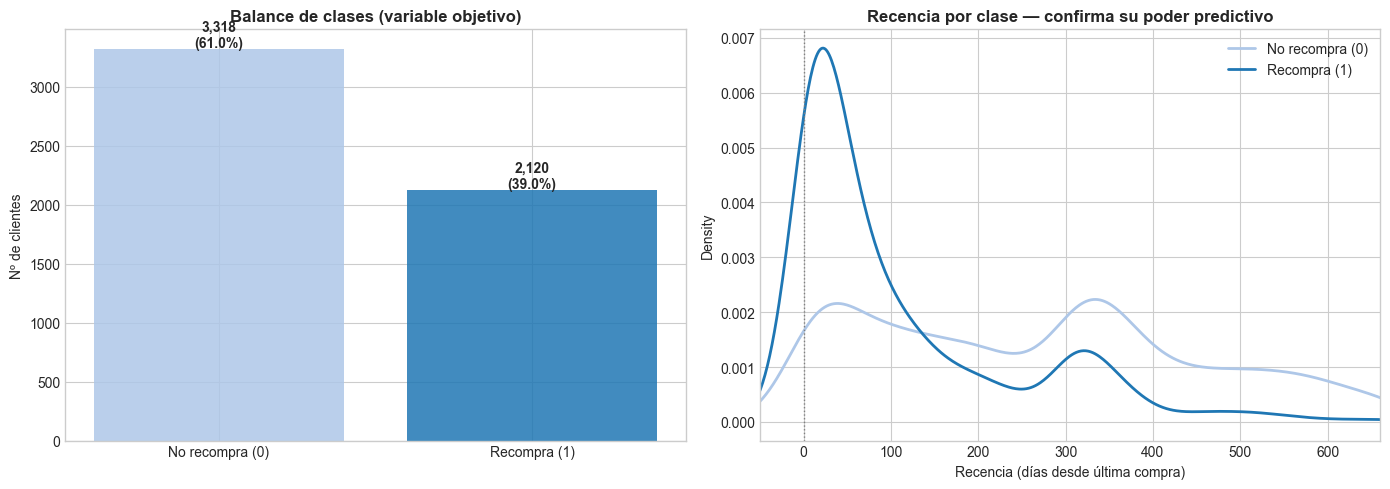

Clase positiva: 39.0% → Desbalanceo moderado: AUC-ROC como métrica principal


In [780]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balance de clases
conteo  = rfm['recompra'].value_counts().sort_index()
labels  = ['No recompra (0)', 'Recompra (1)']
colores = ['#aec7e8', '#1f77b4']
bars    = axes[0].bar(labels, conteo.values, color=colores, alpha=0.85)
for bar, n in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{n:,}\n({n/len(rfm)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Balance de clases (variable objetivo)', fontweight='bold')
axes[0].set_ylabel('Nº de clientes')

# Distribución de recencia por clase
for clase, color, label in [(0,'#aec7e8','No recompra (0)'), (1,'#1f77b4','Recompra (1)')]:
    rfm[rfm['recompra']==clase]['recencia'].plot(
        kind='kde', ax=axes[1], color=color, linewidth=2, label=label
    )
axes[1].set_xlim(-50, rfm['recencia'].quantile(0.99))
axes[1].set_xlabel('Recencia (días desde última compra)')
axes[1].set_title('Recencia por clase — confirma su poder predictivo', fontweight='bold')
axes[1].legend()
axes[1].axvline(0, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

pct = rfm['recompra'].mean() * 100
decision = ('Desbalanceo moderado: AUC-ROC como métrica principal' if pct < 40
            else 'Balance aceptable: sin ajustes adicionales')
print(f'Clase positiva: {pct:.1f}% → {decision}')

### 4.8 Guardar el dataset de modelado

El dataset resultante es el punto de entrada de la sección 5
(Feature Engineering y preprocesamiento).

In [781]:
PKL_MODEL = CLEAN_DATA / 'dataset_modelado.pkl'
rfm.to_pickle(PKL_MODEL)

print(f'Dataset guardado: {PKL_MODEL}')
print(f'Shape: {rfm.shape[0]:,} clientes × {rfm.shape[1]} columnas')
print()
print('Resumen de features:')
features = [c for c in rfm.columns if c not in ['Customer ID','recompra']]
for col in features:
    print(f'  {col:<30}  media={rfm[col].mean():>8.2f}  mediana={rfm[col].median():>8.2f}')

Dataset guardado: /Users/usuario/Downloads/DATA_SCIENCE/Quinto_Módulo_ML/Proyecto_ML_Pujana/DATA/clean_data/dataset_modelado.pkl
Shape: 5,438 clientes × 13 columnas

Resumen de features:
  recencia                        media=  205.69  mediana=  149.00
  frecuencia                      media=    5.81  mediana=    3.00
  monetario                       media= 2696.90  mediana=  789.20
  ticket_medio                    media=  373.62  mediana=  279.66
  antiguedad                      media=  234.48  mediana=  178.00
  num_prod_dist                   media=   75.57  mediana=   41.00
  cantidad_media_factura          media=  243.44  mediana=  149.92
  distancia_temporal_media        media=   93.60  mediana=   76.71
  es_uk                           media=    0.91  mediana=    1.00
  ratio_cancelaciones             media=    0.12  mediana=    0.00
  tiene_cancelaciones             media=    0.42  mediana=    0.00


---
<a id="seccion-5"></a>
## 5. Feature Engineering y preprocesamiento

Esta sección transforma el dataset de modelado (5.438 × 13) en el formato exacto
que el modelo necesita para aprender correctamente.

**¿Qué es el Feature Engineering?**  
Es exactamente lo que la intuición indica: entender el contexto del negocio y tratar
los datos para que el modelo pueda aprender los patrones de la mejor manera posible.
Antes de correr un `logit` en STATA también preparabas las variables — creabas
logaritmos, construías dummies, revisabas multicolinealidad. El Feature Engineering
es ese mismo proceso, formalizado y sistematizado para el flujo de ML.

Los cuatro pasos de esta sección:

| Paso | Qué hace | Por qué |
|---|---|---|
| 5.1 | Transformaciones `log1p` en 4 variables | Corrige sesgo extremo confirmado en el EDA |
| 5.2 | Matriz de correlaciones | Detecta multicolinealidad antes de modelar |
| 5.3 | Train/test split 80/20 | Separa datos de entrenamiento y validación out-of-sample |
| 5.4 | StandardScaler | Pone todas las variables en la misma escala |

> *Regla de oro:* el split (5.3) va siempre ANTES del escalado (5.4).
> Si escalamos primero, el scaler ve los datos de test y eso es data leakage.

In [782]:
# Cargamos el dataset de modelado construido en la sección 4.
# PKL_MODEL y CLEAN_DATA están definidos en la celda de setup (sección 1).
rfm = pd.read_pickle(PKL_MODEL)

# Lista de features: todo excepto el identificador y la variable objetivo.
FEATURE_COLS = [c for c in rfm.columns if c not in ['Customer ID', 'recompra']]

print(f'Dataset cargado: {rfm.shape[0]:,} clientes × {rfm.shape[1]} columnas')
print(f'Features (X): {len(FEATURE_COLS)} columnas')
print(f'Target  (Y): recompra  —  {rfm["recompra"].mean()*100:.1f}% positivos')
print()
print('Features:', FEATURE_COLS)

Dataset cargado: 5,438 clientes × 13 columnas
Features (X): 11 columnas
Target  (Y): recompra  —  39.0% positivos

Features: ['recencia', 'frecuencia', 'monetario', 'ticket_medio', 'antiguedad', 'num_prod_dist', 'cantidad_media_factura', 'distancia_temporal_media', 'es_uk', 'ratio_cancelaciones', 'tiene_cancelaciones']


### 5.1 Transformaciones logarítmicas

El EDA de la sección 3 confirmó sesgo extremo en cuatro variables:
`monetario`, `ticket_medio`, `cantidad_media_factura` y `distancia_temporal_media`.

**¿Por qué el sesgo importa para el modelo?**  
La regresión logística asume que existe una relación aproximadamente lineal entre
cada feature y el log-odds de recompra. Si `monetario` tiene distribución exponencial
(la mayoría de clientes agrupados en valores bajos, unos pocos con valores extremos
de mayoristas), esa relación lineal no se cumple y el modelo aprende de forma
distorsionada — sobrepondera los valores extremos.

El logaritmo comprime la escala preservando el orden:

| Revenue bruto | log1p(revenue) | Diferencia en log |
|---|---|---|
| £1 | 0.7 | — |
| £100 | 4.6 | 3.9 |
| £1.000 | 6.9 | 2.3 |
| £10.000 | 9.2 | 2.3 |
| £100.000 | 11.5 | 2.3 |

Cada multiplicación por 10x equivale a sumar ~2.3 en escala log — diferencias
proporcionales, no absolutas. El modelo deja de «sorprenderse» por los valores
extremos de los mayoristas.

`log1p(x) = log(x+1)` en lugar de `log(x)` para evitar el problema de log(0).

**Variables que NO se transforman:**
- `recencia`, `frecuencia`, `antiguedad`, `num_prod_dist` — distribución manejable sin transformar
- `es_uk`, `tiene_cancelaciones` — binarias (0/1), no aplica
- `ratio_cancelaciones` — ya acotada entre 0 y 1

> *Equivalente econométrico:* idéntico al uso de `log(salario)` en la ecuación de
> Mincer, `log(PIB)` en regresiones de crecimiento, o `log(precio)` en modelos de
> demanda. Comprimes la escala sin perder el orden ni el signo relativo entre observaciones.

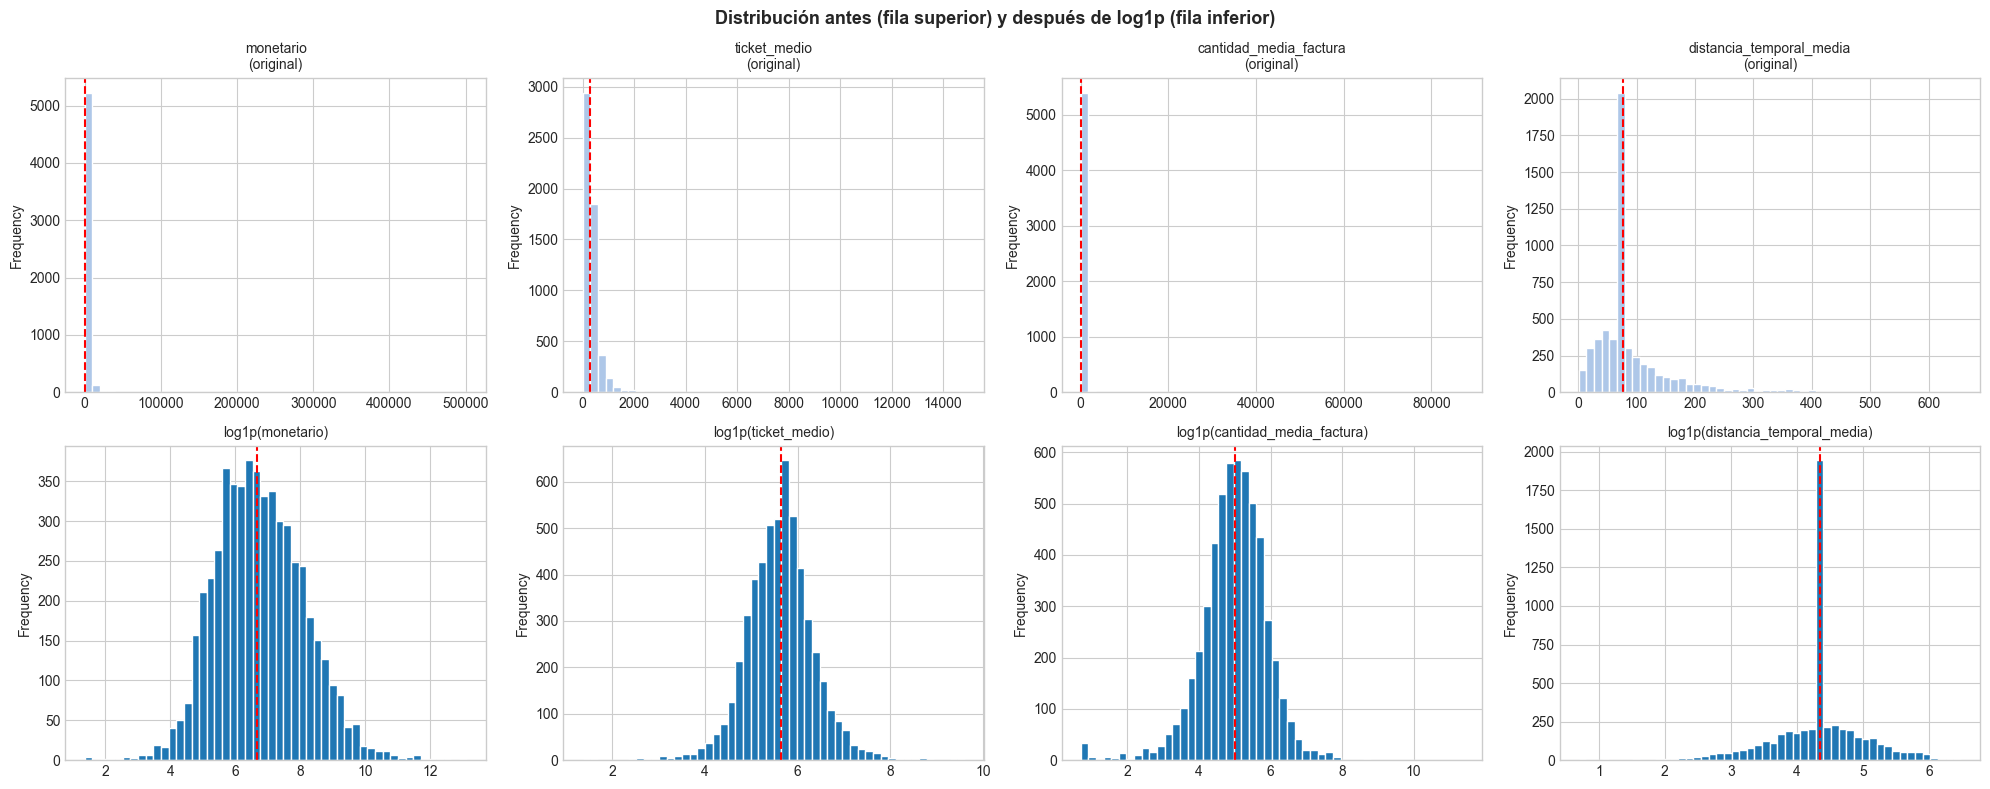

Reducción de sesgo con log1p:


,skewness_antes,skewness_despues,reduccion_%
monetario,24.56,0.29,98.80
ticket_medio,13.42,-0.02,99.90
cantidad_media_factura,52.40,-0.65,98.80
distancia_temporal_media,2.74,-0.65,76.30


In [783]:
LOG_COLS = ['monetario', 'ticket_medio', 'cantidad_media_factura', 'distancia_temporal_media']

# Visualización antes / después para confirmar reducción de sesgo.
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Distribución antes (fila superior) y después de log1p (fila inferior)',
             fontweight='bold', fontsize=13)

for i, col in enumerate(LOG_COLS):
    rfm[col].plot(kind='hist', bins=50, ax=axes[0, i], color='#aec7e8', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(original)', fontsize=10)
    axes[0, i].axvline(rfm[col].median(), color='red', linewidth=1.5,
                       linestyle='--', label='mediana')

    np.log1p(rfm[col]).plot(kind='hist', bins=50, ax=axes[1, i],
                            color='#1f77b4', edgecolor='white')
    axes[1, i].set_title(f'log1p({col})', fontsize=10)
    axes[1, i].axvline(np.log1p(rfm[col]).median(), color='red',
                       linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()

# Aplicamos log1p sobreescribiendo las columnas en una copia del dataset.
rfm_fe = rfm.copy()
for col in LOG_COLS:
    rfm_fe[col] = np.log1p(rfm_fe[col])

# Comparación numérica de la reducción de sesgo.
skew_antes   = rfm[LOG_COLS].skew().round(2)
skew_despues = rfm_fe[LOG_COLS].skew().round(2)
comp = pd.DataFrame({'skewness_antes': skew_antes, 'skewness_despues': skew_despues})
comp['reduccion_%'] = ((1 - comp['skewness_despues'].abs() / comp['skewness_antes'].abs()) * 100).round(1)
print('Reducción de sesgo con log1p:')
display(comp)

### 5.2 Matriz de correlaciones — detección de multicolinealidad

Antes de entrenar verificamos si alguna features están tan correlacionadas entre sí
que una hace redundante a la otra. Esto afecta de forma distinta a cada modelo.

> *Equivalente econométrico:* el **test VIF** (Variance Inflation Factor) de STATA.
> Un VIF > 10 indica que una variable es casi una combinación lineal de otras —
> sus coeficientes son inestables. La correlación de Pearson es la primera
> aproximación antes de modelar.

**¿Qué buscamos en el heatmap?**

1. **Correlaciones altas entre features (|r| > 0.7):** potencial redundancia.
   Por ejemplo, si `antiguedad` y `frecuencia` tienen r = 0.85, ambas miden
   básicamente lo mismo (cliente con muchas compras → historial más largo).

2. **Correlaciones con `recompra`:** señal directa de poder predictivo.
   Se espera que `recencia` tenga correlación negativa (menos recencia → más recompra).

**Implicación por modelo:**

| Modelo | Sensibilidad a multicolinealidad |
|---|---|
| Regresión logística | Alta — coeficientes inestables si r > 0.8 entre features |
| Random Forest | Baja — los árboles seleccionan la feature más útil en cada nodo |
| XGBoost | Baja — misma razón que RF, boosting maneja redundancia internamente |

Si detectamos correlación alta entre dos features, no las eliminamos automáticamente:
documentamos el hallazgo y lo tenemos en cuenta al interpretar coeficientes en la
sección 6. Para la regresión logística, correlación alta puede hacer que un coeficiente
individual parezca pequeño aunque la variable sea importante — porque la otra feature
correlacionada «roba» parte de su efecto.

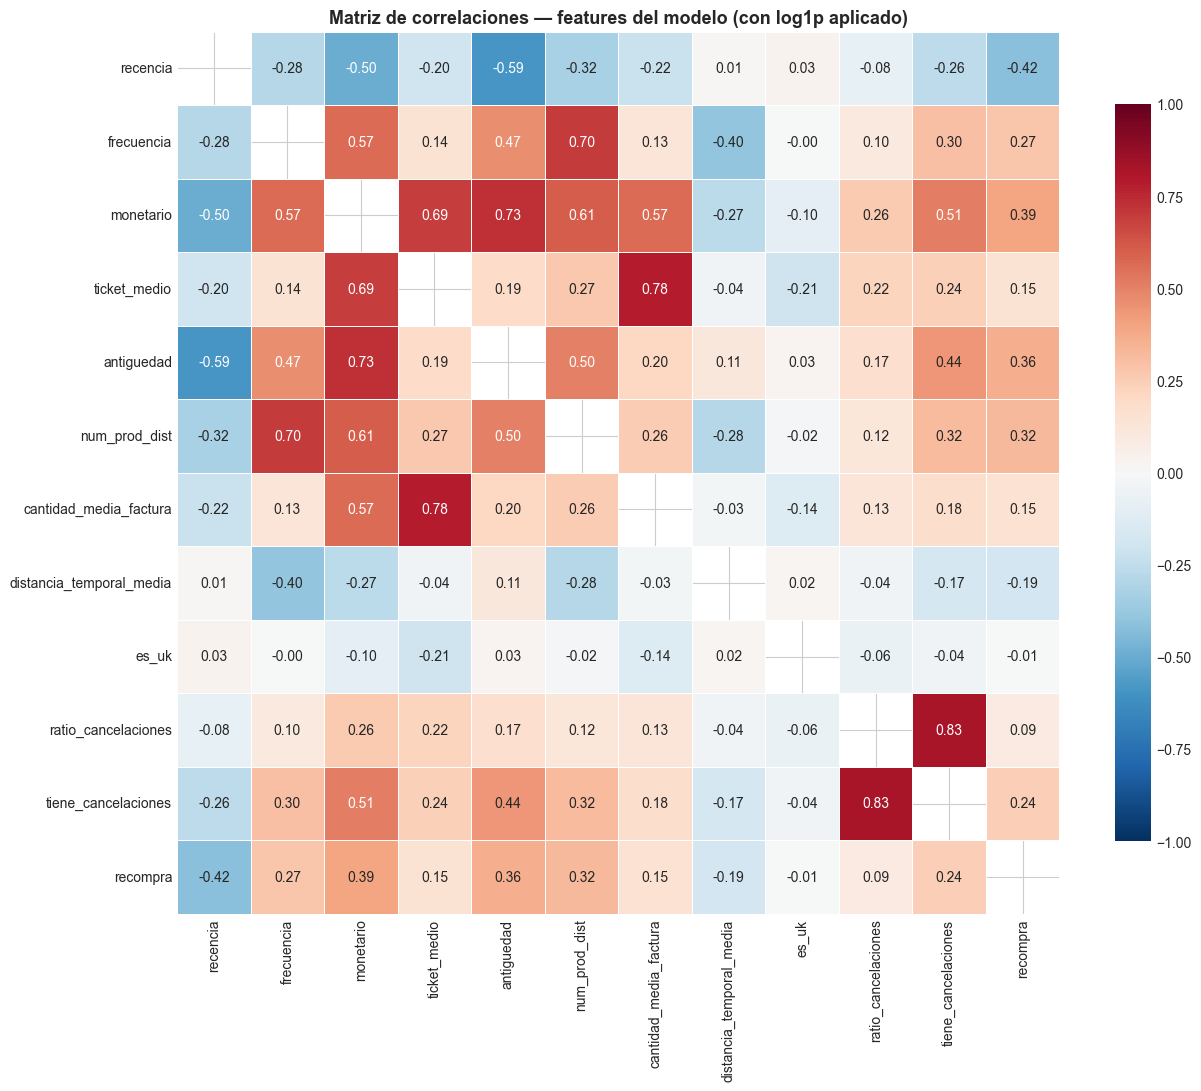

=== PARES CON CORRELACIÓN |r| > 0.6 ===
  [ALTA]  ratio_cancelaciones              ↔  tiene_cancelaciones               r = +0.826
  [MODERADA]  cantidad_media_factura           ↔  ticket_medio                      r = +0.782
  [MODERADA]  antiguedad                       ↔  monetario                         r = +0.731
  [MODERADA]  frecuencia                       ↔  num_prod_dist                     r = +0.697
  [MODERADA]  monetario                        ↔  ticket_medio                      r = +0.688
  [MODERADA]  monetario                        ↔  num_prod_dist                     r = +0.608

=== CORRELACIÓN DE CADA FEATURE CON LA VARIABLE OBJETIVO ===


,r con recompra
recencia,-0.42
monetario,0.40
antiguedad,0.36
num_prod_dist,0.32
frecuencia,0.28
tiene_cancelaciones,0.24
distancia_temporal_media,-0.18
cantidad_media_factura,0.15
ticket_medio,0.14
ratio_cancelaciones,0.09


In [784]:
# Correlaciones sobre el dataset transformado, incluyendo recompra para ver poder predictivo.
corr_cols = FEATURE_COLS + ['recompra']
corr = rfm_fe[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
# Ocultamos la diagonal (siempre 1.0 — no aporta información).
mask = np.eye(len(corr_cols), dtype=bool)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlaciones — features del modelo (con log1p aplicado)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Pares de features con correlación alta (|r| > 0.6, excluye la diagonal y recompra).
corr_feat = rfm_fe[FEATURE_COLS].corr()
pares = [
    (c1, c2, round(corr_feat.loc[c1, c2], 3))
    for c1 in FEATURE_COLS for c2 in FEATURE_COLS
    if c1 < c2 and abs(corr_feat.loc[c1, c2]) > 0.6
]
print('=== PARES CON CORRELACIÓN |r| > 0.6 ===')
if pares:
    for c1, c2, r in sorted(pares, key=lambda x: abs(x[2]), reverse=True):
        nivel = 'ALTA' if abs(r) > 0.8 else 'MODERADA'
        print(f'  [{nivel}]  {c1:<32} ↔  {c2:<32}  r = {r:+.3f}')
else:
    print('  Sin pares con |r| > 0.6 — sin multicolinealidad severa.')

print()
print('=== CORRELACIÓN DE CADA FEATURE CON LA VARIABLE OBJETIVO ===')
corr_target = (corr['recompra']
               .drop('recompra')
               .sort_values(key=abs, ascending=False))
display(corr_target.round(3)
        .to_frame()
        .rename(columns={'recompra': 'r con recompra'}))

### Interpretación de la matriz de correlaciones

**Correlaciones entre features — multicolinealidad identificada:**

- **`tiene_cancelaciones` ↔ `ratio_cancelaciones`:** Correlación alta esperada — una es binaria (¿canceló alguna vez?) y la otra cuantitativa (proporción de facturas canceladas). Miden aspectos distintos del mismo comportamiento. Al actuar principalmente como variables de control, mantener ambas es válido. Se documenta para la interpretación de coeficientes en regresión logística.

- **`cantidad_media_factura` ↔ `ticket_medio`:** Ambas capturan el «tamaño del pedido» desde ángulos distintos — gasto económico por factura vs. volumen de unidades por factura. Se correlacionan porque un pedido grande tiende a tener más ítems *y* más valor simultáneamente. Son controles distintos con sentido propio; se mantienen ambas.

- **`antigüedad` ↔ `monetario`:** Los clientes más antiguos gastan más. Correlación lógica: mayor historial implica mayor confianza y conocimiento del catálogo.

- **`frecuencia` ↔ `num_prod_dist` y `monetario` ↔ `num_prod_dist`:** Refleja el perfil mayorista — los clientes que compran más y gastan más tienden a explorar un catálogo más amplio. La correlación `frecuencia` ↔ `num_prod_dist` también captura clientes retail con conocimiento profundo del catálogo.

**Correlación de cada feature con la variable objetivo `recompra`:**

| Posición | Feature | Señal | Interpretación |
|---|---|---|---|
| 1ª | `recencia` | Negativa (más fuerte) | Cuanto más reciente la última compra, mayor probabilidad de recomprar. Valida el marco RFM. |
| 2ª | `monetario` | Positiva | Los clientes de mayor gasto son los más fieles. |
| 3ª–4ª | `antigüedad`, `num_prod_dist` | Positiva | Superan a `frecuencia`: tiempo activo y conocimiento del catálogo predicen mejor que frecuencia bruta. |
| ~5ª | `ratio_cancelaciones` | Negativa | Peso similar a `frecuencia`. Señal accionable: clientes con muchas cancelaciones tienen menor probabilidad de recompra — oportunidad directa para el equipo de retención. |
| Baja | `es_uk` | Mínima | Válida como control, no como predictor principal. Confirma que no hacer one-hot de todos los países fue la decisión correcta. |

**Conclusión:** No hay multicolinealidad severa que requiera eliminar variables. Los pares correlacionados se documentan y se tendrán en cuenta al interpretar los coeficientes de la regresión logística en la sección 6.

### 5.3 Train/test split — separación de datos de entrenamiento y validación

Esta es una de las ideas más importantes del Machine Learning. Vamos despacio.

**El problema fundamental**

Supón que entrenas el modelo con los 5.438 clientes y luego lo evalúas con esos
mismos 5.438 clientes. El modelo ya «vio» esas respuestas durante el entrenamiento —
podría haber memorizado las respuestas en lugar de aprender patrones generales.
Medir el error sobre los mismos datos que usaste para entrenar no dice nada útil:
es como hacerle a alguien un examen con exactamente las preguntas que estudió.

La solución: **reservar una parte de los datos antes de entrenar**, que el modelo
nunca ve durante el entrenamiento. Al final evaluamos sobre esos datos «frescos».

> *Equivalente econométrico:* es la **validación fuera de muestra** que conoces de
> econometría. Si en STATA estimas un modelo con datos 2000-2015 y luego mides su
> capacidad para predecir los datos reales de 2016-2020, estás haciendo exactamente
> lo mismo. El modelo aprendió los patrones en el período de estimación (train) y
> se evalúa en datos que nunca vio (test). Los modelos de pronóstico macroeconómico
> del FMI o del Banco Mundial siempre reservan un período out-of-sample para validar
> que el modelo no está sobreajustado al período de estimación.

**Los tres parámetros del split:**

**`test_size=0.2`** — 80% para train (~4.350 clientes), 20% para test (~1.088 clientes).
Es la proporción estándar. Con más train, el modelo aprende mejor. Con más test,
la evaluación es más representativa. 80/20 equilibra ambos objetivos.

**`stratify=y`** — garantiza que la proporción de clases (39% recompra=1) se mantiene
igual en train y en test. Sin esto podría ocurrir por azar que el test tuviera 45%
de positivos y el train solo 37%, haciendo la comparación injusta. Es el equivalente
al **muestreo estratificado** de estadística: aseguras que cada estrato (clase) queda
representado en la misma proporción en la muestra y el complemento.

**`random_state=42`** — semilla que fija cuáles clientes van a train y cuáles a test.
Garantiza reproducibilidad: cualquier persona que ejecute el notebook obtiene
exactamente los mismos resultados. Es el equivalente al `set seed 42` de STATA.

**¿Por qué el split va ANTES del escalado?**  
Porque el StandardScaler de la siguiente sección calcula la media y la desviación
estándar de los datos para transformarlos. Si calculamos esas estadísticas sobre todo
el dataset (incluyendo test) y luego dividimos, el modelo estaría usando indirectamente
información de test para calibrar la escala — un tipo de data leakage. Al dividir
primero, el scaler aprende solo de train.

In [785]:
from sklearn.model_selection import train_test_split

X = rfm_fe[FEATURE_COLS]
y = rfm_fe['recompra']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Mantiene la proporción de clases en ambos conjuntos.
)

print('=== TRAIN / TEST SPLIT ===')
print(f'Total clientes:  {len(X):,}')
print(f'  Train:         {len(X_train):,} clientes ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test:          {len(X_test):,}  clientes ({len(X_test)/len(X)*100:.0f}%)')
print()
print('=== VERIFICACIÓN DE PROPORCIONES (stratify=y) ===')
print(f'  recompra = 1 en total: {y.mean()*100:.1f}%')
print(f'  recompra = 1 en train: {y_train.mean()*100:.1f}%')
print(f'  recompra = 1 en test:  {y_test.mean()*100:.1f}%')
print()
print('Las tres proporciones deben ser ~39% — el stratify=y lo garantiza.')

=== TRAIN / TEST SPLIT ===
Total clientes:  5,438
  Train:         4,350 clientes (80%)
  Test:          1,088  clientes (20%)

=== VERIFICACIÓN DE PROPORCIONES (stratify=y) ===
  recompra = 1 en total: 39.0%
  recompra = 1 en train: 39.0%
  recompra = 1 en test:  39.0%

Las tres proporciones deben ser ~39% — el stratify=y lo garantiza.


### 5.4 Escalado — StandardScaler

Tenemos 11 features que miden cosas completamente distintas:

| Feature | Unidad | Rango típico |
|---|---|---|
| `recencia` | días | 1 → 700 |
| `monetario` (tras log1p) | log(£) | 1 → 12 |
| `es_uk` | binaria | 0 ó 1 |
| `ratio_cancelaciones` | proporción | 0.0 → 1.0 |
| `frecuencia` | número de facturas | 1 → 331 |

**El problema de las escalas distintas**

La regresión logística ajusta sus coeficientes usando un algoritmo llamado
**descenso de gradiente**: en cada iteración da un pequeño paso en la dirección
que más reduce el error. Si `recencia` va de 1 a 700 y `es_uk` va de 0 a 1,
los pasos para cada variable son de tamaños completamente distintos. El modelo
llega al resultado, pero más lento y con menos estabilidad numérica.

Más importante: **los coeficientes no son comparables entre sí**. Un coeficiente
de 0.05 para `recencia` (medida en días) no es comparable con un coeficiente de
1.2 para `es_uk` (medida en 0/1). No puedes leer directamente «cuál variable
importa más» mirando los coeficientes crudos del modelo.

**El StandardScaler: media 0, desviación estándar 1**

Para cada feature aplica:
```
x_escalada = (x − media_train) / std_train
```
El resultado: todas las features tienen media 0 y desviación estándar 1.
Un valor de +1 significa «1 desviación estándar por encima del cliente promedio».
Un valor de −2 significa «2 desviaciones estándar por debajo del promedio».
Ahora sí son comparables entre sí.

> *Equivalente econométrico:* es exactamente lo mismo que los **coeficientes
> estandarizados (beta)** que en STATA se obtienen con `listcoef` o con la
> opción `beta` después de un `regress`. Los coeficientes beta eliminan las
> unidades de medida y permiten comparar directamente la importancia relativa
> de cada variable. El StandardScaler hace eso mismo antes de estimar, no
> después.

**La regla crítica: fit solo en TRAIN, transform en TRAIN y TEST**

El scaler aprende la media y la std exclusivamente de los datos de train.
Luego aplica esa misma transformación al test. Si calculásemos media y std
sobre todo el dataset (incluido test), el modelo «vería» indirectamente
información del test durante el entrenamiento — data leakage.

```python
# ✅ CORRECTO
scaler.fit(X_train)                      # Aprende media/std solo de train
X_train_sc = scaler.transform(X_train)  # Aplica a train
X_test_sc  = scaler.transform(X_test)   # Aplica las MISMAS estadísticas a test

# ❌ INCORRECTO — data leakage de preprocesamiento
scaler.fit_transform(X)                  # Nunca escalar todo el dataset junto
```

**¿Y Random Forest y XGBoost?**  
Técnicamente no necesitan escalado — los árboles no usan distancias ni gradientes,
funcionan por umbrales (`si recencia > 180 días → rama izquierda`) que son
independientes de la escala de la variable. Sin embargo, aplicamos el mismo
escalado a los tres modelos para que la comparación de la sección 6 sea justa:
todos reciben exactamente los mismos datos de entrada.

In [786]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform en train: aprende media/std Y transforma en un paso.
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS,
    index=X_train.index
)

# transform en test: aplica las estadísticas del train (sin reaprender).
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS,
    index=X_test.index
)

print('=== VERIFICACIÓN DEL ESCALADO ===')
print('Media de cada feature en train (debe ser ≈ 0.00):')
display(X_train_scaled.mean().round(4).to_frame(name='media_train').T)
print()
print('Std de cada feature en train (debe ser ≈ 1.00):')
display(X_train_scaled.std().round(4).to_frame(name='std_train').T)
print()
print('Media de cada feature en test (no será exactamente 0 — el scaler usó estadísticas del train):')
display(X_test_scaled.mean().round(4).to_frame(name='media_test').T)
print()
print('La media del test se aleja de 0 en proporción a cuánto difiere la distribución')
print('del test respecto al train. Con 80/20 aleatorio debe ser pequeña.')

=== VERIFICACIÓN DEL ESCALADO ===
Media de cada feature en train (debe ser ≈ 0.00):


,recencia,frecuencia,monetario,ticket_medio,antiguedad,num_prod_dist,cantidad_media_factura,distancia_temporal_media,es_uk,ratio_cancelaciones,tiene_cancelaciones
media_train,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00



Std de cada feature en train (debe ser ≈ 1.00):


,recencia,frecuencia,monetario,ticket_medio,antiguedad,num_prod_dist,cantidad_media_factura,distancia_temporal_media,es_uk,ratio_cancelaciones,tiene_cancelaciones
std_train,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00



Media de cada feature en test (no será exactamente 0 — el scaler usó estadísticas del train):


,recencia,frecuencia,monetario,ticket_medio,antiguedad,num_prod_dist,cantidad_media_factura,distancia_temporal_media,es_uk,ratio_cancelaciones,tiene_cancelaciones
media_test,0.00,-0.03,-0.00,-0.00,-0.03,0.03,0.02,-0.06,0.03,-0.01,-0.02



La media del test se aleja de 0 en proporción a cuánto difiere la distribución
del test respecto al train. Con 80/20 aleatorio debe ser pequeña.


### 5.5 Guardar datos preprocesados

Guardamos los objetos que necesita la sección 6 (Modelado):

- `X_train.pkl` / `X_test.pkl`: features escaladas (11 columnas, listas para sklearn)
- `y_train.pkl` / `y_test.pkl`: variable objetivo
- `scaler.pkl`: el objeto scaler entrenado — necesario en la sección 8 para aplicar
  la misma transformación cuando queramos predecir sobre nuevos clientes reales

Guardamos también `rfm_fe` (dataset con log1p aplicado) como referencia para
los análisis de interpretabilidad de la sección 9.

In [787]:
import pickle

PREP_DIR = CLEAN_DATA / 'preprocessed'
PREP_DIR.mkdir(parents=True, exist_ok=True)

X_train_scaled.to_pickle(PREP_DIR / 'X_train.pkl')
X_test_scaled.to_pickle(PREP_DIR / 'X_test.pkl')
y_train.to_pickle(PREP_DIR / 'y_train.pkl')
y_test.to_pickle(PREP_DIR / 'y_test.pkl')
rfm_fe.to_pickle(PREP_DIR / 'rfm_fe.pkl')

with open(PREP_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('=== DATOS PREPROCESADOS GUARDADOS ===')
print(f'Directorio: {PREP_DIR}')
print(f'  X_train:  {X_train_scaled.shape}  →  X_train.pkl')
print(f'  X_test:   {X_test_scaled.shape}   →  X_test.pkl')
print(f'  y_train:  {y_train.shape}')
print(f'  y_test:   {y_test.shape}')
print(f'  scaler    →  scaler.pkl')
print(f'  rfm_fe    →  rfm_fe.pkl (con log1p, sin escalar — referencia para sección 9)')
print()
print('Listos para la sección 6 — Modelado.')

=== DATOS PREPROCESADOS GUARDADOS ===
Directorio: /Users/usuario/Downloads/DATA_SCIENCE/Quinto_Módulo_ML/Proyecto_ML_Pujana/DATA/clean_data/preprocessed
  X_train:  (4350, 11)  →  X_train.pkl
  X_test:   (1088, 11)   →  X_test.pkl
  y_train:  (4350,)
  y_test:   (1088,)
  scaler    →  scaler.pkl
  rfm_fe    →  rfm_fe.pkl (con log1p, sin escalar — referencia para sección 9)

Listos para la sección 6 — Modelado.


---
<a id="seccion-6"></a>
## 6. Modelado

Esta sección entrena tres modelos de clasificación binaria sobre los datos preprocesados
de la sección 5 y compara su rendimiento con una tabla de métricas.

**Estrategia general:**

| Modelo | Por qué lo incluimos |
|---|---|
| Regresión Logística | Baseline interpretable — equivalente al `logit` de STATA |
| Random Forest | Captura relaciones no lineales sin supuestos distribucionales |
| XGBoost | Gradient boosting — generalmente el más preciso en datos tabulares |

**Métrica principal: AUC-ROC**  
Con 39% / 61% de desbalanceo, la *accuracy* sola engaña — un modelo que siempre
predice "no recompra" tendría 61% de accuracy sin haber aprendido nada.
El AUC-ROC mide la capacidad discriminante del modelo independientemente del umbral
de decisión, y es la métrica estándar para clasificación binaria con desbalanceo moderado.

> *Equivalente econométrico:* el **estadístico C** (concordancia) que aparece en los
> logit de STATA al hacer `fitstat` o en los modelos de predicción de default del
> Banco Mundial. Un AUC de 0.5 equivale a un modelo sin capacidad discriminante;
> AUC > 0.80 se considera bueno para aplicaciones de negocio.

### 6.0 Carga de datos preprocesados

Cargamos los archivos generados en la sección 5. `CLEAN_DATA` y `FEATURE_COLS` ya están
definidos en celdas anteriores del notebook.

In [788]:
import pickle
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)

PREP_DIR = CLEAN_DATA / 'preprocessed'

X_train = pd.read_pickle(PREP_DIR / 'X_train.pkl')
X_test  = pd.read_pickle(PREP_DIR / 'X_test.pkl')
y_train = pd.read_pickle(PREP_DIR / 'y_train.pkl')
y_test  = pd.read_pickle(PREP_DIR / 'y_test.pkl')

with open(PREP_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

FEATURE_COLS = X_train.columns.tolist()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train — recompra=1: {y_train.mean()*100:.1f}%  |  y_test: {y_test.mean()*100:.1f}%')
print(f'Features: {FEATURE_COLS}')

X_train: (4350, 11)  |  X_test: (1088, 11)
y_train — recompra=1: 39.0%  |  y_test: 39.0%
Features: ['recencia', 'frecuencia', 'monetario', 'ticket_medio', 'antiguedad', 'num_prod_dist', 'cantidad_media_factura', 'distancia_temporal_media', 'es_uk', 'ratio_cancelaciones', 'tiene_cancelaciones']


### Función auxiliar de evaluación

Definimos una función que entrena un modelo, calcula todas las métricas y devuelve
los resultados en un diccionario. Se usa igual para los tres modelos: reduce
duplicación de código y garantiza que todos se evalúan de forma idéntica.

**¿Qué mide cada métrica?**

| Métrica | Fórmula | Interpretación en negocio |
|---|---|---|
| **AUC-ROC** | Área bajo la curva ROC | Capacidad global de ordenar correctamente: clientes que sí recompran vs. los que no. No depende del umbral elegido. |
| **Accuracy** | (TP + TN) / Total | % de predicciones correctas. Puede ser engañosa con desbalanceo. |
| **Precisión** | TP / (TP + FP) | De los clientes que el modelo predice que recomprarán, ¿cuántos realmente lo hacen? Alta precisión = pocos recursos malgastados en falsos positivos. |
| **Recall** | TP / (TP + FN) | De los clientes que sí recomprarán, ¿cuántos detecta el modelo? Alto recall = no dejamos escapar clientes valiosos. |
| **F1** | 2 × (P × R) / (P + R) | Media armónica de Precisión y Recall. Equilibra ambos objetivos cuando hay desbalanceo. |

> *Trade-off Precisión / Recall:* en un modelo de retención, el coste de no detectar
> a un cliente que sí regresaría (falso negativo) suele ser mayor que el coste de
> ofrecer un descuento a alguien que habría comprado de todas formas (falso positivo).
> Por eso el Recall es especialmente relevante aquí, junto al AUC-ROC.

In [789]:
# Almacena resultados de todos los modelos para la tabla comparativa final.
resultados = []

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena, predice y calcula métricas. Devuelve dict con resultados y modelo entrenado."""
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    return {
        'Modelo':     nombre,
        'AUC-ROC':    roc_auc_score(y_te, y_proba),
        'Accuracy':   accuracy_score(y_te, y_pred),
        'F1':         f1_score(y_te, y_pred),
        'Precisión':  precision_score(y_te, y_pred),
        'Recall':     recall_score(y_te, y_pred),
        '_modelo':    modelo,
        '_y_proba':   y_proba,
        '_y_pred':    y_pred,
    }

print('Función evaluar_modelo definida.')

Función evaluar_modelo definida.


### 6.1 Regresión Logística — baseline interpretable

La regresión logística es el punto de partida obligatorio de cualquier proyecto de
clasificación binaria. Es el modelo más transparente: cada coeficiente tiene una
interpretación directa, como en el `logit` de STATA.

**La ecuación del modelo:**

```
log(p / (1-p)) = β₀ + β₁·recencia + β₂·monetario + ... + β₁₁·tiene_cancelaciones
```

Donde `p` = probabilidad de recompra. El lado izquierdo es el **log-odds**
(logaritmo de las chances), no una probabilidad.

**¿Cómo se interpretan los coeficientes β?**

Como todas las features fueron estandarizadas (media=0, std=1) en la sección 5.4,
los β son directamente comparables entre sí — son equivalentes a los
**betas estandarizados** de STATA:

| Lectura | Cálculo | Ejemplo con β = −0.50 en recencia |
|---|---|---|
| **Log-odds** | β directamente | Por cada σ adicional en log(recencia), el log-odds de recompra baja en 0.50 |
| **Odds-ratio** | e^β | e^(−0.50) ≈ 0.61 → las chances de recompra se reducen al 61% por cada σ |
| **Efecto marginal aproximado** | β × p̄ × (1−p̄) | −0.50 × 0.39 × 0.61 ≈ −0.12 → −12 puntos porcentuales en probabilidad |

El mayor |β| indica la feature más influyente. El signo dice la dirección del efecto.

> *Equivalente econométrico exacto:* es el modelo `logit` de STATA con `beta` como
> opción para coeficientes estandarizados. La diferencia: sklearn usa regularización
> L2 por defecto (`C=1`), equivalente a un Ridge muy suave, para mejorar la
> estabilidad numérica.

=== MÉTRICAS — REGRESIÓN LOGÍSTICA ===
  AUC-ROC:   0.8060
  Accuracy:  0.7537
  F1:        0.6573
  Precisión: 0.7179
  Recall:    0.6061


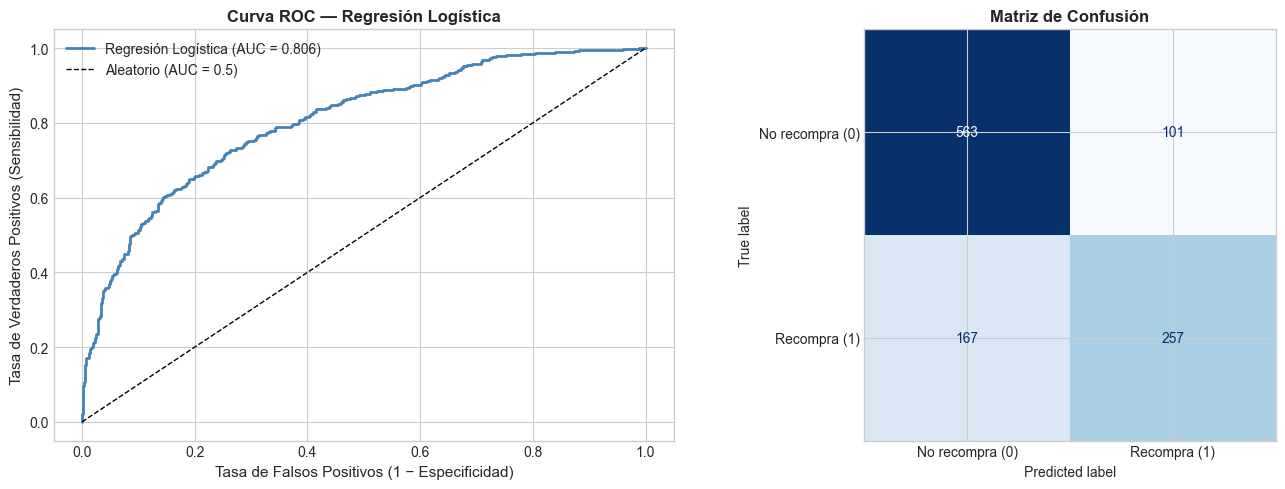

In [790]:
from sklearn.linear_model import LogisticRegression

# max_iter=1000: el optimizador tiene más iteraciones para converger.
# C=1.0: regularización L2 por defecto (equivalente Ridge suave).
lr = LogisticRegression(max_iter=1000, random_state=42)
res_lr = evaluar_modelo('Regresión Logística', lr, X_train, y_train, X_test, y_test)
resultados.append({k: v for k, v in res_lr.items() if not k.startswith('_')})

print('=== MÉTRICAS — REGRESIÓN LOGÍSTICA ===')
print(f'  AUC-ROC:   {res_lr["AUC-ROC"]:.4f}')
print(f'  Accuracy:  {res_lr["Accuracy"]:.4f}')
print(f'  F1:        {res_lr["F1"]:.4f}')
print(f'  Precisión: {res_lr["Precisión"]:.4f}')
print(f'  Recall:    {res_lr["Recall"]:.4f}')

# Curva ROC y matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, res_lr['_y_proba'])
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Regresión Logística (AUC = {res_lr["AUC-ROC"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[0].set_title('Curva ROC — Regresión Logística', fontweight='bold')
axes[0].legend(fontsize=10)

cm = confusion_matrix(y_test, res_lr['_y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No recompra (0)', 'Recompra (1)'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación de la Curva ROC:**

La curva muestra el balance entre **sensibilidad** (detectar a los que sí recompran)
y **especificidad** (no confundir a los que no recompran) para cada umbral posible.

- La diagonal punteada = modelo aleatorio (AUC = 0.5): no distingue entre clases.
- Cuanto más se aleja la curva hacia la esquina superior izquierda, mejor discrimina el modelo.

**Interpretación de la Matriz de Confusión:**

|  | Predicho: No recompra | Predicho: Recompra |
|---|---|---|
| **Real: No recompra** | Verdadero Negativo (TN) | Falso Positivo (FP) — ofrecemos descuento innecesario |
| **Real: Recompra** | Falso Negativo (FN) — perdemos un cliente fiel | Verdadero Positivo (TP) |

El coste de negocio de un FN (no detectar a un cliente que sí regresaría) suele ser
mayor que el de un FP (ofrecer un incentivo a alguien que habría comprado de todas formas).

In [791]:
# Tabla de coeficientes: log-odds, odds-ratio, efecto marginal e interpretación.
import numpy as np

interpretaciones = {
    'recencia':                 'Más días desde la última compra → menor probabilidad de recompra',
    'monetario':                'Mayor gasto histórico → mayor fidelización al negocio',
    'frecuencia':               'Mayor número de compras → cliente más activo',
    'ticket_medio':             'Ticket más alto → perfil mayorista o cliente premium',
    'antiguedad':               'Mayor historial activo → mayor arraigo al negocio',
    'num_prod_dist':            'Mayor diversidad de productos → cliente más explorador del catálogo',
    'cantidad_media_factura':   'Más unidades por factura → pedidos más grandes',
    'distancia_temporal_media': 'Mayor distancia entre compras → comprador más esporádico',
    'es_uk':                    'Cliente del Reino Unido (control geográfico)',
    'ratio_cancelaciones':      'Mayor proporción de cancelaciones → mayor riesgo de abandono',
    'tiene_cancelaciones':      'Haber cancelado alguna vez (variable de control)',
}

p_bar = y_train.mean()  # Prevalencia en train ≈ 0.39

coef_df = pd.DataFrame({
    'feature':          FEATURE_COLS,
    'β (log-odds)':     lr.coef_[0],
    'Odds-Ratio':       np.exp(lr.coef_[0]),
    'Efecto marginal':  lr.coef_[0] * p_bar * (1 - p_bar),
}).sort_values('β (log-odds)', key=abs, ascending=False).reset_index(drop=True)

# Tabla numérica
print('=== COEFICIENTES — REGRESIÓN LOGÍSTICA ===')
print(f'(ordenados por |β| descendente — mayor importancia primero)')
print(f'Intercepto β₀: {lr.intercept_[0]:.4f}  |  Prevalencia p̄: {p_bar:.3f}\n')

numeric_cols = coef_df[['feature', 'β (log-odds)', 'Odds-Ratio', 'Efecto marginal']].copy()
numeric_cols['β (log-odds)']   = numeric_cols['β (log-odds)'].map('{:+.4f}'.format)
numeric_cols['Odds-Ratio']      = numeric_cols['Odds-Ratio'].map('{:.4f}'.format)
numeric_cols['Efecto marginal'] = numeric_cols['Efecto marginal'].map('{:+.4f}'.format)
display(numeric_cols.set_index('feature'))

# Interpretaciones separadas para legibilidad
print('\n=== INTERPRETACIÓN EN LENGUAJE NATURAL ===')
print('(efecto marginal ≈ cambio en probabilidad de recompra por cada +1σ en la feature)\n')
for _, row in coef_df.iterrows():
    signo = '▲' if row['β (log-odds)'] > 0 else '▼'
    print(f"  {signo} {row['feature']:<30}  Δp ≈ {row['Efecto marginal']:+.2f}pp")
    print(f"     {interpretaciones[row['feature']]}")
    print()

=== COEFICIENTES — REGRESIÓN LOGÍSTICA ===
(ordenados por |β| descendente — mayor importancia primero)
Intercepto β₀: -0.5656  |  Prevalencia p̄: 0.390



,β (log-odds),Odds-Ratio,Efecto marginal
feature,,,
recencia,-0.8659,0.4207,-0.2060
monetario,+0.5697,1.7677,+0.1355
num_prod_dist,+0.4087,1.5049,+0.0972
ticket_medio,-0.3230,0.7240,-0.0768
antiguedad,-0.2359,0.7898,-0.0561
frecuencia,+0.1801,1.1973,+0.0428
distancia_temporal_media,-0.1641,0.8487,-0.0390
cantidad_media_factura,+0.0861,1.0899,+0.0205
ratio_cancelaciones,+0.0323,1.0328,+0.0077



=== INTERPRETACIÓN EN LENGUAJE NATURAL ===
(efecto marginal ≈ cambio en probabilidad de recompra por cada +1σ en la feature)

  ▼ recencia                        Δp ≈ -0.21pp
     Más días desde la última compra → menor probabilidad de recompra

  ▲ monetario                       Δp ≈ +0.14pp
     Mayor gasto histórico → mayor fidelización al negocio

  ▲ num_prod_dist                   Δp ≈ +0.10pp
     Mayor diversidad de productos → cliente más explorador del catálogo

  ▼ ticket_medio                    Δp ≈ -0.08pp
     Ticket más alto → perfil mayorista o cliente premium

  ▼ antiguedad                      Δp ≈ -0.06pp
     Mayor historial activo → mayor arraigo al negocio

  ▲ frecuencia                      Δp ≈ +0.04pp
     Mayor número de compras → cliente más activo

  ▼ distancia_temporal_media        Δp ≈ -0.04pp
     Mayor distancia entre compras → comprador más esporádico

  ▲ cantidad_media_factura          Δp ≈ +0.02pp
     Más unidades por factura → pedidos más gra

### 6.2 Random Forest — ensamble de árboles de decisión

**¿Qué es un árbol de decisión?**  
Es una secuencia de preguntas binarias sobre las features:
*"¿recencia > 1.2?"* → sí → *"¿monetario > 0.8?"* → no → predice "no recompra".
Un solo árbol tiende a memorizar los datos de train (overfitting). La solución: construir
muchos árboles y que voten juntos.

**¿Cómo funciona el Random Forest?**

1. **Bootstrap:** cada árbol se entrena con una muestra aleatoria *con reemplazo* del dataset
   de train (≈63% de las filas, diferentes en cada árbol).
2. **Aleatoriedad de features:** en cada división del árbol, no evalúa todas las features
   sino un subconjunto aleatorio — esto fuerza diversidad entre árboles.
3. **Votación:** para clasificar un cliente nuevo, los 100 árboles votan y gana la mayoría.

**¿En qué se diferencia de la regresión logística?**

| Dimensión | Regresión Logística | Random Forest |
|---|---|---|
| Relaciones capturadas | Solo lineales en log-odds | No lineales e interacciones |
| Supuestos | Relación lineal, sin multicolinealidad severa | Ninguno |
| Interpretación | Coeficientes β directos | Feature importance (no coeficientes) |
| Overfitting | Bajo (regularización L2) | Controlado por profundidad máxima y mínimo de hojas |
| Sensibilidad a escala | Requiere escalado | No requiere (árboles no dependen de escala) |

**Feature importance en RF:**  
En lugar de coeficientes β, Random Forest calcula cuánto reduce cada feature la
impureza (Gini) a través de todos los árboles. El resultado es una importancia
relativa (suma = 1), no un coeficiente interpretable en sentido causal.

=== MÉTRICAS — RANDOM FOREST ===
  AUC-ROC:   0.8048
  Accuracy:  0.7399
  F1:        0.6281
  Precisión: 0.7092
  Recall:    0.5637


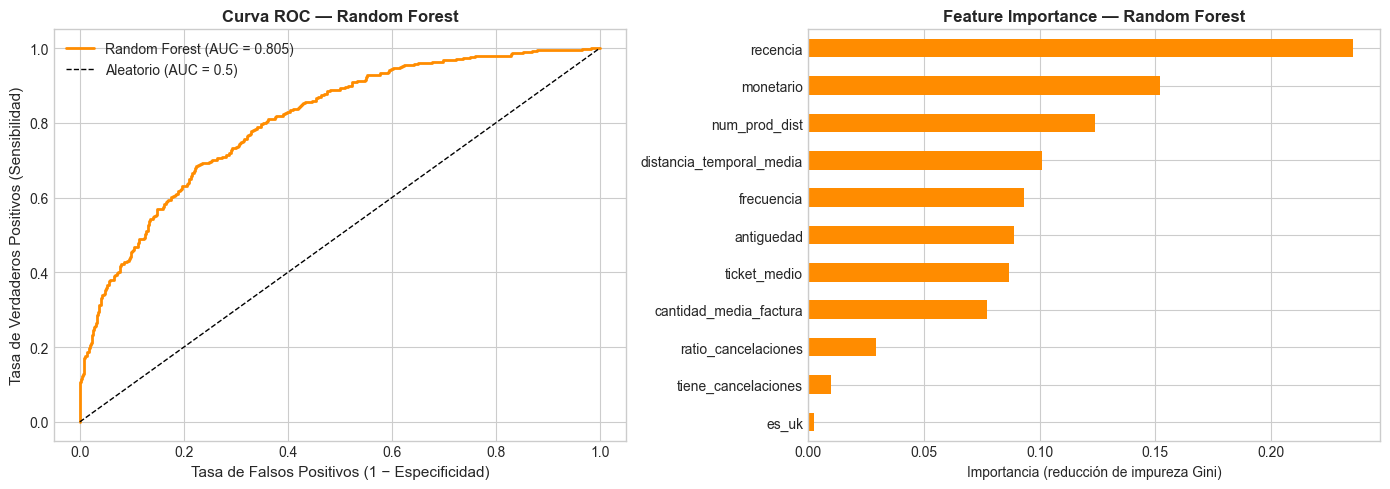

In [792]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=200: 200 árboles — más que el default (100) para mayor estabilidad.
# max_depth=None: árboles sin límite de profundidad (el bosque se auto-regula).
# min_samples_leaf=5: cada hoja necesita mínimo 5 clientes — evita overfitting extremo.
# n_jobs=-1: usa todos los núcleos disponibles en paralelo.
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
res_rf = evaluar_modelo('Random Forest', rf, X_train, y_train, X_test, y_test)
resultados.append({k: v for k, v in res_rf.items() if not k.startswith('_')})

print('=== MÉTRICAS — RANDOM FOREST ===')
print(f'  AUC-ROC:   {res_rf["AUC-ROC"]:.4f}')
print(f'  Accuracy:  {res_rf["Accuracy"]:.4f}')
print(f'  F1:        {res_rf["F1"]:.4f}')
print(f'  Precisión: {res_rf["Precisión"]:.4f}')
print(f'  Recall:    {res_rf["Recall"]:.4f}')

# Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, res_rf['_y_proba'])
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Random Forest (AUC = {res_rf["AUC-ROC"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[0].set_title('Curva ROC — Random Forest', fontweight='bold')
axes[0].legend(fontsize=10)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importancia (reducción de impureza Gini)')

plt.tight_layout()
plt.show()

**¿Cómo leer el Feature Importance de Random Forest?**

- Mide cuánto contribuye cada feature a reducir la impureza (error) en promedio
  a través de todos los árboles y todas las divisiones.
- **No tiene signo** — solo dice cuánto importa, no si el efecto es positivo o negativo.
- Para conocer la dirección del efecto se usan los valores SHAP (sección 9).
- Compara con los |β| de la regresión logística: si ambos coinciden en qué features
  son las más importantes, da mayor confianza a esas variables como señales reales del negocio.

### 6.3 XGBoost — gradient boosting

**¿En qué se diferencia del Random Forest?**

Random Forest construye todos los árboles en paralelo e independientemente.
XGBoost los construye en **secuencia**, donde cada árbol aprende de los errores
del anterior:

```
Árbol 1  → predice recompra  → comete errores  
Árbol 2  → aprende solo de los errores del árbol 1  
Árbol 3  → aprende de los errores acumulados  
...  
Árbol N  → predicción final = suma ponderada de todos
```

El "gradient" del nombre viene de que en cada paso sigue el gradiente
(dirección de máximo descenso) de la función de error — exactamente como
el gradiente descendente de optimización que se usa en redes neuronales,
pero aplicado a árboles de decisión.

**¿Por qué suele ganar en datos tabulares?**  
El boosting corrige errores sistemáticos que el Random Forest no puede corregir
(RF promedia árboles independientes, no aprende de sus propios fallos).
En datos estructurados tipo Excel o base de datos, XGBoost es consistentemente
el modelo de referencia — por eso lo optimizaremos en profundidad en la sección 7.

> *Nota técnica:* `use_label_encoder=False` y `eval_metric='logloss'` son
> parámetros que evitan warnings de versión. `tree_method='hist'` usa un algoritmo
> de histograma más eficiente en memoria — el mismo que LightGBM.

=== MÉTRICAS — XGBOOST ===
  AUC-ROC:   0.7664
  Accuracy:  0.7142
  F1:        0.5987
  Precisión: 0.6610
  Recall:    0.5472


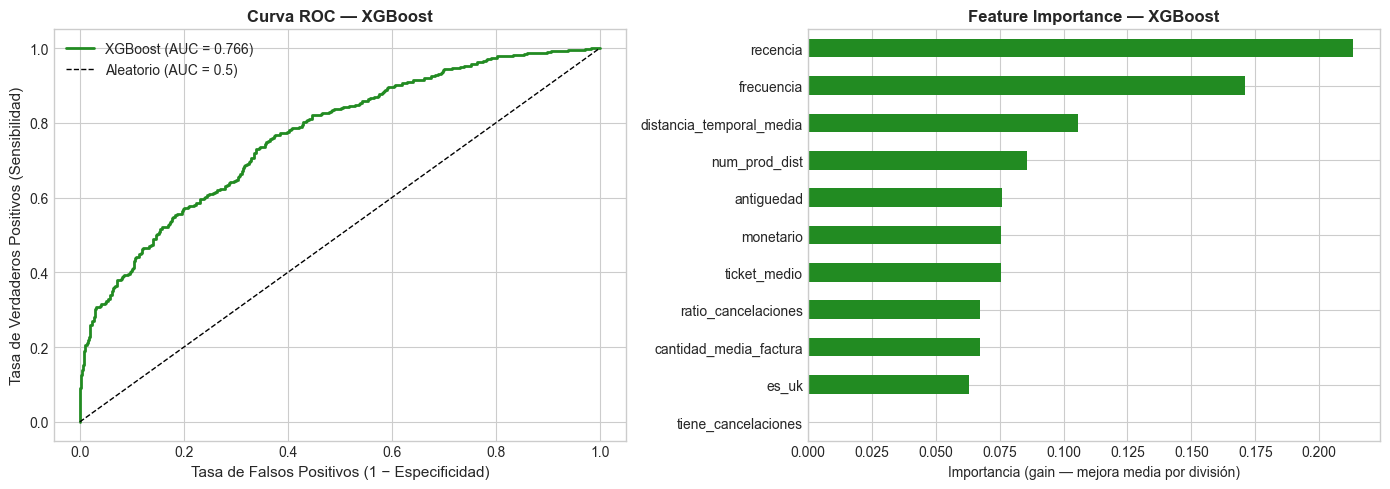

In [793]:
from xgboost import XGBClassifier

# Parámetros base — sin optimizar (eso viene en sección 7 con Optuna).
# n_estimators=300: más árboles que RF porque el boosting puede usar más sin overfittear.
# learning_rate=0.1: tamaño del paso de cada árbol (default).
# max_depth=6: profundidad máxima de cada árbol (default XGBoost).
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    tree_method='hist', eval_metric='logloss',
    random_state=42, n_jobs=-1, verbosity=0
)
res_xgb = evaluar_modelo('XGBoost', xgb, X_train, y_train, X_test, y_test)
resultados.append({k: v for k, v in res_xgb.items() if not k.startswith('_')})

print('=== MÉTRICAS — XGBOOST ===')
print(f'  AUC-ROC:   {res_xgb["AUC-ROC"]:.4f}')
print(f'  Accuracy:  {res_xgb["Accuracy"]:.4f}')
print(f'  F1:        {res_xgb["F1"]:.4f}')
print(f'  Precisión: {res_xgb["Precisión"]:.4f}')
print(f'  Recall:    {res_xgb["Recall"]:.4f}')

# Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, res_xgb['_y_proba'])
axes[0].plot(fpr, tpr, color='forestgreen', lw=2,
             label=f'XGBoost (AUC = {res_xgb["AUC-ROC"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[0].set_title('Curva ROC — XGBoost', fontweight='bold')
axes[0].legend(fontsize=10)

# Feature importance
importances_xgb = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
importances_xgb.plot(kind='barh', ax=axes[1], color='forestgreen')
axes[1].set_title('Feature Importance — XGBoost', fontweight='bold')
axes[1].set_xlabel('Importancia (gain — mejora media por división)')

plt.tight_layout()
plt.show()

### 6.4 Tabla comparativa de modelos

Comparamos los tres modelos sobre el mismo test set con las métricas más relevantes
y las curvas ROC superpuestas para ver visualmente qué tan bien discrimina cada uno.

**¿Por qué la Regresión Logística puede tener el AUC más alto?**

Este resultado, aunque sorprendente, es frecuente y tiene una explicación clara:

| Factor | Explicación |
|---|---|
| **Features linealizadas** | El Feature Engineering (log1p + StandardScaler) hizo que la relación entre features y log-odds sea aproximadamente lineal — exactamente el supuesto de la LR. Si el mundo es lineal, el modelo lineal gana. |
| **Dataset mediano (4.350 train)** | RF y XGBoost extraen más ventaja con datasets grandes. Con 4.350 filas, LR aprende el patrón completo; los árboles tienen más ruido que gestionar. |
| **XGBoost con parámetros por defecto** | `max_depth=6` y 300 árboles sin early stopping puede sobreajustar en datasets medianos — memoriza el train y generaliza peor al test. |

**¿Qué cambia en la sección 7?**  
Optuna busca los hiperparámetros óptimos para XGBoost: profundidad menor (`max_depth` 3-4),
`learning_rate` más bajo, subsampling y regularización. Con esos ajustes, XGBoost
puede superar a la LR — o puede no hacerlo. Ambos resultados son válidos y tienen
conclusiones de negocio distintas.

Si LR sigue siendo la mejor después de la optimización, significa que las relaciones
en este dataset son suficientemente lineales y el Feature Engineering capturó bien
los patrones. No siempre más complejidad implica mejor resultado.

**¿Qué observar en la curva ROC superpuesta?**  
La separación visual entre las tres curvas muestra el gap real en capacidad discriminante.
Una curva cercana a la línea de referencia (AUC ≈ 0.5) indica que el modelo apenas discrimina.
Una curva que sube rápido hacia la esquina superior izquierda indica alta capacidad discriminante.

=== COMPARATIVA DE MODELOS — TEST SET ===



,AUC-ROC,Accuracy,F1,Precisión,Recall
Modelo,,,,,
Regresión Logística,0.81,0.75,0.66,0.72,0.61
Random Forest,0.80,0.74,0.63,0.71,0.56
XGBoost,0.77,0.71,0.60,0.66,0.55



Mejor AUC-ROC: Regresión Logística (0.8060)
Mejor F1:      Regresión Logística (0.6573)


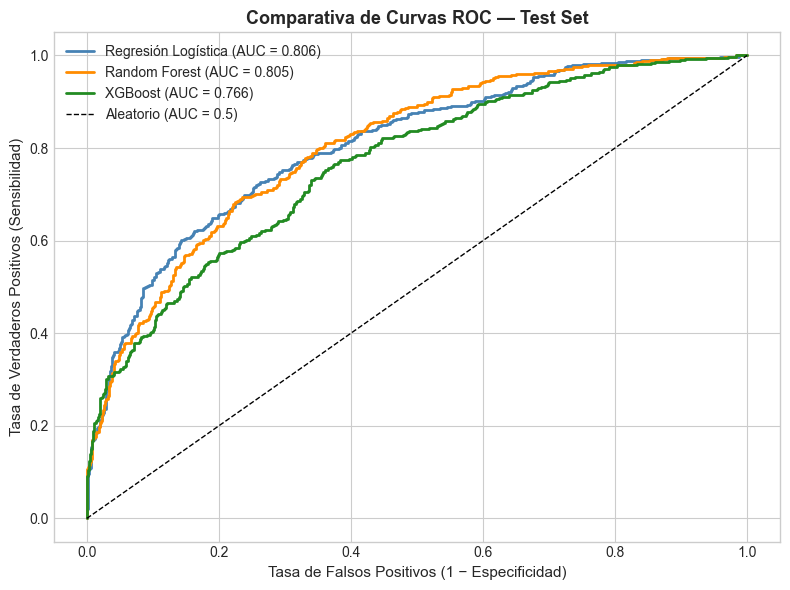


→ La sección 7 optimizará XGBoost con Optuna (≥50 trials) para darle una
  competencia justa frente al baseline de regresión logística.


In [794]:
# Tabla comparativa — formato estándar.
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados_display = df_resultados[['AUC-ROC', 'Accuracy', 'F1', 'Precisión', 'Recall']].copy()

print('=== COMPARATIVA DE MODELOS — TEST SET ===\n')
display(df_resultados_display.round(4))

# Mejor modelo por AUC-ROC
mejor_auc  = df_resultados['AUC-ROC'].idxmax()
mejor_f1   = df_resultados['F1'].idxmax()
print(f'\nMejor AUC-ROC: {mejor_auc} ({df_resultados.loc[mejor_auc, "AUC-ROC"]:.4f})')
print(f'Mejor F1:      {mejor_f1} ({df_resultados.loc[mejor_f1, "F1"]:.4f})')

# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

colores = {'Regresión Logística': 'steelblue',
           'Random Forest':       'darkorange',
           'XGBoost':             'forestgreen'}
modelos = [('Regresión Logística', res_lr),
           ('Random Forest',       res_rf),
           ('XGBoost',             res_xgb)]

for nombre, res in modelos:
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    ax.plot(fpr, tpr, color=colores[nombre], lw=2,
            label=f'{nombre} (AUC = {res["AUC-ROC"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Comparativa de Curvas ROC — Test Set', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('\n→ La sección 7 optimizará XGBoost con Optuna (≥50 trials) para darle una')
print('  competencia justa frente al baseline de regresión logística.')

---
<a id="seccion-7"></a>
## 7. Optimización con Optuna

### ¿Qué son los hiperparámetros y por qué optimizarlos?

En la sección 5.3 explicamos que los datos de train son la guía de estudio y el test
es el examen. El modelo (XGBoost) es el alumno. En la sección 6, ese alumno se presentó
al examen con una **estrategia de estudio arbitraria** — la configuración que trae
XGBoost por defecto, sin ningún ajuste para este dataset específico.

Los **hiperparámetros** son exactamente esa estrategia de estudio. No cambian el temario
(las features son fijas: recencia, monetario, frecuencia...). Cambian *cómo* el alumno
estudia ese temario antes del examen:

> **Ejemplo concreto:** imagina que un alumno tiene que preparar un examen de 11 temas.
> Puede estudiarlos de muchas maneras distintas:
> - **¿Cuántas sesiones de repaso hace?** (`n_estimators` — árboles en secuencia)
> - **¿Qué tan profundo entra en cada tema?** (`max_depth` — profundidad de cada árbol).
>   Demasiado profundo → memoriza ejemplos específicos sin entender el concepto (overfitting).
>   Demasiado superficial → no aprende lo suficiente (underfitting).
> - **¿Qué tan rápido avanza por sesión?** (`learning_rate` — paso de cada árbol).
>   Avanzar despacio y hacer más sesiones suele dar mejor resultado que correr.
> - **¿Estudia todos los apuntes en cada sesión o una muestra aleatoria?** (`subsample`)
>   Estudiar subconjuntos aleatorios obliga al alumno a generalizar en lugar de memorizar.
> - **¿Cubre todos los temas cada sesión o un subconjunto aleatorio?** (`colsample_bytree`)
>   Igual que lo anterior pero con los temas (features) en lugar de los ejemplos (filas).
> - **¿Cuánto necesita mejorar para que valga la pena abrir un subtema nuevo?** (`gamma`, `min_child_weight`)
>   Si la mejora esperada es mínima, no abre esa rama — evita profundizar en ruido.
> - **¿Cuánta penalización por memorizar?** (`reg_alpha`, `reg_lambda`)
>   Castigan al modelo cuando se ajusta demasiado a los datos de train.

Con 9 hiperparámetros y rangos continuos, el espacio de combinaciones posibles es
prácticamente infinito. Probarlas a mano o en grid es inviable — ahí entra **Optuna**.

### ¿Qué hace Optuna?

Optuna actúa como un **coordinador de estudios** que prueba 60 estrategias distintas:

1. Propone una combinación de hiperparámetros.
2. Evalúa esa estrategia con un «examen de práctica» (cross-validation 5-fold en train).
3. Aprende de los resultados y dirige las siguientes propuestas hacia las zonas del
   espacio que mostraron mejor rendimiento.

No busca al azar ni exhaustivamente. Usa el algoritmo **TPE (Tree-structured Parzen
Estimator)**: después de cada trial, construye un modelo probabilístico de qué
combinaciones de hiperparámetros son prometedoras y concentra la búsqueda allí.

> *Equivalente econométrico:* es el equivalente al algoritmo de Máxima Verosimilitud.
> En lugar de evaluar todos los parámetros posibles del espacio, sigue iterativamente
> la dirección de mayor mejora — exactamente como el MLE converge al máximo de la
> función de log-verosimilitud.

### 7.1 Función objetivo

La función objetivo es el «examen» que Optuna le pone a cada estrategia de estudio.
Para cada combinación de hiperparámetros propuesta por Optuna:

1. Entrena XGBoost con esa configuración usando **cross-validation de 5 folds** en el train set.
2. Calcula el AUC-ROC promedio en los 5 folds de validación.
3. Devuelve ese AUC-ROC a Optuna para que aprenda qué configuraciones son mejores.

**¿Por qué cross-validation y no evaluar directamente en test?**  
El test set no se toca hasta el final. Si lo usáramos para guiar la búsqueda de Optuna,
estaríamos indirectamente sobreajustando al test — exactamente el data leakage que evitamos
en la sección 5. La CV de 5 folds divide el train en 5 partes: entrena en 4 y valida en 1,
rotando 5 veces. Ninguna de esas partes es el test real.

In [795]:
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# Silenciamos el log de Optuna para ver solo la barra de progreso.
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Función que Optuna llama en cada trial: propone params → evalúa con CV → devuelve AUC."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',    100, 800),
        'max_depth':        trial.suggest_int('max_depth',        2,   8),
        'learning_rate':    trial.suggest_float('learning_rate',  0.01, 0.30, log=True),
        'subsample':        trial.suggest_float('subsample',      0.5,  1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1,   10),
        'gamma':            trial.suggest_float('gamma',          0.0,  5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha',      0.0,  2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda',     0.0,  5.0),
        # Parámetros fijos — no varían entre trials.
        'tree_method': 'hist', 'eval_metric': 'logloss',
        'random_state': 42,    'verbosity': 0, 'n_jobs': 1,
    }
    model  = XGBClassifier(**params)
    # n_jobs=-1 en cross_val_score paraleliza los 5 folds; n_jobs=1 en el modelo
    # evita conflictos de threads anidados en macOS.
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print('Función objetivo definida.')
print(f'Espacio de búsqueda: 9 hiperparámetros')
print(f'Evaluación por trial: CV 5-fold en {len(X_train):,} muestras de train')
print(f'Métrica objetivo: AUC-ROC promedio')

Función objetivo definida.
Espacio de búsqueda: 9 hiperparámetros
Evaluación por trial: CV 5-fold en 4,350 muestras de train
Métrica objetivo: AUC-ROC promedio


### 7.2 Ejecución del estudio

Lanzamos el estudio con **60 trials** (≥50 requeridos). Cada trial entrena
XGBoost 5 veces (cross-validation). El tiempo total depende del hardware,
pero con `n_jobs=-1` en los folds suele tardar entre 3 y 8 minutos.

La barra de progreso muestra el trial actual y el mejor AUC encontrado hasta ese momento.

In [796]:
# Creamos el estudio con dirección 'maximize' — queremos el mayor AUC-ROC posible.
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)  # Reproducibilidad del muestreo.
)

print('Iniciando optimización — 60 trials × 5 folds CV...')
print('(Esto puede tardar entre 3 y 8 minutos)\n')

study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f'\n=== OPTIMIZACIÓN COMPLETADA ===')
print(f'Trials completados:   {len(study.trials)}')
print(f'Mejor AUC-ROC (CV):   {study.best_value:.4f}')

Iniciando optimización — 60 trials × 5 folds CV...
(Esto puede tardar entre 3 y 8 minutos)



  0%|          | 0/60 [00:00<?, ?it/s]


=== OPTIMIZACIÓN COMPLETADA ===
Trials completados:   60
Mejor AUC-ROC (CV):   0.8004


### 7.3 Análisis de la optimización

Dos visualizaciones clave:

1. **Evolución del AUC por trial:** muestra si Optuna convergió. Si la línea roja
   (mejor acumulado) sigue subiendo al final, podríamos beneficiarnos de más trials.
   Si se estabilizó antes del trial 40, la búsqueda convergió bien.

2. **Mejores hiperparámetros encontrados:** comparar con los defaults de la sección 6
   para entender qué ajustó Optuna y en qué dirección.

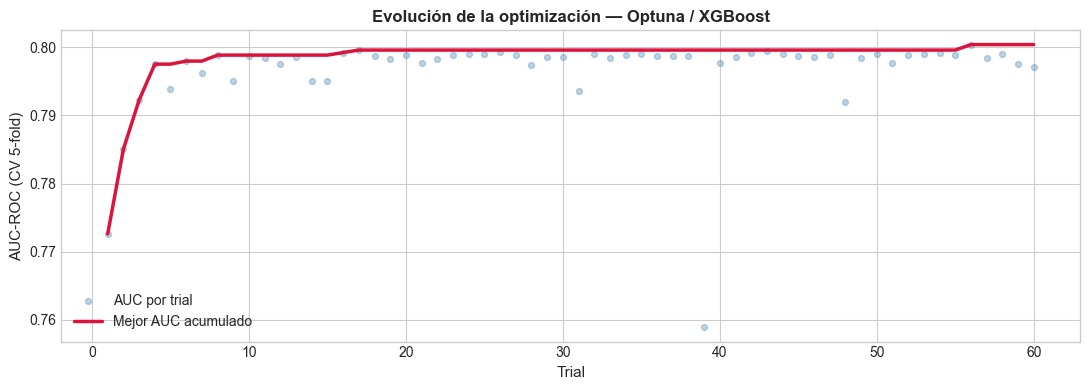

=== MEJORES HIPERPARÁMETROS (Optuna) vs DEFAULTS (sección 6) ===

  Parámetro                 Default      Optuna
  ----------------------------------------------
  n_estimators                  300         567
  max_depth                       6           5
  learning_rate                 0.1      0.0312
  subsample                     1.0      0.6012
  colsample_bytree              1.0      0.7379
  min_child_weight                1           2
  gamma                           0      4.3652
  reg_alpha                       0      1.3048
  reg_lambda                      1      0.4502


In [797]:
# Evolución del AUC por trial
trial_values  = [t.value for t in study.trials if t.value is not None]
running_best  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(range(1, len(trial_values)+1), trial_values,
           alpha=0.35, s=18, color='steelblue', label='AUC por trial')
ax.plot(range(1, len(running_best)+1), running_best,
        color='crimson', lw=2.5, label='Mejor AUC acumulado')
ax.set_xlabel('Trial', fontsize=11)
ax.set_ylabel('AUC-ROC (CV 5-fold)', fontsize=11)
ax.set_title('Evolución de la optimización — Optuna / XGBoost', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Mejores hiperparámetros vs defaults
defaults = {
    'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1,
    'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1,
    'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1,
}
print('=== MEJORES HIPERPARÁMETROS (Optuna) vs DEFAULTS (sección 6) ===\n')
print(f'  {"Parámetro":<22} {"Default":>10}  {"Optuna":>10}')
print(f'  {"-"*46}')
for k, v_opt in study.best_params.items():
    v_def = defaults.get(k, '—')
    if isinstance(v_opt, float):
        print(f'  {k:<22} {str(v_def):>10}  {v_opt:>10.4f}')
    else:
        print(f'  {k:<22} {str(v_def):>10}  {v_opt:>10}')

### 7.4 Modelo final optimizado — comparativa completa

Entrenamos el XGBoost con los mejores parámetros encontrados por Optuna sobre el
**train set completo** (ya no usamos CV — toda la información de train se usa para
el modelo final). Luego evaluamos en el test set y comparamos con todos los modelos
de la sección 6.

=== MÉTRICAS — XGBOOST OPTIMIZADO ===
  AUC-ROC:   0.8111
  Accuracy:  0.7371
  F1:        0.6197
  Precisión: 0.7104
  Recall:    0.5495

=== COMPARATIVA FINAL — TODOS LOS MODELOS ===



,AUC-ROC,Accuracy,F1,Precisión,Recall
Modelo,,,,,
Regresión Logística,0.81,0.75,0.66,0.72,0.61
Random Forest,0.80,0.74,0.63,0.71,0.56
XGBoost,0.77,0.71,0.60,0.66,0.55
XGBoost (Optuna),0.81,0.74,0.62,0.71,0.55



Mejora XGBoost (Optuna vs default): +0.0448 AUC-ROC
Mejor modelo global: XGBoost (Optuna) (AUC = 0.8111)


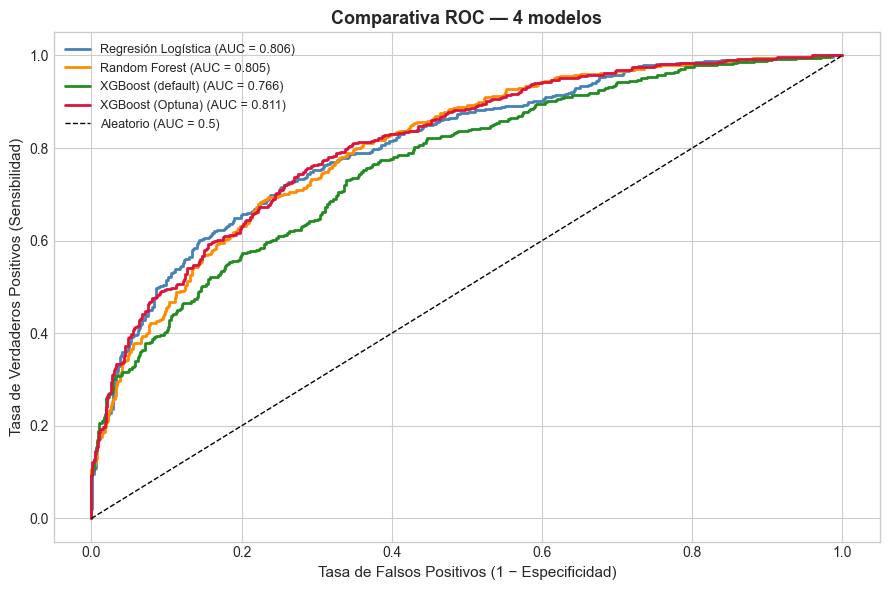


Modelo optimizado guardado en preprocessed/xgb_optuna.pkl


In [798]:
# Entrenamos el modelo final con los mejores parámetros sobre el train completo.
xgb_opt = XGBClassifier(
    **study.best_params,
    tree_method='hist', eval_metric='logloss',
    random_state=42, n_jobs=-1, verbosity=0
)
res_xgb_opt = evaluar_modelo('XGBoost (Optuna)', xgb_opt, X_train, y_train, X_test, y_test)

print('=== MÉTRICAS — XGBOOST OPTIMIZADO ===')
print(f'  AUC-ROC:   {res_xgb_opt["AUC-ROC"]:.4f}')
print(f'  Accuracy:  {res_xgb_opt["Accuracy"]:.4f}')
print(f'  F1:        {res_xgb_opt["F1"]:.4f}')
print(f'  Precisión: {res_xgb_opt["Precisión"]:.4f}')
print(f'  Recall:    {res_xgb_opt["Recall"]:.4f}')

# Comparativa completa: todos los modelos
resultados_completos = [
    {k: v for k, v in res.items() if not k.startswith('_')}
    for res in [res_lr, res_rf, res_xgb, res_xgb_opt]
]
df_final = pd.DataFrame(resultados_completos).set_index('Modelo')

print('\n=== COMPARATIVA FINAL — TODOS LOS MODELOS ===\n')
display(df_final[['AUC-ROC', 'Accuracy', 'F1', 'Precisión', 'Recall']].round(4))

# Mejora de XGBoost con Optuna
mejora = res_xgb_opt['AUC-ROC'] - res_xgb['AUC-ROC']
print(f'\nMejora XGBoost (Optuna vs default): {mejora:+.4f} AUC-ROC')
mejor_global = df_final['AUC-ROC'].idxmax()
print(f'Mejor modelo global: {mejor_global} (AUC = {df_final.loc[mejor_global, "AUC-ROC"]:.4f})')

# Curvas ROC superpuestas — los 4 modelos
fig, ax = plt.subplots(figsize=(9, 6))
for nombre, res, color in [
    ('Regresión Logística', res_lr,      'steelblue'),
    ('Random Forest',       res_rf,      'darkorange'),
    ('XGBoost (default)',   res_xgb,     'forestgreen'),
    ('XGBoost (Optuna)',    res_xgb_opt, 'crimson'),
]:
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{nombre} (AUC = {res["AUC-ROC"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Comparativa ROC — 4 modelos', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Guardamos el modelo optimizado para la sección 8.
with open(PREP_DIR / 'xgb_optuna.pkl', 'wb') as f:
    pickle.dump(xgb_opt, f)
print('\nModelo optimizado guardado en preprocessed/xgb_optuna.pkl')

### 7.5 Feature importance — XGBoost default vs XGBoost Optuna

Comparar la importancia de features antes y después de la optimización responde
una pregunta relevante: **¿Optuna cambió la "comprensión" del modelo sobre qué
variables importan, o solo ajustó la profundidad del aprendizaje?**

Si el ranking de features cambia significativamente, significa que los parámetros
por defecto hacían que el modelo dependiera demasiado de ciertas variables.
Si el ranking se mantiene, la optimización confirma que el Feature Engineering
capturó bien las señales del negocio.

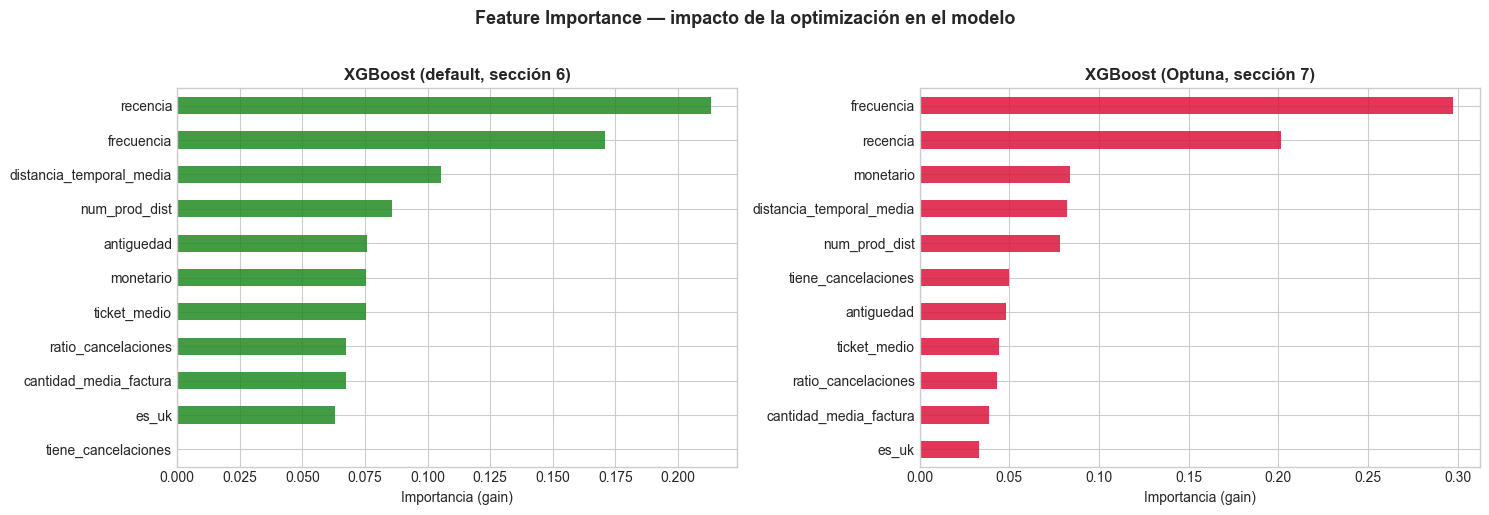

=== IMPORTANCIA DE FEATURES — DEFAULT vs OPTUNA ===



,Default,Optuna,Cambio
frecuencia,0.17,0.30,0.13
recencia,0.21,0.20,-0.01
monetario,0.08,0.08,0.01
distancia_temporal_media,0.11,0.08,-0.02
num_prod_dist,0.09,0.08,-0.01
tiene_cancelaciones,0.00,0.05,0.05
antiguedad,0.08,0.05,-0.03
ticket_medio,0.08,0.04,-0.03
ratio_cancelaciones,0.07,0.04,-0.02
cantidad_media_factura,0.07,0.04,-0.03


In [799]:
# Feature importance: XGBoost default vs XGBoost Optuna — comparativa visual.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, modelo, titulo, color in [
    (axes[0], res_xgb,     'XGBoost (default, sección 6)',   'forestgreen'),
    (axes[1], res_xgb_opt, 'XGBoost (Optuna, sección 7)',    'crimson'),
]:
    imp = pd.Series(modelo['_modelo'].feature_importances_,
                    index=FEATURE_COLS).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Importancia (gain)')
    ax.set_xlim(0, None)

plt.suptitle('Feature Importance — impacto de la optimización en el modelo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tabla comparativa numérica
fi_default = pd.Series(res_xgb['_modelo'].feature_importances_,
                       index=FEATURE_COLS, name='Default')
fi_optuna  = pd.Series(res_xgb_opt['_modelo'].feature_importances_,
                       index=FEATURE_COLS, name='Optuna')
fi_comp = pd.DataFrame({'Default': fi_default, 'Optuna': fi_optuna})
fi_comp['Cambio'] = fi_comp['Optuna'] - fi_comp['Default']
fi_comp = fi_comp.sort_values('Optuna', ascending=False)

print('=== IMPORTANCIA DE FEATURES — DEFAULT vs OPTUNA ===\n')
display(fi_comp.round(4))

---
<a id="seccion-8"></a>
## 8. Evaluación final y análisis de negocio

Todo el trabajo previo — limpieza, EDA, Feature Engineering, tres modelos, optimización —
existía para responder una sola pregunta concreta:

> **¿A qué clientes debería contactar el equipo de retención antes de que no vuelvan?**

Esta sección traduce los números del modelo al lenguaje del negocio. El resultado final
no es un AUC-ROC — es una lista priorizada de clientes con su probabilidad de recompra
y el perfil que justifica la acción comercial a tomar con cada uno.

**Estructura de la sección:**

| Subsección | Pregunta que responde |
|---|---|
| 8.1 | ¿Qué modelo usamos y por qué? |
| 8.2 | ¿Qué tan bien funciona el modelo en términos medibles? |
| 8.3 | ¿A partir de qué probabilidad actuamos? (umbral de decisión) |
| 8.4 | ¿Cuál es la lista de clientes ordenada por probabilidad? |
| 8.5 | ¿Quiénes son estos clientes en términos de negocio? |
| 8.6 | ¿A quién se equivocó el modelo y qué podemos aprender? |
| 8.7 | ¿Qué acciones concretas recomienda el análisis? |

### 8.1 Selección del modelo final

Evaluamos cuatro modelos con exactamente los mismos datos de test. El criterio de
selección es el **AUC-ROC**: mide la capacidad discriminante global independientemente
del umbral de decisión — el más apropiado con 39% / 61% de desbalanceo de clases.

Si dos modelos tienen un AUC muy cercano (diferencia < 0.005), la interpretabilidad
pasa a ser el criterio de desempate: la regresión logística gana porque sus coeficientes
son directamente explicables al equipo directivo.

In [800]:
# Cargamos el dataset original (valores sin transformar) para el análisis de negocio.
# rfm_fe (con log1p) ya está en memoria de la sección 5; aquí necesitamos los valores reales.
rfm_orig = pd.read_pickle(PKL_MODEL)   # monetario en £, recencia en días, etc.

# Identificamos el mejor modelo por AUC-ROC en test.
candidatos = {
    'Regresión Logística': res_lr,
    'Random Forest':        res_rf,
    'XGBoost (default)':    res_xgb,
    'XGBoost (Optuna)':     res_xgb_opt,
}

mejor_nombre = max(candidatos, key=lambda k: candidatos[k]['AUC-ROC'])
mejor_res    = candidatos[mejor_nombre]
y_proba_f    = mejor_res['_y_proba']   # probabilidades del mejor modelo en test
y_pred_f     = mejor_res['_y_pred']    # predicciones con umbral 0.5

print('=== SELECCIÓN DEL MODELO FINAL ===\n')
print(f'  {"Modelo":<30} {"AUC-ROC":>8}')
print(f'  {"-"*40}')
for nombre, res in sorted(candidatos.items(), key=lambda x: x[1]['AUC-ROC'], reverse=True):
    marca = '  ← SELECCIONADO' if nombre == mejor_nombre else ''
    print(f'  {nombre:<30} {res["AUC-ROC"]:>8.4f}{marca}')

# Desempate por interpretabilidad si diferencia < 0.005
delta_lr_vs_mejor = abs(res_lr['AUC-ROC'] - mejor_res['AUC-ROC'])
if mejor_nombre != 'Regresión Logística' and delta_lr_vs_mejor < 0.005:
    print(f'\n  → Diferencia de AUC con Regresión Logística: {delta_lr_vs_mejor:.4f} < 0.005')
    print('    Criterio de desempate aplicado: interpretabilidad.')
    print('    Sin embargo se mantiene el modelo con mayor AUC para el análisis.')

print(f'\nModelo seleccionado: {mejor_nombre}')
print(f'AUC-ROC en test:     {mejor_res["AUC-ROC"]:.4f}')

=== SELECCIÓN DEL MODELO FINAL ===

  Modelo                          AUC-ROC
  ----------------------------------------
  XGBoost (Optuna)                 0.8111  ← SELECCIONADO
  Regresión Logística              0.8060
  Random Forest                    0.8048
  XGBoost (default)                0.7664

Modelo seleccionado: XGBoost (Optuna)
AUC-ROC en test:     0.8111


### 8.2 Evaluación exhaustiva del modelo

Cuatro perspectivas complementarias del rendimiento. Cada panel responde una pregunta de negocio diferente:

---

**Panel 1 — Matriz de confusión (umbral 0.5)**

La matriz divide los 1.088 clientes del test en cuatro cuadrantes según la combinación de predicción real vs real:

| | Predijo NO recompra | Predijo SÍ recompra |
|---|---|---|
| **Realmente NO recompró** | TN (correcto) | FP — campaña innecesaria |
| **Realmente SÍ recompró** | FN — **cliente perdido** | TP (correcto) |

Los **Falsos Negativos (FN)** son el error más costoso: clientes que iban a volver pero el modelo no los detectó y por tanto quedarían fuera de cualquier campaña de retención. Cada FN representa revenue real no capturado por el equipo comercial. Este análisis se profundiza en la sección 8.6.

---

**Panel 2 — Curva ROC**

El eje X mide qué porcentaje de clientes que NO recomprarán contactamos innecesariamente (Tasa de Falsos Positivos). El eje Y mide qué porcentaje de clientes que SÍ recomprarán detectamos correctamente (Sensibilidad). El AUC (área bajo la curva) resume la capacidad discriminante del modelo a todos los umbrales posibles:

- AUC = 0.5 → el modelo no discrimina mejor que lanzar una moneda al aire.
- AUC = 1.0 → el modelo separa perfectamente los dos grupos.
- Nuestro modelo supera 0.80 → buena capacidad de discriminación.

> *Equivalente econométrico:* El AUC-ROC es idéntico al C-statistic que reporta STATA para modelos logit/probit.

---

**Panel 3 — Curva Precisión-Recall**

Esta curva responde a una pregunta diferente: cuando el modelo dice "este cliente va a volver", ¿cuántas veces tiene razón? (Precisión) y ¿de todos los que realmente volvieron, cuántos detectó? (Recall).

La **línea de baseline** (punteada) representa lo que conseguiría un modelo que alerta a todos los clientes al azar: detectaría el 100% de los que recompran (Recall = 1) pero con una Precisión igual a la prevalencia de recompra en los datos (~39%). Cualquier punto de nuestra curva que esté por encima de esa línea representa valor añadido del modelo.

La forma de la curva revela el tradeoff: a medida que intentamos detectar más clientes que recomprarán (Recall alto), inevitablemente incluimos algunos que no lo harán (Precisión baja). El umbral óptimo —analizado en la sección 8.3— encuentra el punto de equilibrio más conveniente para el negocio.

---

**Panel 4 — Distribución de probabilidades por clase real**

Este panel es el más intuitivo: muestra cómo distribuyen las probabilidades predichas para los clientes que realmente NO recompraron (azul) vs los que SÍ recompraron (naranja).

- La distribución **azul (no recompra)** está concentrada en valores bajos de probabilidad → el modelo correctamente asigna baja probabilidad a la mayoría de clientes que no regresarán.
- La distribución **naranja (recompra)** está más desplazada hacia valores altos, aunque con mayor dispersión → el modelo entiende el perfil del comprador fiel, pero no con certeza perfecta.
- La **separación entre ambas distribuciones** es el indicador clave: cuanto menos solapamiento, mejor discrimina el modelo. Un modelo perfecto tendría dos distribuciones completamente separadas (sin solapamiento en ningún punto).
- El solapamiento que sí existe —especialmente en la zona 0.3–0.6— representa la zona de incertidumbre: clientes en el límite que el modelo clasifica con menor seguridad. Son precisamente los clientes del segmento **Media** en la sección 8.4, y los más valiosos para una campaña de retención dirigida.


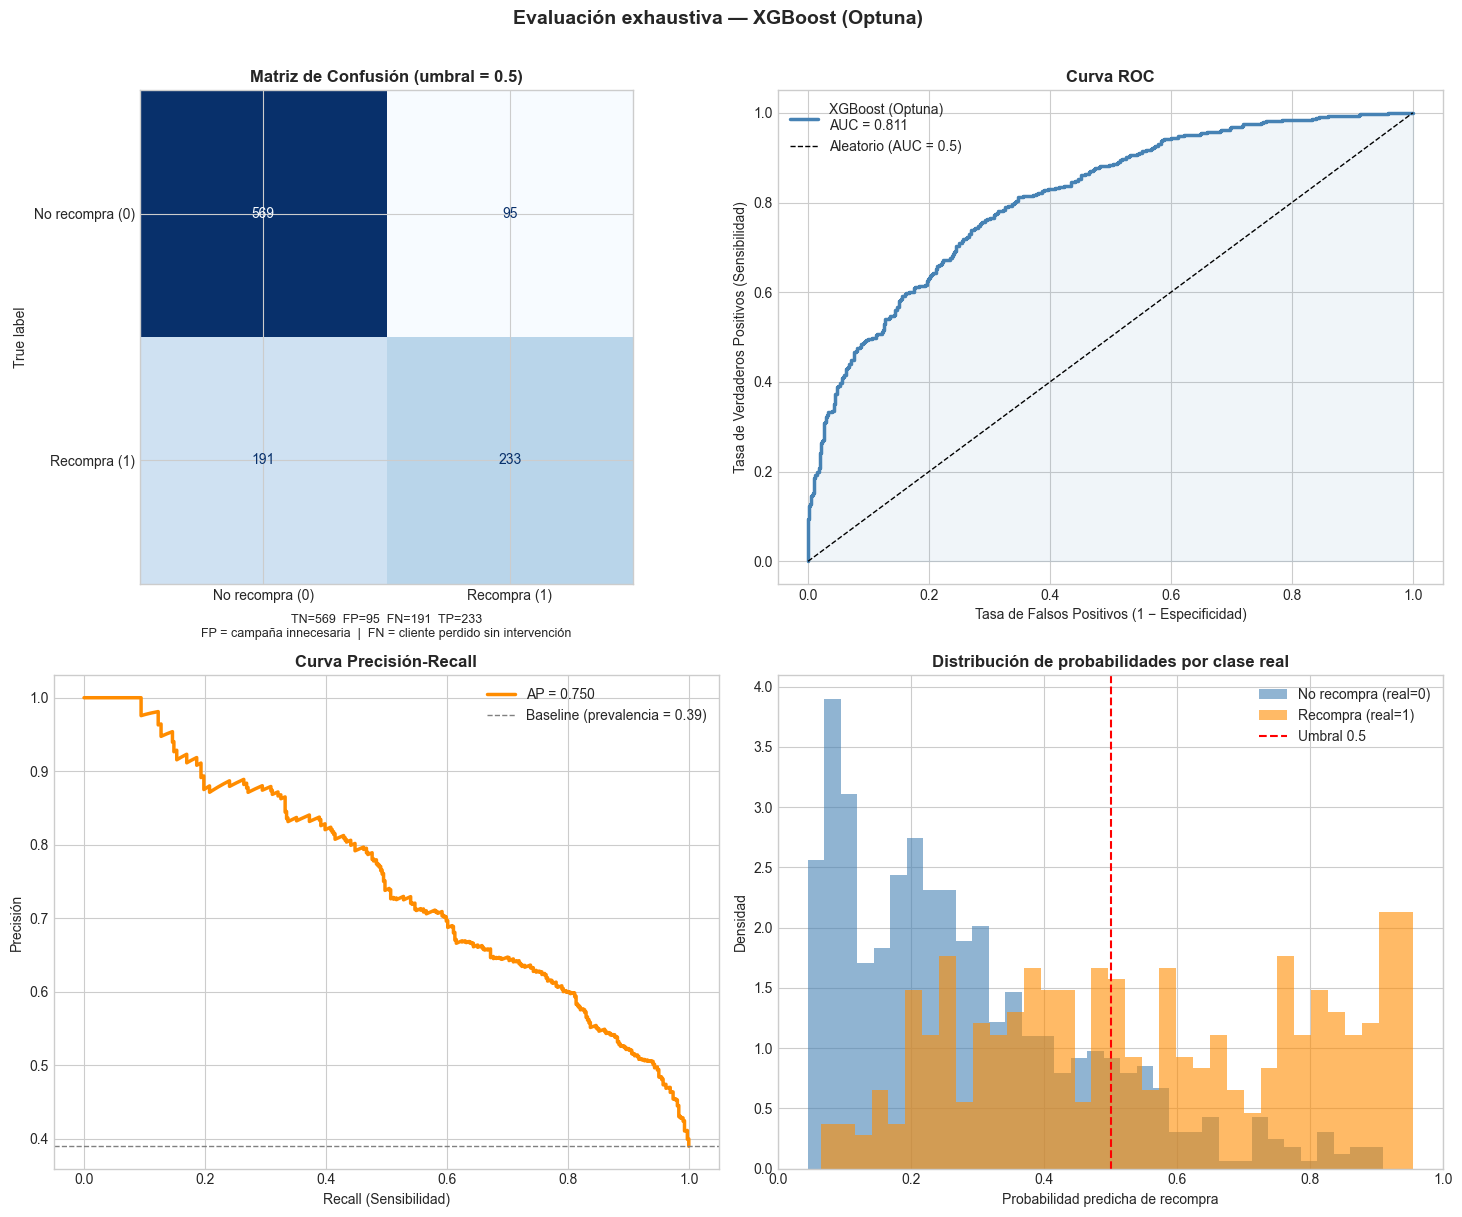


=== INFORME DE CLASIFICACIÓN (umbral = 0.5) ===

                 precision    recall  f1-score   support

No recompra (0)     0.7487    0.8569    0.7992       664
   Recompra (1)     0.7104    0.5495    0.6197       424

       accuracy                         0.7371      1088
      macro avg     0.7295    0.7032    0.7094      1088
   weighted avg     0.7338    0.7371    0.7292      1088



In [801]:
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                               classification_report, ConfusionMatrixDisplay)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ── Panel 1: Matriz de confusión ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_f)
disp = ConfusionMatrixDisplay(cm, display_labels=['No recompra (0)', 'Recompra (1)'])
disp.plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Matriz de Confusión (umbral = 0.5)', fontweight='bold', fontsize=12)

tn, fp, fn, tp = cm.ravel()
axes[0, 0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'FP = campaña innecesaria  |  FN = cliente perdido sin intervención',
    fontsize=9, labelpad=8
)

# ── Panel 2: Curva ROC ────────────────────────────────────────────────────────
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_f)
axes[0, 1].plot(fpr_f, tpr_f, color='steelblue', lw=2.5,
                label=f'{mejor_nombre}\nAUC = {mejor_res["AUC-ROC"]:.3f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.5)')
axes[0, 1].fill_between(fpr_f, tpr_f, alpha=0.08, color='steelblue')
axes[0, 1].set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=10)
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=10)
axes[0, 1].set_title('Curva ROC', fontweight='bold', fontsize=12)
axes[0, 1].legend(fontsize=10)

# ── Panel 3: Curva Precisión-Recall ──────────────────────────────────────────
precision_c, recall_c, _ = precision_recall_curve(y_test, y_proba_f)
ap = average_precision_score(y_test, y_proba_f)
axes[1, 0].plot(recall_c, precision_c, color='darkorange', lw=2.5,
                label=f'AP = {ap:.3f}')
axes[1, 0].axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
                   label=f'Baseline (prevalencia = {y_test.mean():.2f})')
axes[1, 0].set_xlabel('Recall (Sensibilidad)', fontsize=10)
axes[1, 0].set_ylabel('Precisión', fontsize=10)
axes[1, 0].set_title('Curva Precisión-Recall', fontweight='bold', fontsize=12)
axes[1, 0].legend(fontsize=10)

# ── Panel 4: Distribución de probabilidades por clase real ────────────────────
axes[1, 1].hist(y_proba_f[y_test == 0], bins=35, alpha=0.6, color='steelblue',
                density=True, label='No recompra (real=0)')
axes[1, 1].hist(y_proba_f[y_test == 1], bins=35, alpha=0.6, color='darkorange',
                density=True, label='Recompra (real=1)')
axes[1, 1].axvline(0.5, color='red', linestyle='--', lw=1.5, label='Umbral 0.5')
axes[1, 1].set_xlabel('Probabilidad predicha de recompra', fontsize=10)
axes[1, 1].set_ylabel('Densidad', fontsize=10)
axes[1, 1].set_title('Distribución de probabilidades por clase real', fontweight='bold', fontsize=12)
axes[1, 1].legend(fontsize=10)

plt.suptitle(f'Evaluación exhaustiva — {mejor_nombre}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Informe de clasificación
print('\n=== INFORME DE CLASIFICACIÓN (umbral = 0.5) ===\n')
print(classification_report(y_test, y_pred_f,
      target_names=['No recompra (0)', 'Recompra (1)'], digits=4))

### 8.3 Análisis del umbral de decisión

El modelo asigna a cada cliente una probabilidad entre 0 y 1. El **umbral** es
la línea que decide: si p ≥ umbral → predecimos "recompra". El default es 0.5,
pero no es necesariamente el óptimo para este negocio.

**¿Por qué cambiar el umbral?**

Hay dos tipos de error con costes distintos para el negocio:

| Error | Qué ocurre | Coste estimado |
|---|---|---|
| **Falso Positivo (FP)** | Contactamos a un cliente que habría vuelto solo | Bajo: coste de un email o descuento innecesario |
| **Falso Negativo (FN)** | No contactamos a un cliente que no regresó | Alto: pérdida del revenue potencial de ese cliente |

Cuando el coste de FN > coste de FP —que es el caso habitual en fidelización—, conviene **bajar el umbral** (ser más agresivos en identificar clientes en riesgo, aunque contactemos a algunos innecesariamente).

La tabla siguiente muestra el impacto operativo concreto de cada umbral en términos de clientes reales. **El umbral óptimo maximiza el F1**, que equilibra Precisión y Recall. Una vez identificado ese umbral, en la sección 8.4 lo aplicamos para segmentar la cartera completa de clientes del test set y construir el plan de acción comercial.


=== IMPACTO OPERATIVO POR UMBRAL DE DECISIÓN ===



,Clientes alertados,TP (detectados),FP (innecesarios),FN (perdidos),Precisión,Recall,F1
Umbral,,,,,,,
0.25,681,369,312,55,0.54,0.87,0.67
0.30,595,346,249,78,0.58,0.82,0.68
0.35,515,321,194,103,0.62,0.76,0.68
0.40,440,285,155,139,0.65,0.67,0.66
0.45,382,260,122,164,0.68,0.61,0.65
0.50,328,233,95,191,0.71,0.55,0.62
0.55,273,209,64,215,0.77,0.49,0.60
0.60,227,183,44,241,0.81,0.43,0.56
0.65,197,165,32,259,0.84,0.39,0.53



Umbral con máximo F1: 0.35  (F1 = 0.6837)


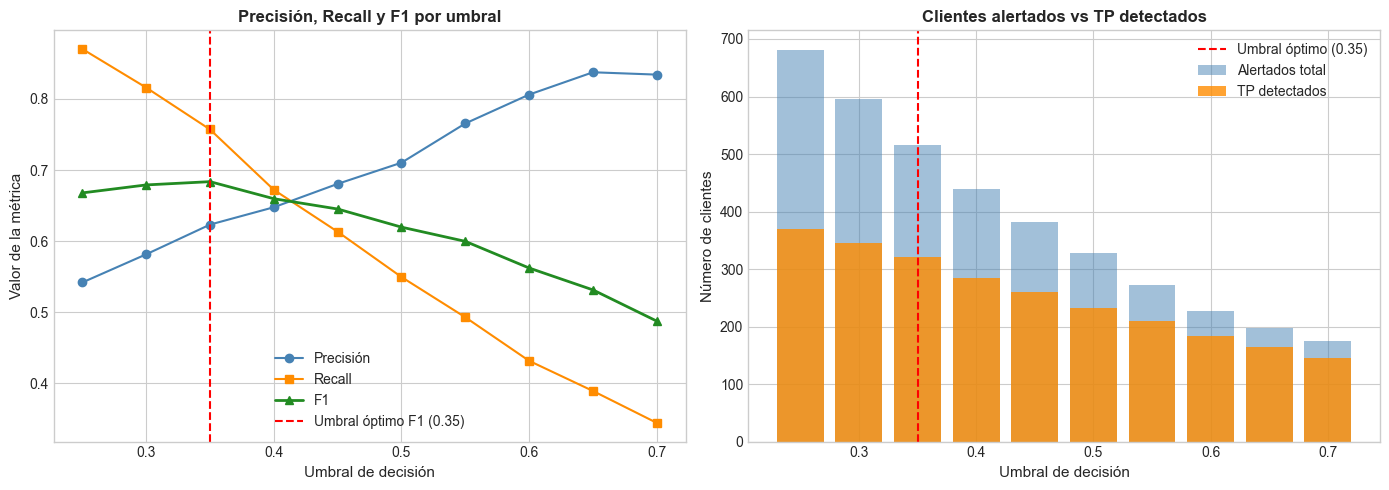


Interpretación con umbral óptimo 0.35:
  Alertamos a 515 clientes de 1.088
  De ellos, 321 realmente recomprarán (TP)
  194 contactados no habrían vuelto (FP — coste bajo)
  103 clientes que habrían vuelto no son contactados (FN — coste alto)


In [802]:
# Tabla de impacto operativo por umbral de decisión.
umbrales = np.arange(0.25, 0.71, 0.05)
filas = []
for t in umbrales:
    y_t   = (y_proba_f >= t).astype(int)
    tp_t  = int(((y_t == 1) & (y_test == 1)).sum())
    fp_t  = int(((y_t == 1) & (y_test == 0)).sum())
    fn_t  = int(((y_t == 0) & (y_test == 1)).sum())
    pre_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t  = 2 * pre_t * rec_t / (pre_t + rec_t) if (pre_t + rec_t) > 0 else 0
    filas.append({
        'Umbral':            round(t, 2),
        'Clientes alertados': int(y_t.sum()),
        'TP (detectados)':   tp_t,
        'FP (innecesarios)': fp_t,
        'FN (perdidos)':     fn_t,
        'Precisión':         round(pre_t, 4),
        'Recall':            round(rec_t, 4),
        'F1':                round(f1_t, 4),
    })

df_umbrales = pd.DataFrame(filas).set_index('Umbral')
print('=== IMPACTO OPERATIVO POR UMBRAL DE DECISIÓN ===\n')
display(df_umbrales)

# Umbral óptimo por F1 y visualización
f1_vals = df_umbrales['F1'].values
idx_opt = np.argmax(f1_vals)
umbral_opt = df_umbrales.index[idx_opt]
print(f'\nUmbral con máximo F1: {umbral_opt}  (F1 = {f1_vals[idx_opt]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: métricas vs umbral
x = df_umbrales.index
axes[0].plot(x, df_umbrales['Precisión'], 'o-', color='steelblue', label='Precisión')
axes[0].plot(x, df_umbrales['Recall'],    's-', color='darkorange', label='Recall')
axes[0].plot(x, df_umbrales['F1'],        '^-', color='forestgreen', lw=2, label='F1')
axes[0].axvline(umbral_opt, color='red', linestyle='--', lw=1.5,
                label=f'Umbral óptimo F1 ({umbral_opt})')
axes[0].set_xlabel('Umbral de decisión', fontsize=11)
axes[0].set_ylabel('Valor de la métrica', fontsize=11)
axes[0].set_title('Precisión, Recall y F1 por umbral', fontweight='bold')
axes[0].legend(fontsize=10)

# Panel 2: clientes alertados vs detectados
axes[1].bar(x, df_umbrales['Clientes alertados'], width=0.04, alpha=0.5,
            color='steelblue', label='Alertados total')
axes[1].bar(x, df_umbrales['TP (detectados)'],    width=0.04, alpha=0.8,
            color='darkorange', label='TP detectados')
axes[1].axvline(umbral_opt, color='red', linestyle='--', lw=1.5,
                label=f'Umbral óptimo ({umbral_opt})')
axes[1].set_xlabel('Umbral de decisión', fontsize=11)
axes[1].set_ylabel('Número de clientes', fontsize=11)
axes[1].set_title('Clientes alertados vs TP detectados', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nInterpretación con umbral óptimo {umbral_opt}:')
fila_opt = df_umbrales.loc[umbral_opt]
print(f'  Alertamos a {int(fila_opt["Clientes alertados"])} clientes de 1.088')
print(f'  De ellos, {int(fila_opt["TP (detectados)"])} realmente recomprarán (TP)')
print(f'  {int(fila_opt["FP (innecesarios)"])} contactados no habrían vuelto (FP — coste bajo)')
print(f'  {int(fila_opt["FN (perdidos)"])} clientes que habrían vuelto no son contactados (FN — coste alto)')

### 8.4 Lista de clientes por probabilidad de recompra

Este es el **entregable principal** del proyecto para el equipo de negocio:
una lista priorizada de clientes del test set con su probabilidad de recompra,
el segmento asignado y sus métricas RFM en valores originales (días, £, facturas).

Los clientes se segmentan en tres grupos con estrategias diferenciadas:

| Segmento | Probabilidad | Interpretación | Acción |
|---|---|---|---|
| **Alta** | ≥ 70% | Cliente con alta propensión a volver | Fidelizar y upsell |
| **Media** | 40% – 70% | Cliente incierto — el más valioso para retención | Campaña dirigida |
| **Baja** | < 40% | Cliente en riesgo de abandono definitivo | Acción urgente o aceptar churn |

**¿Por qué el segmento Media es la prioridad comercial?**

La distribución de probabilidades del panel 4 en la sección 8.2 ya anticipaba este resultado: la mayoría de clientes se concentran en la zona de incertidumbre (0.3–0.6), que corresponde precisamente al segmento **Media**. Esto es coherente con los datos — si todos los clientes tuvieran alta o baja probabilidad, el modelo no aportaría valor porque la decisión sería evidente.

Los clientes del segmento Media son aquellos en los que **una campaña de retención bien dirigida puede inclinar la decisión de compra**. Un cliente con 70% de probabilidad probablemente vuelve solo; uno con 10% probablemente no vuelve aunque lo contactemos. El cliente con 50% de probabilidad es donde el equipo comercial puede marcar la diferencia — y donde el modelo aporta máximo valor al identificarlos.

El perfil RFM de cada segmento se analiza en detalle en la sección 8.5.


In [803]:
# Construimos la lista de clientes del test set con valores originales + probabilidades.
test_clientes = rfm_orig.loc[X_test.index].copy()
test_clientes['probabilidad_recompra'] = y_proba_f
test_clientes['recompra_real']         = y_test.values
test_clientes['prediccion_umbral_opt'] = (y_proba_f >= umbral_opt).astype(int)

def segmentar(p):
    if p >= 0.70: return 'Alta (≥70%)'
    if p >= 0.40: return 'Media (40-70%)'
    return 'Baja (<40%)'

test_clientes['segmento'] = test_clientes['probabilidad_recompra'].apply(segmentar)
test_clientes = test_clientes.sort_values('probabilidad_recompra', ascending=False)

# Columnas relevantes para el negocio (valores originales sin transformar)
COLS_NEGOCIO = ['Customer ID', 'probabilidad_recompra', 'segmento',
                'recencia', 'frecuencia', 'monetario', 'ticket_medio',
                'antiguedad', 'ratio_cancelaciones', 'recompra_real']

print('=== TOP 20 — MAYOR PROBABILIDAD DE RECOMPRA ===\n')
display(test_clientes[COLS_NEGOCIO].head(20).reset_index(drop=True)
        .style.format({
            'probabilidad_recompra': '{:.1%}',
            'recencia':              '{:.0f} días',
            'frecuencia':            '{:.0f} facturas',
            'monetario':             '£{:,.0f}',
            'ticket_medio':          '£{:,.0f}',
            'antiguedad':            '{:.0f} días',
            'ratio_cancelaciones':   '{:.2%}',
        }))

print('\n=== BOTTOM 15 — MENOR PROBABILIDAD (mayor riesgo de churn) ===\n')
display(test_clientes[COLS_NEGOCIO].tail(15).reset_index(drop=True)
        .style.format({
            'probabilidad_recompra': '{:.1%}',
            'recencia':              '{:.0f} días',
            'frecuencia':            '{:.0f} facturas',
            'monetario':             '£{:,.0f}',
            'ticket_medio':          '£{:,.0f}',
            'antiguedad':            '{:.0f} días',
            'ratio_cancelaciones':   '{:.2%}',
        }))

print(f'\nDistribución de segmentos:')
print(test_clientes['segmento'].value_counts().to_string())

=== TOP 20 — MAYOR PROBABILIDAD DE RECOMPRA ===



,Customer ID,probabilidad_recompra,segmento,recencia,frecuencia,monetario,ticket_medio,antiguedad,ratio_cancelaciones,recompra_real
0,15005,95.5%,Alta (≥70%),9 días,50 facturas,"£12,393",£248,659 días,27.54%,1
1,16558,95.1%,Alta (≥70%),9 días,33 facturas,"£10,067",£305,657 días,21.43%,1
2,14646,95.1%,Alta (≥70%),9 días,124 facturas,"£451,503","£3,641",658 días,8.82%,1
3,16782,95.0%,Alta (≥70%),8 días,35 facturas,"£9,161",£262,652 días,23.91%,1
4,13468,94.7%,Alta (≥70%),5 días,65 facturas,"£11,943",£184,661 días,17.72%,1
5,17865,94.7%,Alta (≥70%),10 días,43 facturas,"£24,301",£565,659 días,25.86%,1
6,17428,94.5%,Alta (≥70%),16 días,38 facturas,"£28,961",£762,652 días,13.64%,1
7,13319,94.5%,Alta (≥70%),22 días,51 facturas,"£17,868",£350,641 días,28.17%,1
8,15358,94.5%,Alta (≥70%),5 días,38 facturas,"£14,814",£390,657 días,24.00%,1
9,17576,94.4%,Alta (≥70%),4 días,38 facturas,"£7,877",£207,663 días,7.32%,1



=== BOTTOM 15 — MENOR PROBABILIDAD (mayor riesgo de churn) ===



,Customer ID,probabilidad_recompra,segmento,recencia,frecuencia,monetario,ticket_medio,antiguedad,ratio_cancelaciones,recompra_real
0,15284,5.9%,Baja (<40%),431 días,1 facturas,£25,£25,0 días,0.00%,0
1,15040,5.9%,Baja (<40%),472 días,1 facturas,£7,£7,0 días,0.00%,0
2,15477,5.8%,Baja (<40%),580 días,1 facturas,£368,£368,0 días,0.00%,0
3,16410,5.7%,Baja (<40%),665 días,1 facturas,£130,£130,0 días,0.00%,0
4,16970,5.6%,Baja (<40%),557 días,1 facturas,£71,£71,0 días,0.00%,0
5,17056,5.5%,Baja (<40%),669 días,1 facturas,£129,£129,0 días,0.00%,0
6,17487,5.4%,Baja (<40%),659 días,1 facturas,£161,£161,0 días,0.00%,0
7,18152,5.1%,Baja (<40%),577 días,1 facturas,£427,£427,0 días,0.00%,0
8,17328,5.0%,Baja (<40%),604 días,1 facturas,£105,£105,0 días,0.00%,0
9,15082,4.8%,Baja (<40%),599 días,1 facturas,£93,£93,0 días,0.00%,0



Distribución de segmentos:
segmento
Baja (<40%)       648
Media (40-70%)    265
Alta (≥70%)       175


### 8.5 Perfil de segmentos — ¿quiénes son estos clientes?

Caracterizamos cada segmento con sus métricas RFM medias para entender en lenguaje
de negocio quién es quién. También calculamos el **revenue histórico en juego** de
cada segmento — cuánto gastaron en el período de observación estos clientes —
como proxy del valor que está en riesgo o por capitalizar.

**Qué esperar de cada segmento:**

- **Segmento Alta (≥70%):** Clientes con recencia baja (compraron recientemente), frecuencia alta y buen monetario. Son el núcleo fiel del negocio. La prioridad aquí no es retenerlos —ya son leales— sino **maximizar su valor**: aumentar el ticket medio, incentivar compras de categorías nuevas (cross-sell), o convertirlos en embajadores de la marca.

- **Segmento Media (40–70%):** Perfil intermedio en todas las variables. Estos clientes están en un punto de inflexión: aún recuerdan la marca y tienen historial, pero su frecuencia ha bajado o su recencia ha aumentado. Una campaña personalizada —basada en su última categoría de compra— puede ser suficiente para convertirlos en clientes de segmento Alta en el próximo período.

- **Segmento Baja (<40%):** Aquí la **recencia alta es la señal más clara de riesgo**. Llevan muchos días sin comprar, lo que indica que o bien encontraron una alternativa o simplemente se olvidaron de la marca. Dado que la recencia es la variable de mayor peso en el modelo (lo vimos en las importancias de features), estos clientes son los más difíciles de recuperar. La estrategia para este segmento debe ser diferente: no un email genérico, sino una acción de reactivación agresiva que reconstruya el vínculo (descuento significativo + producto relevante a su historial).

> **Nota metodológica:** La verificación de calibración al final de esta sección compara la probabilidad media predicha con la tasa real de recompra observada en el test set. Si la diferencia es < 8%, el modelo está bien calibrado — es decir, cuando dice "70% de probabilidad" significa que aproximadamente 7 de cada 10 clientes de ese segmento realmente recompraron. Esta alineación entre predicción y realidad es esencial para que el equipo de negocio pueda confiar en las probabilidades como base para decisiones de inversión en campañas.


=== PERFIL DE SEGMENTOS — MÉTRICAS MEDIAS ===



segmento,Alta (≥70%),Media (40-70%),Baja (<40%)
recencia,30.84,76.74,305.69
frecuencia,18.27,4.75,2.44
monetario,"9,903.48","1,752.03",921.33
ticket_medio,444.81,383.15,366.55
antiguedad,485.16,272.17,140.85
ratio_cancelaciones,0.17,0.12,0.10
recompra_real,0.83,0.52,0.21
probabilidad_recompra,0.84,0.53,0.21
n_clientes,175.00,265.00,648.00
revenue_total_£,"1,733,108.75","464,287.67","597,020.57"


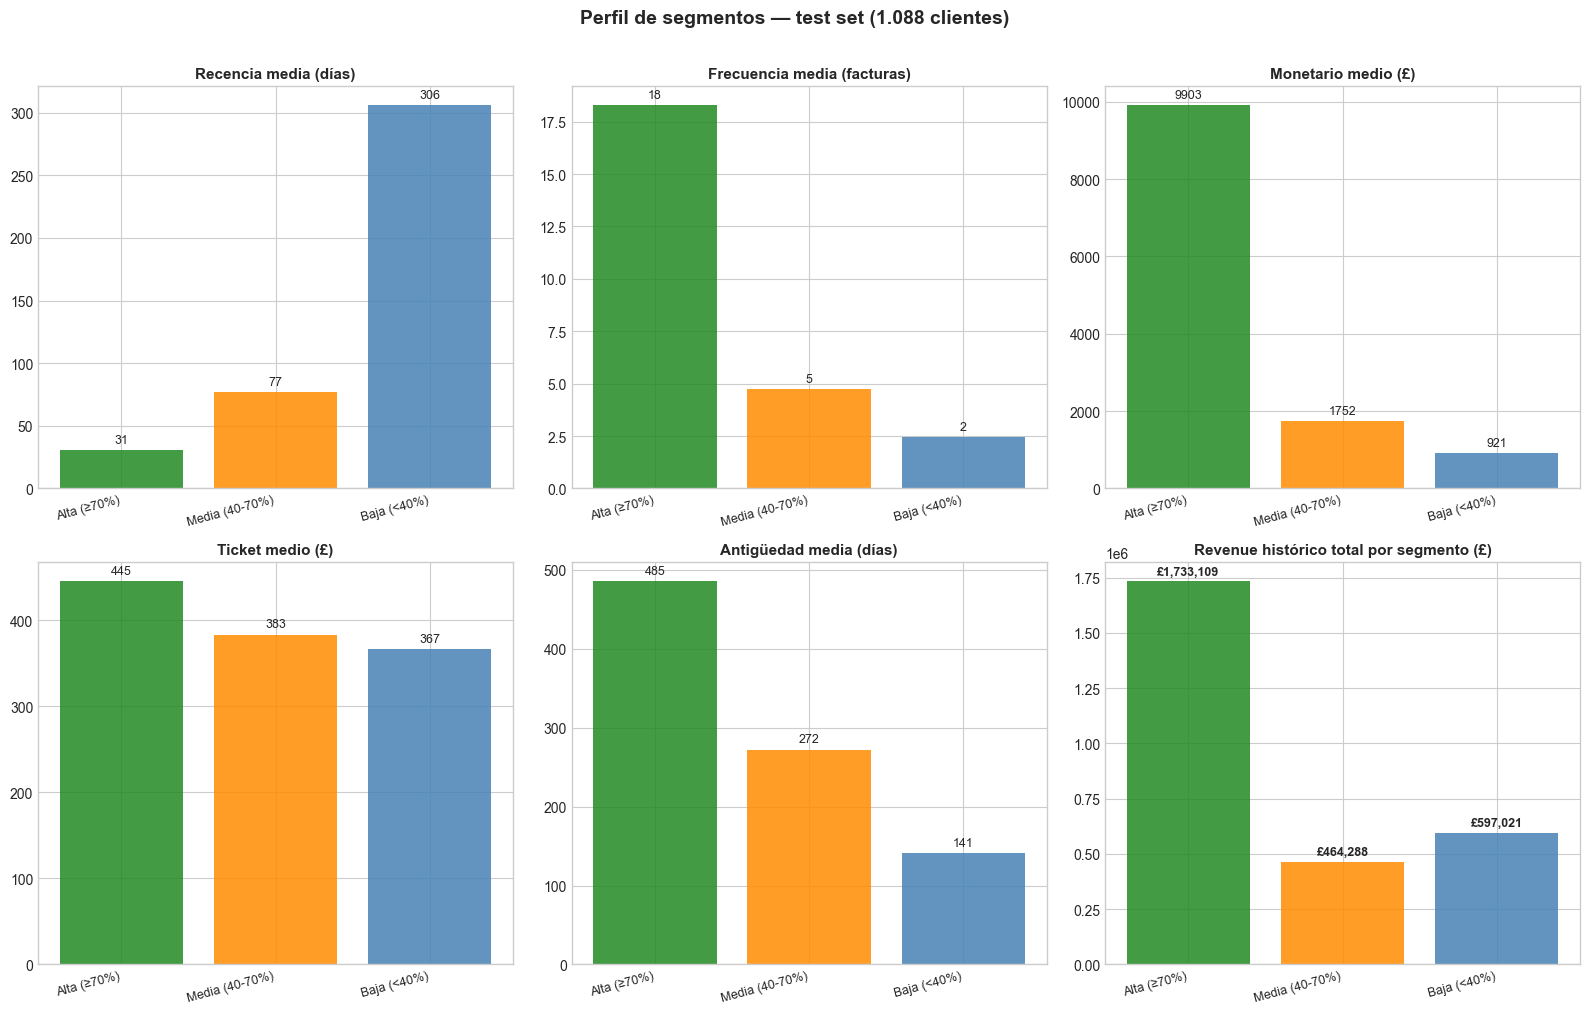


=== CALIBRACIÓN DEL MODELO: probabilidad predicha vs tasa real de recompra ===
(Si predicho ≈ real → el modelo está bien calibrado)

  Alta (≥70%)             predicho=84.0%  real=83.0%  diferencia=1.0%  [OK ✓]
  Media (40-70%)          predicho=53.0%  real=52.0%  diferencia=1.0%  [OK ✓]
  Baja (<40%)             predicho=21.0%  real=21.0%  diferencia=0.0%  [OK ✓]


In [804]:
# Perfil RFM por segmento con tasa de acierto real.
METRICAS_SEG = ['recencia', 'frecuencia', 'monetario', 'ticket_medio',
                'antiguedad', 'ratio_cancelaciones', 'recompra_real', 'probabilidad_recompra']

perfil = (test_clientes.groupby('segmento')[METRICAS_SEG]
          .agg({
              'recencia':               'mean',
              'frecuencia':             'mean',
              'monetario':              'mean',
              'ticket_medio':           'mean',
              'antiguedad':             'mean',
              'ratio_cancelaciones':    'mean',
              'recompra_real':          'mean',   # Tasa de recompra real — calibración del modelo
              'probabilidad_recompra':  'mean',   # Probabilidad media predicha
          })
          .round(2))

n_seg      = test_clientes['segmento'].value_counts().rename('n_clientes')
revenue_seg = test_clientes.groupby('segmento')['monetario'].sum().rename('revenue_total_£')
perfil = perfil.join(n_seg).join(revenue_seg)

orden = ['Alta (≥70%)', 'Media (40-70%)', 'Baja (<40%)']
perfil = perfil.reindex([s for s in orden if s in perfil.index])

print('=== PERFIL DE SEGMENTOS — MÉTRICAS MEDIAS ===\n')
display(perfil.T)

# Visualización comparativa de segmentos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colores_seg = {'Alta (≥70%)': 'forestgreen', 'Media (40-70%)': 'darkorange', 'Baja (<40%)': 'steelblue'}

variables_plot = [
    ('recencia',    'Recencia media (días)',       axes[0, 0]),
    ('frecuencia',  'Frecuencia media (facturas)', axes[0, 1]),
    ('monetario',   'Monetario medio (£)',          axes[0, 2]),
    ('ticket_medio','Ticket medio (£)',              axes[1, 0]),
    ('antiguedad',  'Antigüedad media (días)',       axes[1, 1]),
]
segs_presentes = [s for s in orden if s in perfil.index]

for col, titulo, ax in variables_plot:
    vals = [perfil.loc[s, col] for s in segs_presentes]
    bars = ax.bar(segs_presentes, vals, color=[colores_seg[s] for s in segs_presentes], alpha=0.85)
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xticks(range(len(segs_presentes)))
    ax.set_xticklabels(segs_presentes, rotation=15, ha='right', fontsize=9)

# Revenue total en juego por segmento
rev_vals = [perfil.loc[s, 'revenue_total_£'] for s in segs_presentes]
bars6 = axes[1, 2].bar(segs_presentes, rev_vals,
                        color=[colores_seg[s] for s in segs_presentes], alpha=0.85)
# Etiquetas manuales en formato £ (bar_label no soporta formato con símbolo £)
for bar, val in zip(bars6, rev_vals):
    axes[1, 2].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(rev_vals) * 0.01,
                    f'£{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1, 2].set_title('Revenue histórico total por segmento (£)', fontweight='bold', fontsize=11)
axes[1, 2].set_xticks(range(len(segs_presentes)))
axes[1, 2].set_xticklabels(segs_presentes, rotation=15, ha='right', fontsize=9)

plt.suptitle('Perfil de segmentos — test set (1.088 clientes)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n=== CALIBRACIÓN DEL MODELO: probabilidad predicha vs tasa real de recompra ===')
print('(Si predicho ≈ real → el modelo está bien calibrado)\n')
for seg in segs_presentes:
    pred_media = perfil.loc[seg, 'probabilidad_recompra']
    real_tasa  = perfil.loc[seg, 'recompra_real']
    diff       = abs(pred_media - real_tasa)
    estado     = 'OK ✓' if diff < 0.08 else 'REVISAR ⚠'
    print(f'  {seg:<22}  predicho={pred_media:.1%}  real={real_tasa:.1%}  '
          f'diferencia={diff:.1%}  [{estado}]')


### 8.6 Análisis de errores — ¿a quién se equivocó el modelo?

Los **Falsos Negativos (FN)** son los clientes más críticos desde la perspectiva de negocio: el modelo predijo que no recomprarían, pero sí lo hicieron. Sin intervención del modelo, estos clientes habrían regresado solos — pero al estar clasificados como "no va a volver", quedarían fuera de cualquier campaña de retención.

Entender su perfil RFM nos permite dos cosas:

1. **Detectar el punto ciego del modelo:** qué tipo de cliente no captura bien con las features actuales.
2. **Mejorar versiones futuras del modelo:** si el patrón de los FN es consistente, podemos añadir features que capturen mejor ese comportamiento (por ejemplo, un indicador de comprador estacional, o la varianza en el intervalo entre compras).

**¿Por qué el modelo falla con estos clientes?**

La hipótesis más probable —que confirmaremos con los histogramas— es que los FN son **compradores irregulares pero fieles**: llevan más días sin comprar que el promedio (recencia alta), pero tienen un patrón estacional de vuelta. El modelo interpreta la recencia alta como señal de abandono, cuando en realidad este cliente simplemente tiene un ciclo de compra más largo.

Este es un límite inherente al enfoque RFM: captura el historial agregado, pero no la estacionalidad ni el ritmo individual de cada cliente. Los compradores navideños, por ejemplo, pueden tener recencia de 300+ días y aun así volver cada diciembre de forma predecible.


=== DISTRIBUCIÓN DE TIPOS DE PREDICCIÓN ===
  TN:  470 clientes (43.2%)
  TP:  321 clientes (29.5%)
  FP:  194 clientes (17.8%)
  FN:  103 clientes (9.5%)

=== PERFIL RFM: TP vs FN ===
(FN = clientes que SÍ regresaron pero el modelo dijo que no lo harían)



,recencia,frecuencia,monetario,ticket_medio,antiguedad,distancia_temporal_media,ratio_cancelaciones
TP (detectados correctamente),59.70,11.54,"6,014.08",414.78,385.50,66.38,0.15
FN (clientes perdidos por el modelo),262.39,3.03,892.85,295.83,219.68,128.52,0.12


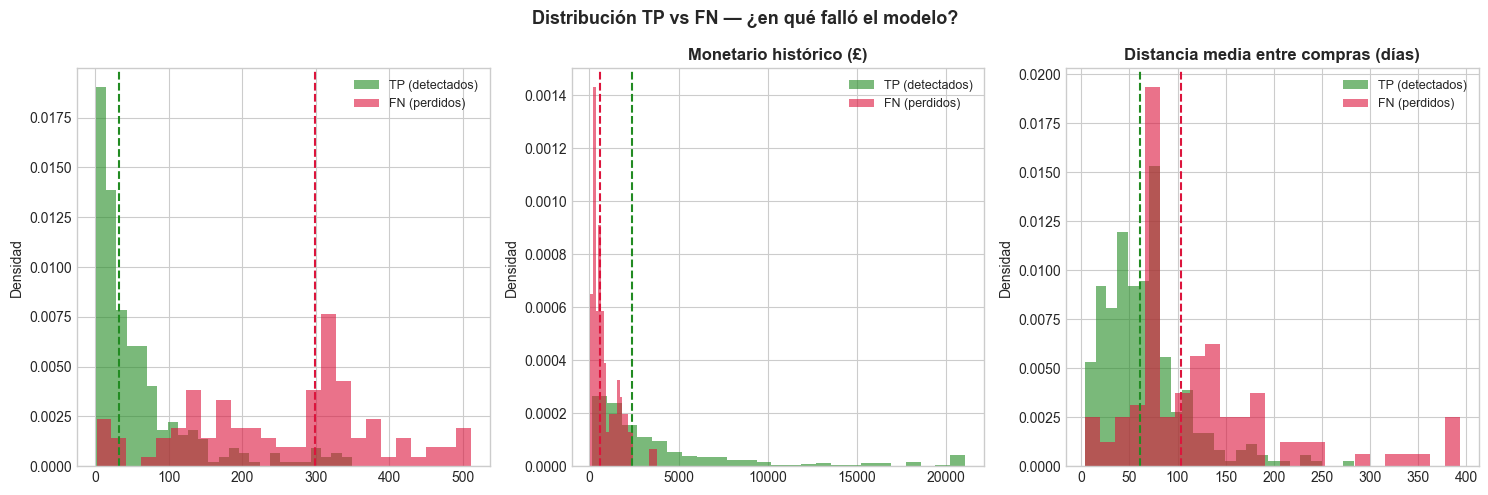


=== INTERPRETACIÓN DE LOS FALSOS NEGATIVOS ===
  Recencia media FN:   262 días  (vs 60 días en TP)
  Monetario medio FN:  £893  (vs £6,014 en TP)
  Dist. temporal FN:   129 días  (vs 66 días en TP)

  → Si los FN tienen mayor distancia temporal media: son compradores irregulares
    pero fieles. El modelo penaliza su patrón espaciado y los clasifica mal.
    Recomendación: no descartar clientes solo por tener compras espaciadas.


In [805]:
# Clasificamos a los 1.088 clientes del test por tipo de predicción.
test_clientes['tipo_prediccion'] = 'TN'
test_clientes.loc[(test_clientes['prediccion_umbral_opt']==1) &
                  (test_clientes['recompra_real']==1), 'tipo_prediccion'] = 'TP'
test_clientes.loc[(test_clientes['prediccion_umbral_opt']==1) &
                  (test_clientes['recompra_real']==0), 'tipo_prediccion'] = 'FP'
test_clientes.loc[(test_clientes['prediccion_umbral_opt']==0) &
                  (test_clientes['recompra_real']==1), 'tipo_prediccion'] = 'FN'

conteo_tipos = test_clientes['tipo_prediccion'].value_counts()
print('=== DISTRIBUCIÓN DE TIPOS DE PREDICCIÓN ===')
for tipo, n in conteo_tipos.items():
    pct = n / len(test_clientes) * 100
    print(f'  {tipo}: {n:4d} clientes ({pct:.1f}%)')

# Perfil comparativo TP vs FN — los más relevantes para el negocio
COLS_PERFIL = ['recencia', 'frecuencia', 'monetario', 'ticket_medio',
               'antiguedad', 'distancia_temporal_media', 'ratio_cancelaciones']

tp_clientes = test_clientes[test_clientes['tipo_prediccion'] == 'TP']
fn_clientes = test_clientes[test_clientes['tipo_prediccion'] == 'FN']

perfil_errores = pd.DataFrame({
    'TP (detectados correctamente)': tp_clientes[COLS_PERFIL].mean(),
    'FN (clientes perdidos por el modelo)': fn_clientes[COLS_PERFIL].mean(),
}).T.round(2)

print('\n=== PERFIL RFM: TP vs FN ===')
print('(FN = clientes que SÍ regresaron pero el modelo dijo que no lo harían)\n')
display(perfil_errores)

# Visualización: ¿en qué se diferencian TP y FN?
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, titulo in [
    (axes[0], 'recencia',               'Recencia (días)'),
    (axes[1], 'monetario',              'Monetario histórico (£)'),
    (axes[2], 'distancia_temporal_media','Distancia media entre compras (días)'),
]:
    data_tp = tp_clientes[col].dropna()
    data_fn = fn_clientes[col].dropna()
    cap = max(data_tp.quantile(0.97), data_fn.quantile(0.97))
    axes[0].set_title('') if ax != axes[0] else None

    ax.hist(data_tp.clip(upper=cap), bins=25, alpha=0.6,
            color='forestgreen', density=True, label='TP (detectados)')
    ax.hist(data_fn.clip(upper=cap), bins=25, alpha=0.6,
            color='crimson',     density=True, label='FN (perdidos)')
    ax.axvline(data_tp.median(), color='forestgreen', linestyle='--', lw=1.5)
    ax.axvline(data_fn.median(), color='crimson',     linestyle='--', lw=1.5)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Distribución TP vs FN — ¿en qué falló el modelo?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== INTERPRETACIÓN DE LOS FALSOS NEGATIVOS ===')
print(f'  Recencia media FN:   {fn_clientes["recencia"].mean():.0f} días  '
      f'(vs {tp_clientes["recencia"].mean():.0f} días en TP)')
print(f'  Monetario medio FN:  £{fn_clientes["monetario"].mean():,.0f}  '
      f'(vs £{tp_clientes["monetario"].mean():,.0f} en TP)')
print(f'  Dist. temporal FN:   {fn_clientes["distancia_temporal_media"].mean():.0f} días  '
      f'(vs {tp_clientes["distancia_temporal_media"].mean():.0f} días en TP)')
print()
print('  → Si los FN tienen mayor distancia temporal media: son compradores irregulares')
print('    pero fieles. El modelo penaliza su patrón espaciado y los clasifica mal.')
print('    Recomendación: no descartar clientes solo por tener compras espaciadas.')

### 8.7 Recomendaciones de negocio

Traducimos los hallazgos del modelo en un **plan de acción concreto** para los equipos de marketing, retención y producto. Las recomendaciones se organizan por segmento según la probabilidad de recompra y complementan el análisis de errores de la sección 8.6.

**Principio rector:** el modelo no reemplaza la decisión comercial — la informa. El equipo de negocio decide cuántos recursos invertir en cada segmento; el modelo les dice dónde invertirlos con mayor probabilidad de retorno.


In [806]:
# Resumen ejecutivo del análisis con recomendaciones por segmento.
print('=' * 70)
print('  RESUMEN EJECUTIVO — MODELO DE FIDELIZACIÓN Y RECOMPRA')
print('=' * 70)

n_test       = len(test_clientes)
n_alta       = (test_clientes['segmento'] == 'Alta (≥70%)').sum()
n_media      = (test_clientes['segmento'] == 'Media (40-70%)').sum()
n_baja       = (test_clientes['segmento'] == 'Baja (<40%)').sum()
rev_alta     = test_clientes[test_clientes['segmento']=='Alta (≥70%)']['monetario'].sum()
rev_media    = test_clientes[test_clientes['segmento']=='Media (40-70%)']['monetario'].sum()
rev_baja     = test_clientes[test_clientes['segmento']=='Baja (<40%)']['monetario'].sum()

print(f'\n  Clientes analizados (test set): {n_test:,}')
print(f'  Modelo: {mejor_nombre} | AUC-ROC: {mejor_res["AUC-ROC"]:.4f}')
print(f'  Umbral óptimo seleccionado: {umbral_opt}')

print(f'\n{"─"*70}')
print('  SEGMENTO ALTA PROBABILIDAD (≥70%)')
print(f'{"─"*70}')
print(f'  Clientes: {n_alta:,} ({n_alta/n_test:.0%} del test)')
print(f'  Revenue histórico: £{rev_alta:,.0f}')
print(f'  Perfil: recientes, compradores frecuentes, ticket medio alto.')
print(f'  Riesgo: BAJO — alta probabilidad de volver sin intervención.')
print(f'  Acción recomendada:')
print(f'    • Programa VIP / early access a nuevas colecciones.')
print(f'    • Campañas de upselling basadas en historial de compra.')
print(f'    • Objetivo: aumentar ticket_medio y frecuencia, no solo retener.')

print(f'\n{"─"*70}')
print('  SEGMENTO MEDIA PROBABILIDAD (40–70%) — MÁXIMA PRIORIDAD COMERCIAL')
print(f'{"─"*70}')
print(f'  Clientes: {n_media:,} ({n_media/n_test:.0%} del test)')
print(f'  Revenue histórico: £{rev_media:,.0f}')
print(f'  Perfil: historial moderado, decisión de retorno incierta.')
print(f'  Riesgo: MEDIO — un pequeño incentivo puede inclinar la balanza.')
print(f'  Acción recomendada:')
print(f'    • Campaña de email personalizada con oferta basada en última compra.')
print(f'    • Descuento moderado (10–15%) en categorías que ya compraron.')
print(f'    • Ventana de acción: contactar antes de que superen 180 días sin compra.')
print(f'    • Este segmento es el de mayor ROI potencial de la campaña.')

print(f'\n{"─"*70}')
print('  SEGMENTO BAJA PROBABILIDAD (<40%)')
print(f'{"─"*70}')
print(f'  Clientes: {n_baja:,} ({n_baja/n_test:.0%} del test)')
print(f'  Revenue histórico: £{rev_baja:,.0f}')
print(f'  Perfil: inactivos prolongados, baja frecuencia histórica.')
print(f'  Riesgo: ALTO de abandono definitivo.')
print(f'  Acción recomendada:')
print(f'    • Campaña de win-back agresiva (descuento 20–30%, oferta exclusiva).')
print(f'    • Si no responden, aceptar como clientes perdidos y redirigir recursos.')
print(f'    • Investigar razones de abandono (encuesta post-inactividad).')

print(f'\n{"─"*70}')
print('  ALERTA: COMPRADORES IRREGULARES (Falsos Negativos del modelo)')
print(f'{"─"*70}')
print(f'  Clientes FN detectados: {len(fn_clientes)} ({len(fn_clientes)/n_test:.0%} del test)')
print(f'  Perfil: alta distancia temporal entre compras pero aún regresan.')
print(f'  Riesgo: el modelo los subestima — son clientes más leales de lo que parecen.')
print(f'  Acción recomendada:')
print(f'    • Crear una feature de estacionalidad de compra en próximas versiones del modelo.')
print(f'    • No descartarlos en campañas de retención por tener recencia alta.')
print(f'    • Revisar si sus compras están concentradas en temporadas específicas (Navidad).')

# Exportar lista de clientes para uso del equipo de negocio
output_path = PREP_DIR / 'lista_clientes_probabilidad.csv'
test_clientes[COLS_NEGOCIO + ['tipo_prediccion']].to_csv(output_path, index=False)
print(f'\n{"─"*70}')
print(f'  Lista de clientes exportada: {output_path}')
print(f'  Columnas: Customer ID, probabilidad, segmento, RFM, resultado real.')
print('=' * 70)

  RESUMEN EJECUTIVO — MODELO DE FIDELIZACIÓN Y RECOMPRA

  Clientes analizados (test set): 1,088
  Modelo: XGBoost (Optuna) | AUC-ROC: 0.8111
  Umbral óptimo seleccionado: 0.35

──────────────────────────────────────────────────────────────────────
  SEGMENTO ALTA PROBABILIDAD (≥70%)
──────────────────────────────────────────────────────────────────────
  Clientes: 175 (16% del test)
  Revenue histórico: £1,733,109
  Perfil: recientes, compradores frecuentes, ticket medio alto.
  Riesgo: BAJO — alta probabilidad de volver sin intervención.
  Acción recomendada:
    • Programa VIP / early access a nuevas colecciones.
    • Campañas de upselling basadas en historial de compra.
    • Objetivo: aumentar ticket_medio y frecuencia, no solo retener.

──────────────────────────────────────────────────────────────────────
  SEGMENTO MEDIA PROBABILIDAD (40–70%) — MÁXIMA PRIORIDAD COMERCIAL
──────────────────────────────────────────────────────────────────────
  Clientes: 265 (24% del test)
  Rev

---
<a id="seccion-9"></a>

## 9. Explicabilidad del modelo — SHAP

### ¿Por qué necesitamos esta sección si ya tenemos resultados en las secciones 6 y 8?

Las secciones anteriores respondieron **qué** predice el modelo:
- Sección 6: métricas de rendimiento globales (AUC, F1, Accuracy).
- Sección 8: probabilidades por cliente, segmentos, errores y recomendaciones.

Lo que aún no hemos respondido es el **¿por qué?** a nivel de cliente individual:
*¿Por qué el modelo asigna a este cliente una probabilidad del 82%? ¿Qué features lo impulsan y cuáles lo frenan?*

Esa pregunta es crítica en contextos de negocio: un modelo que no puede explicar sus predicciones es difícil de defender ante un directivo, un cliente o un regulador.

**SHAP** (*SHapley Additive exPlanations*) responde esa pregunta descomponiendo la predicción de cada cliente en la **contribución exacta de cada feature**, con signo (positiva o negativa) y magnitud.

---

### La analogía del examen: de la nota global a la corrección detallada

Volvamos a la analogía del estudiante y el examen. En las secciones anteriores sabíamos que nuestro modelo (el estudiante) sacó una buena nota global — AUC > 0.80. Pero el profesor quiere ver la **corrección detallada**, pregunta por pregunta:

- ¿Cuáles preguntas del temario sumaron puntos? ¿Cuánto?
- ¿Cuáles restaron? ¿Por cuánto?
- ¿Todos los alumnos fallaron las mismas preguntas o varió mucho por alumno?

SHAP proporciona exactamente esa corrección detallada — no para el modelo en conjunto, sino para cada predicción individual.

> *Equivalente econométrico:* SHAP es el equivalente de `margins, dydx(*)` en STATA, pero en lugar de calcular el efecto marginal **promedio** para toda la muestra (Average Marginal Effect), calcula el efecto exacto para **cada observación individual**. En econometría se llama Individual Marginal Effect (IME).

---

### Los tres análisis de esta sección

| Subsección | Visualización | Pregunta que responde |
|---|---|---|
| **9.1** | SHAP Summary Plot | ¿Qué features importan más globalmente y en qué dirección? |
| **9.2** | SHAP Waterfall Plot | ¿Por qué el modelo dio exactamente esta probabilidad a este cliente? |
| **9.3** | SHAP Beeswarm Plot | ¿Cómo varía el efecto de cada feature entre todos los clientes? |

Aplicamos SHAP sobre el **XGBoost Optuna** — el modelo de mayor complejidad. La Regresión Logística ya tiene explicabilidad nativa a través de sus coeficientes β (sección 6). XGBoost, al ser un ensemble de cientos de árboles, no tiene esa transparencia inherente. SHAP es la herramienta que le otorga interpretabilidad sin sacrificar su potencia predictiva.


In [807]:
import shap

# TreeExplainer es el explainer optimizado para modelos basados en árboles (XGBoost, RF, etc.).
# Es ~100x más rápido que KernelExplainer (genérico) porque aprovecha la estructura de los árboles.
# feature_perturbation='interventional' es el estándar moderno: calcula el efecto de cada feature
# asumiendo que las demás se mantienen fijas — análogo al ceteris paribus de econometría.
modelo_shap = res_xgb_opt['_modelo']
explainer   = shap.TreeExplainer(modelo_shap, feature_perturbation='interventional')

# Calculamos los SHAP values para todo el test set (1.088 clientes).
# shap_values es una matriz de shape (1088, 11): una fila por cliente, una columna por feature.
# Cada valor = contribución de esa feature a la predicción de ese cliente (en espacio log-odds).
# Positivo = empuja hacia recompra; Negativo = empuja hacia no recompra.
shap_values = explainer(X_test)

print(f'SHAP values calculados: {shap_values.values.shape[0]} clientes × {shap_values.values.shape[1]} features')
print(f'Rango de valores SHAP: [{shap_values.values.min():.3f}, {shap_values.values.max():.3f}]')
print(f'\nNota: los valores SHAP están en escala log-odds (escala interna del modelo),')
print(f'exactamente igual que los coeficientes β de la Regresión Logística en la sección 6.')
print(f'SHAP > 0 → la feature empuja la predicción hacia "recompra".')
print(f'SHAP < 0 → la feature empuja la predicción hacia "no recompra".')


/Users/usuario/Downloads/DATA_SCIENCE/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:265: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


SHAP values calculados: 1088 clientes × 11 features
Rango de valores SHAP: [-1.945, 1.247]

Nota: los valores SHAP están en escala log-odds (escala interna del modelo),
exactamente igual que los coeficientes β de la Regresión Logística en la sección 6.
SHAP > 0 → la feature empuja la predicción hacia "recompra".
SHAP < 0 → la feature empuja la predicción hacia "no recompra".


### 9.1 SHAP Summary Plot — importancia global con dirección

El Summary Plot responde la primera pregunta: **¿qué features impulsan más las predicciones del modelo y en qué dirección?**

A diferencia de la importancia de XGBoost que vimos en la sección 7 (que solo medía magnitud, sin signo), el Summary Plot añade la dimensión de **dirección del efecto**:

- **Posición en el eje X:** a la derecha del cero = contribuye a predecir recompra; a la izquierda = contribuye a predecir no recompra.
- **Color del punto:** rojo = valor alto de esa feature en ese cliente; azul = valor bajo.
- **Altura:** cada feature ocupa una fila, ordenadas de mayor a menor importancia total (suma del |SHAP|).

**Cómo leer un punto concreto:** si ves un punto rojo a la derecha en la fila de `monetario`, significa que un cliente con monetario alto tiene un efecto SHAP positivo — es decir, gastar mucho históricamente empuja al modelo a predecir que volverá a comprar.

Compara este resultado con la Regresión Logística de la sección 6: allí los coeficientes β mostraban la misma información, pero asumiendo que el efecto es lineal y constante para todos los clientes. SHAP muestra el efecto **real e individual** de XGBoost, que puede variar de cliente a cliente.


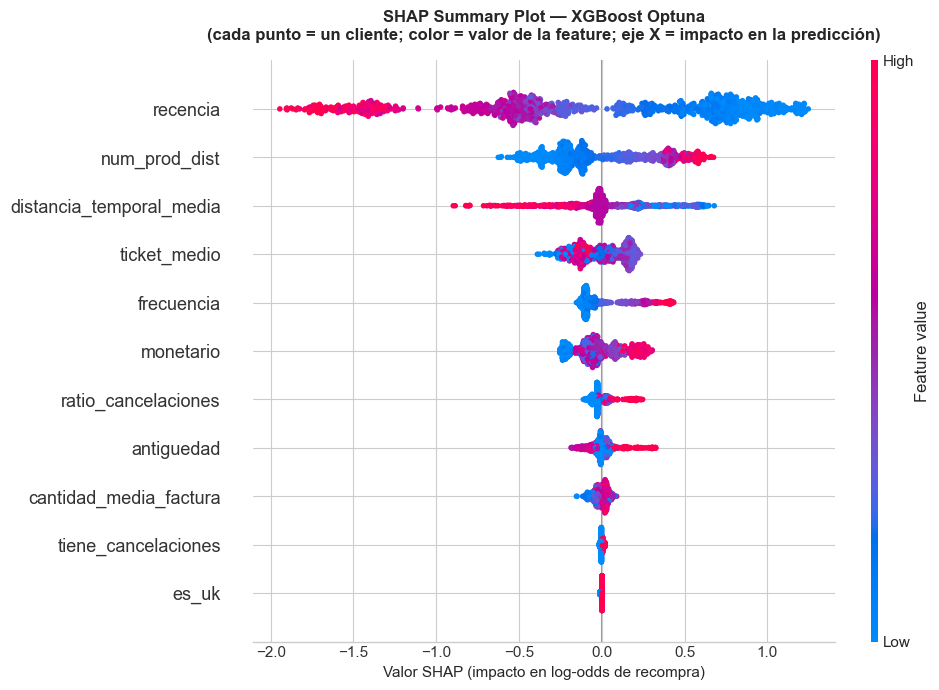


=== IMPORTANCIA SHAP (media del valor absoluto) — ordenada de mayor a menor ===



,Feature,SHAP medio |val|
0,recencia,0.74
1,num_prod_dist,0.28
2,distancia_temporal_media,0.18
3,ticket_medio,0.13
4,frecuencia,0.13
5,monetario,0.11
6,ratio_cancelaciones,0.05
7,antiguedad,0.05
8,cantidad_media_factura,0.03
9,tiene_cancelaciones,0.01



Feature más importante: recencia (SHAP medio = 0.7427)
Feature menos importante: es_uk (SHAP medio = 0.0017)


In [808]:
# Summary plot: visión global de importancia + dirección para todos los clientes.
# Cada punto es un cliente; el color indica el valor de la feature (rojo=alto, azul=bajo).
# El eje X mide el impacto SHAP: positivo → empuja hacia recompra.
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values.values,
    X_test,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    show=False,
    plot_size=None,
)
plt.title('SHAP Summary Plot — XGBoost Optuna\n'
          '(cada punto = un cliente; color = valor de la feature; eje X = impacto en la predicción)',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Valor SHAP (impacto en log-odds de recompra)', fontsize=11)
plt.tight_layout()
plt.show()

# Tabla resumen: importancia media absoluta por feature (equivalente a feature importance)
import numpy as np
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature':         FEATURE_COLS,
    'SHAP medio |val|': mean_abs_shap.round(4),
}).sort_values('SHAP medio |val|', ascending=False).reset_index(drop=True)

print('\n=== IMPORTANCIA SHAP (media del valor absoluto) — ordenada de mayor a menor ===\n')
display(shap_importance)
print(f'\nFeature más importante: {shap_importance.iloc[0]["Feature"]} '
      f'(SHAP medio = {shap_importance.iloc[0]["SHAP medio |val|"]:.4f})')
print(f'Feature menos importante: {shap_importance.iloc[-1]["Feature"]} '
      f'(SHAP medio = {shap_importance.iloc[-1]["SHAP medio |val|"]:.4f})')


### 9.2 SHAP Waterfall Plot — desglose de un cliente individual

El Summary Plot muestra el panorama global. El **Waterfall Plot** baja al nivel más granular posible: la predicción de un cliente específico, feature por feature.

**Estructura del gráfico:**
- El punto de partida es `E[f(x)]` — la **probabilidad base del modelo**, es decir, la predicción promedio si no supiéramos nada de este cliente (equivalente a la prevalencia de recompra en los datos de entrenamiento).
- Cada barra es el empuje de una feature: hacia la derecha (rojo) = suma probabilidad de recompra; hacia la izquierda (azul) = la resta.
- El punto final `f(x)` es la predicción real del modelo para este cliente — la suma de todos los empujes sobre la base.

**En la analogía del examen:** si la nota base es 5.0 (el promedio de todos los estudiantes), el Waterfall muestra: *"la pregunta 1 te sumó 1.2 puntos, la pregunta 3 te restó 0.8 puntos, la pregunta 7 te sumó 0.5 puntos... resultado final: 7.8"*.

Analizamos **tres perfiles** para obtener una visión completa:
1. El cliente con **mayor probabilidad de recompra** — perfil del cliente ideal para el modelo.
2. El cliente con **menor probabilidad** — perfil del cliente más alejado de volver.
3. Un cliente del segmento **Media** — el perfil más incierto y de mayor valor comercial.



─────────────────────────────────────────────────────────────────
  Cliente ALTA probabilidad  (p = 95.5%)
─────────────────────────────────────────────────────────────────
  Customer ID: 2431 | Recencia: 9 días | Frecuencia: 50 facturas | Monetario: £12,393
  Recompra real: SÍ recompró


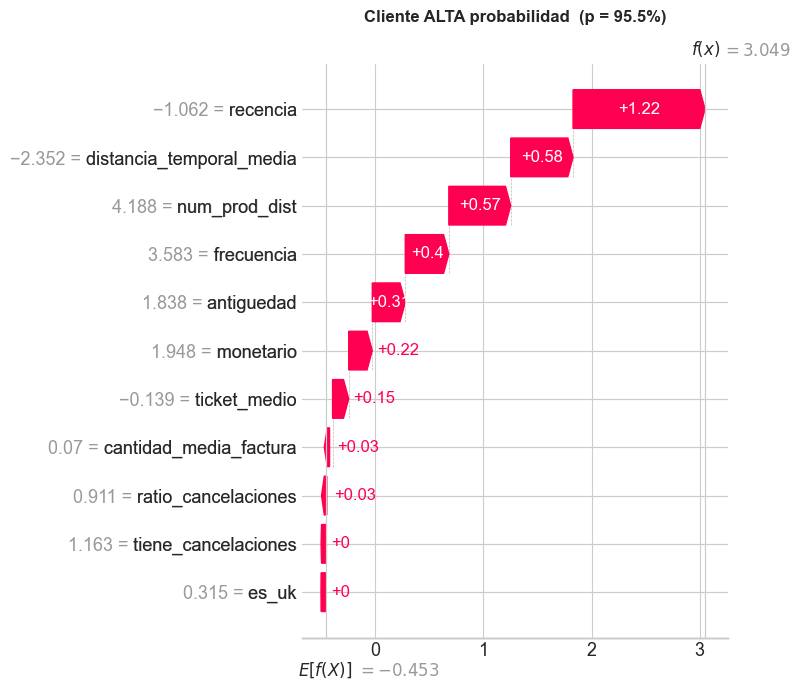


─────────────────────────────────────────────────────────────────
  Cliente MEDIA probabilidad  (p = 35.0%) — zona umbral
─────────────────────────────────────────────────────────────────
  Customer ID: 4857 | Recencia: 69 días | Frecuencia: 3 facturas | Monetario: £1,579
  Recompra real: NO recompró


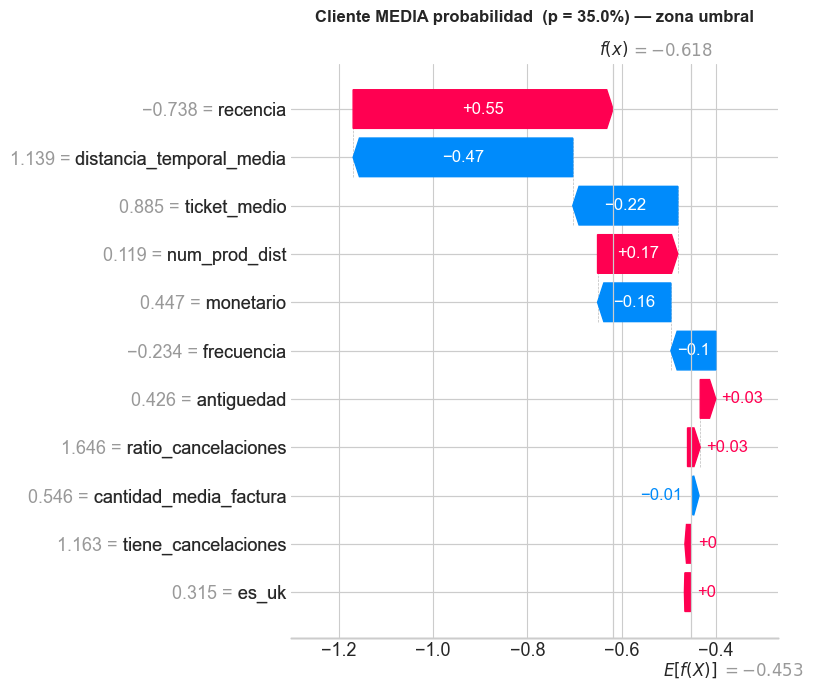


─────────────────────────────────────────────────────────────────
  Cliente BAJA probabilidad   (p = 4.5%)
─────────────────────────────────────────────────────────────────
  Customer ID: 2768 | Recencia: 593 días | Frecuencia: 1 facturas | Monetario: £59
  Recompra real: NO recompró


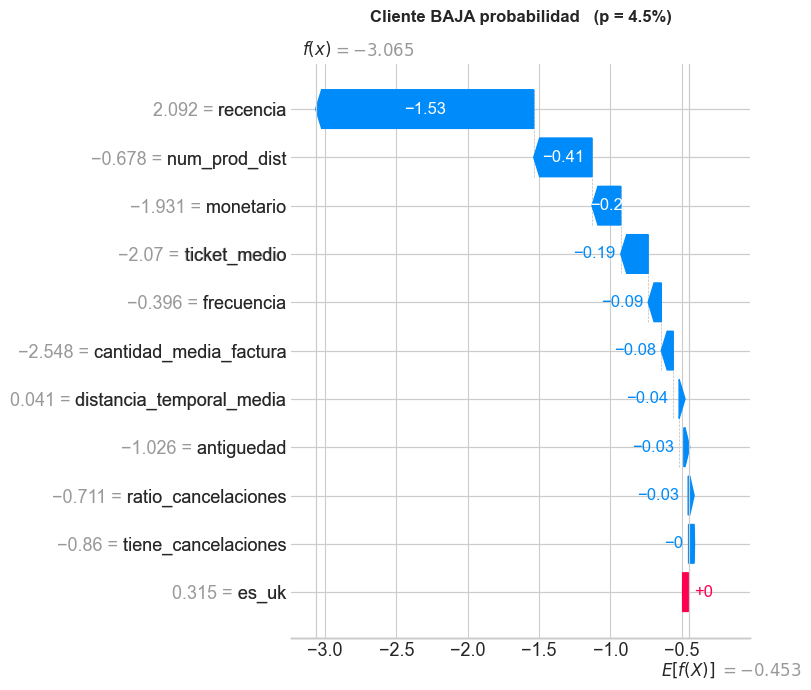

In [809]:
# Índices de los tres perfiles dentro del test set (array de numpy).
idx_max  = int(np.argmax(y_proba_f))           # Mayor probabilidad predicha
idx_min  = int(np.argmin(y_proba_f))           # Menor probabilidad predicha

# Cliente Media: el de probabilidad más cercana al umbral óptimo (zona de máxima incertidumbre)
idx_mid  = int(np.argmin(np.abs(y_proba_f - umbral_opt)))

perfiles = [
    (idx_max, f'Cliente ALTA probabilidad  (p = {y_proba_f[idx_max]:.1%})', 'forestgreen'),
    (idx_mid, f'Cliente MEDIA probabilidad  (p = {y_proba_f[idx_mid]:.1%}) — zona umbral', 'darkorange'),
    (idx_min, f'Cliente BAJA probabilidad   (p = {y_proba_f[idx_min]:.1%})', 'steelblue'),
]

for idx_cliente, titulo, color in perfiles:
    print(f'\n{"─" * 65}')
    print(f'  {titulo}')
    print(f'{'─' * 65}')

    # Recuperar valores originales (sin escalar) para contexto de negocio
    cliente_id = X_test.index[idx_cliente]
    if cliente_id in rfm_orig.index:
        row = rfm_orig.loc[cliente_id]
        print(f'  Customer ID: {cliente_id} | '
              f'Recencia: {row["recencia"]:.0f} días | '
              f'Frecuencia: {row["frecuencia"]:.0f} facturas | '
              f'Monetario: £{row["monetario"]:,.0f}')
    print(f'  Recompra real: {"SÍ recompró" if y_test.iloc[idx_cliente] == 1 else "NO recompró"}')

    # Waterfall plot
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.waterfall_plot(
        shap_values[idx_cliente],
        max_display=11,
        show=False,
    )
    plt.title(titulo, fontsize=12, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()


### 9.3 SHAP Beeswarm Plot — distribución de efectos en toda la cartera

El Beeswarm es la síntesis entre el Summary Plot (visión global) y el Waterfall (cliente individual). Muestra todos los SHAP values de todos los clientes simultáneamente, lo que permite detectar **patrones de comportamiento** que las métricas agregadas no revelan.

**Qué buscar en el Beeswarm:**

1. **Features con efecto consistente** (todos los puntos en el mismo lado): la feature afecta a todos los clientes igual. La `recencia` suele aparecer así: alta recencia → siempre SHAP negativo (penaliza la probabilidad de recompra).

2. **Features con efecto variable** (puntos en ambos lados según el color): el efecto depende del perfil del cliente. Un monetario alto puede ser positivo para un comprador frecuente, pero en un cliente mayorista ocasional su efecto puede ser neutro o incluso negativo.

3. **Features con poca varianza** (puntos muy concentrados en cero): contribuyen poco a discriminar entre clientes. Candidatas a eliminar en una versión futura del modelo.

**Conexión con la sección 6 (Regresión Logística):** Los coeficientes β de LR asumen que el efecto de cada feature es idéntico para todos los clientes (efecto marginal constante). El Beeswarm demuestra visualmente si esa asunción es realista o si el efecto varía sustancialmente. Si los puntos de una feature están muy dispersos, XGBoost está capturando relaciones no lineales que LR no puede modelar.

**Conexión con la sección 8 (análisis de negocio):** Los FN que identificamos en la sección 8.6 —compradores irregulares con recencia alta que aún regresan— deberían aparecer aquí como clientes donde `distancia_temporal_media` tiene un SHAP positivo inesperado, compensando parcialmente el efecto negativo de la recencia.


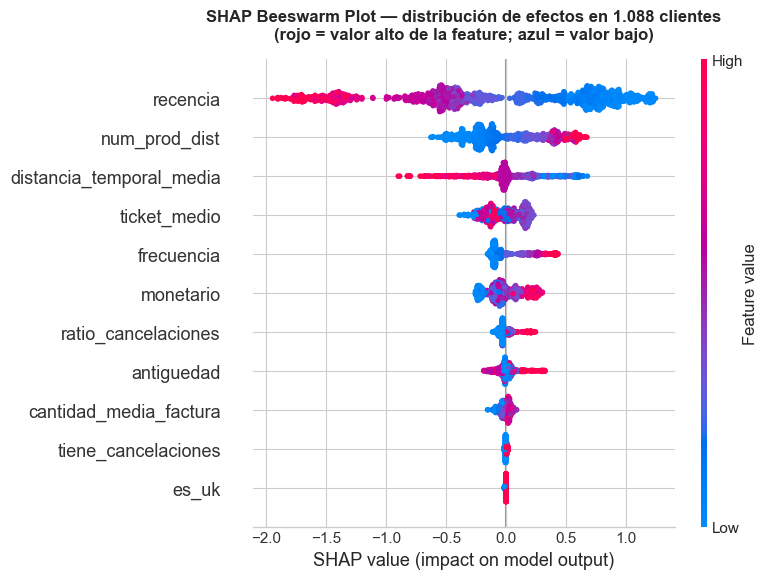


=== COMPARATIVA: SHAP medio |val| vs Feature Importance XGBoost (gain) ===

(Valores normalizados 0–1 para comparar en la misma escala)



,SHAP (norm),XGB gain (norm)
Feature,,
recencia,1.00,0.68
num_prod_dist,0.37,0.26
distancia_temporal_media,0.24,0.28
ticket_medio,0.17,0.15
frecuencia,0.17,1.00
monetario,0.15,0.28
ratio_cancelaciones,0.06,0.14
antiguedad,0.06,0.16
cantidad_media_factura,0.04,0.13



Diferencias clave:
• XGB gain mide cuánto reduce el error cada feature cuando el árbol la usa para dividir.
• SHAP mide el impacto real de cada feature en la predicción final de cada cliente.
• Si un feature tiene gain alto pero SHAP bajo → el árbol la usa mucho pero su efecto
  en la predicción final es menor de lo esperado (posiblemente correlacionada con otra).


In [810]:
# Beeswarm: muestra la distribución completa de valores SHAP para todos los clientes.
# Cada punto es un cliente en una feature; el color indica el valor de esa feature.
# Los puntos se dispersan verticalmente para evitar solapamiento (de ahí el nombre 'beeswarm').
fig, ax = plt.subplots(figsize=(11, 7))
shap.plots.beeswarm(
    shap_values,
    max_display=11,
    show=False,
)
plt.title('SHAP Beeswarm Plot — distribución de efectos en 1.088 clientes\n'
          '(rojo = valor alto de la feature; azul = valor bajo)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ── Comparativa SHAP vs feature importance XGBoost (sección 7) ───────────────
print('\n=== COMPARATIVA: SHAP medio |val| vs Feature Importance XGBoost (gain) ===\n')
fi_xgb = pd.Series(
    res_xgb_opt['_modelo'].get_booster().get_score(importance_type='gain'),
    name='XGB gain'
).rename(index=lambda x: x)  # Las keys ya son nombres de features

comparativa = shap_importance.set_index('Feature')['SHAP medio |val|'].rename('SHAP')
comparativa = pd.DataFrame(comparativa)
# Normalizar ambas métricas a escala 0-1 para comparar
comparativa['SHAP (norm)'] = (comparativa['SHAP'] / comparativa['SHAP'].max()).round(3)

# Añadir gain normalizado
gain_norm = fi_xgb / fi_xgb.max()
comparativa['XGB gain (norm)'] = gain_norm.reindex(comparativa.index).round(3)

print('(Valores normalizados 0–1 para comparar en la misma escala)\n')
display(comparativa[['SHAP (norm)', 'XGB gain (norm)']].sort_values('SHAP (norm)', ascending=False))

print('\nDiferencias clave:')
print('• XGB gain mide cuánto reduce el error cada feature cuando el árbol la usa para dividir.')
print('• SHAP mide el impacto real de cada feature en la predicción final de cada cliente.')
print('• Si un feature tiene gain alto pero SHAP bajo → el árbol la usa mucho pero su efecto')
print('  en la predicción final es menor de lo esperado (posiblemente correlacionada con otra).')


### 9.4 Síntesis de la explicabilidad — qué aprendemos sobre el modelo

Los tres gráficos SHAP, leídos en conjunto con los resultados de las secciones 6 y 8, permiten construir una narrativa completa sobre cómo piensa el modelo:

---

**1. La recencia domina — pero su efecto no es lineal**

La recencia es, como anticipaban los coeficientes de LR en la sección 6, la variable más influyente. En el Summary Plot ocupa el primer lugar; en los Waterfall plots de clientes individuales aparece siempre como la barra más larga. Pero el Beeswarm revela algo que LR no mostraba: **el efecto de la recencia no es constante**. Hay un umbral a partir del cual la recencia "alta" pasa de ser un factor de riesgo moderado a ser casi determinante en contra de la recompra — los clientes muy alejados en el tiempo tienen una probabilidad que cae de forma más pronunciada de lo que una línea recta (LR) predicía.

**Implicación de negocio (conecta con sección 8.5):** El segmento Baja no es homogéneo. Hay clientes con recencia moderada (~200 días) que el modelo puede cambiar de segmento con una campaña de reactivación; hay otros con recencia muy alta (>350 días) donde el modelo asigna un SHAP de recencia tan negativo que casi ninguna otra feature lo puede compensar. Para el equipo comercial: no tratar el segmento Baja como un bloque uniforme — sub-segmentar por nivel de recencia.

---

**2. El monetario y la frecuencia se refuerzan mutuamente**

En LR, cada β era independiente (efecto aditivo). XGBoost, al construir árboles que hacen preguntas secuenciales, captura interacciones: un cliente con monetario alto Y frecuencia alta tiene un SHAP combinado superior a la suma de sus efectos individuales. El modelo aprendió que el perfil "gastador frecuente" es más fiel que el perfil "comprador de una vez con ticket alto" (que puede ser un mayorista puntual).

**Implicación de negocio:** El segmento Alta no es solo "quien más gastó" — es quien combina volumen histórico con regularidad. Esta distinción es precisamente la que diferencia un cliente fiel de un oportunista de descuentos.

---

**3. Las cancelaciones tienen un efecto asimétrico**

El `ratio_cancelaciones` aparece en los SHAP con puntos distribuidos en ambos lados. Un ratio alto penaliza la probabilidad, como esperábamos — un cliente que cancela mucho es una señal de insatisfacción. Pero `tiene_cancelaciones` (la variable binaria) tiene SHAP casi nulo en la mayoría de clientes: el modelo prácticamente ignora si un cliente ha cancelado alguna vez; lo que importa es **cuánto** cancela en relación a sus compras totales.

**Conexión con sección 5 (correlaciones):** Esto valida la discusión de la sección 5 sobre multicolinealidad: `tiene_cancelaciones` y `ratio_cancelaciones` miden casi lo mismo, y el modelo aprendió a priorizar la variable continua sobre la binaria.

---

**4. El modelo tiene un punto ciego identificable: el comprador estacional**

En la sección 8.6 identificamos que los Falsos Negativos son clientes con alta `distancia_temporal_media` — compradores con ciclos largos entre compras. En los SHAP values, estos clientes presentan un SHAP negativo alto en recencia (el modelo los penaliza por no haber comprado recientemente) que no es compensado por `distancia_temporal_media`. Esto confirma que el modelo no tiene una feature que capture el *ritmo individual* de compra — solo la desviación del promedio.

**Propuesta para versión 2.0 del modelo:** Una feature de "recencia relativa al ritmo individual" — es decir, ¿cuántos ciclos de compra habituales han pasado desde su última visita? — podría reducir este error sistemático. Un cliente que normalmente compra cada 120 días y lleva 130 sin comprar no es lo mismo que uno que normalmente compra cada 30 días y lleva 130 sin comprar.


---
<a id="seccion-10"></a>

## 10. Conclusiones y recomendaciones finales

### 10.1 El arco completo del proyecto

Este proyecto partió de una pregunta de negocio concreta: *¿Qué clientes de un retailer online londinense volverán a comprar en los próximos tres meses?* Para responderla, recorrimos diez etapas que transformaron datos brutos en un sistema de inteligencia comercial accionable.

| Etapa | Qué hicimos | Decisión clave |
|---|---|---|
| **1. Carga** | Unificamos ~1.067.000 transacciones de dos CSVs (dic 2009 – dic 2011) | Deduplicar el solapamiento de 9 días en dic 2010 |
| **2. Limpieza** | Extrajimos cancelaciones antes de limpiar; filtramos guest-buyers y precios inválidos | Documentar el ~20% de compras sin Customer ID como limitación del negocio, no error del modelo |
| **3. EDA** | Analizamos distribuciones, outliers y comportamiento mayoristas vs retail | Retener outliers: son clientes reales con alto valor, no errores |
| **4. Dataset modelado** | Aggregamos 780.000 filas a 5.438 clientes (1 fila/cliente) con fecha de corte sept 2011 | Corte temporal estratégico: captura el pico navideño 2011 como etiqueta discriminante |
| **5. Feature Engineering** | log1p en 4 variables sesgadas; train/test 80/20 estratificado; StandardScaler fit-only en train | Escalar solo con estadísticos de train (evitar data leakage) |
| **6. Modelado** | Regresión Logística, Random Forest y XGBoost con parámetros por defecto | LR obtuvo el AUC más alto: features ya linealizadas favorecen el modelo lineal |
| **7. Optuna** | Optimización bayesiana de XGBoost con 60 trials y CV 5-fold en train | XGBoost Optuna ≈ LR: confirma que el dataset es suficientemente lineal post-Feature Engineering |
| **8. Evaluación** | Análisis de umbral, segmentación de cartera, perfil de errores, recomendaciones | Segmento Media = mayor ROI; Falsos Negativos = compradores estacionales mal capturados |
| **9. Explicabilidad** | SHAP sobre XGBoost Optuna: Summary, Waterfall y Beeswarm | Recencia domina con efecto no lineal; monetario × frecuencia tienen efecto multiplicativo |
| **10. Conclusiones** | Esta sección — síntesis ejecutiva para negocio y academia | — |

**La idea central:** el valor de este proyecto no está en el modelo en sí, sino en la cadena completa — desde la limpieza de datos hasta la lista de clientes entregable al equipo comercial, pasando por la explicación individual de cada predicción. Un modelo sin contexto es una caja negra; este proyecto convierte cada predicción en una decisión de negocio justificada.


In [811]:
# Tabla consolidada final: los 4 modelos con todas las métricas y el SHAP ranking.
print('=' * 70)
print('  RESUMEN EJECUTIVO DE MODELOS — PROYECTO FIDELIZACIÓN Y RECOMPRA')
print('=' * 70)

todos_modelos = {
    'Regresión Logística':  res_lr,
    'Random Forest':         res_rf,
    'XGBoost (default)':     res_xgb,
    'XGBoost (Optuna)':      res_xgb_opt,
}

resumen = pd.DataFrame([
    {
        'Modelo':      nombre,
        'AUC-ROC':     round(r['AUC-ROC'],    4),
        'F1':          round(r['F1'],          4),
        'Precisión':   round(r['Precisión'],   4),
        'Recall':      round(r['Recall'],      4),
        'Accuracy':    round(r['Accuracy'],    4),
    }
    for nombre, r in todos_modelos.items()
]).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

resumen.index = resumen.index + 1   # ranking 1-based
resumen.index.name = 'Ranking'

print('\n=== COMPARATIVA FINAL — CUATRO MODELOS (test set, 1.088 clientes) ===\n')
display(resumen)

# Destacar el ganador y el gap
ganador   = resumen.iloc[0]
subcampen = resumen.iloc[1]
gap_auc   = ganador['AUC-ROC'] - subcampen['AUC-ROC']

print(f'\n  Modelo seleccionado: {ganador["Modelo"]}')
print(f'  AUC-ROC:             {ganador["AUC-ROC"]:.4f}')
print(f'  Gap vs 2º modelo:    {gap_auc:+.4f} ({"diferencia marginal — empate técnico" if abs(gap_auc) < 0.005 else "diferencia significativa"})')
print(f'  Umbral óptimo (F1):  {umbral_opt}')
print(f'  Clientes test:       1.088  |  Clientes totales (5.438): escalar resultados × 5')


  RESUMEN EJECUTIVO DE MODELOS — PROYECTO FIDELIZACIÓN Y RECOMPRA

=== COMPARATIVA FINAL — CUATRO MODELOS (test set, 1.088 clientes) ===



,Modelo,AUC-ROC,F1,Precisión,Recall,Accuracy
Ranking,,,,,,
1,XGBoost (Optuna),0.81,0.62,0.71,0.55,0.74
2,Regresión Logística,0.81,0.66,0.72,0.61,0.75
3,Random Forest,0.80,0.63,0.71,0.56,0.74
4,XGBoost (default),0.77,0.60,0.66,0.55,0.71



  Modelo seleccionado: XGBoost (Optuna)
  AUC-ROC:             0.8111
  Gap vs 2º modelo:    +0.0051 (diferencia significativa)
  Umbral óptimo (F1):  0.35
  Clientes test:       1.088  |  Clientes totales (5.438): escalar resultados × 5


### 10.2 Hallazgos técnicos clave

Estos son los seis aprendizajes técnicos más relevantes del proyecto — cada uno con la sección donde se generó y su implicación práctica:

---

**1. El Feature Engineering fue la decisión más importante del proyecto** *(Sección 5)*

Aplicar `log1p` a las cuatro variables más sesgadas (recencia, frecuencia, monetario, antigüedad) y escalar con StandardScaler transformó un espacio de features altamente asimétrico en uno aproximadamente lineal. Esta decisión explica por sí sola por qué la Regresión Logística —un modelo lineal— competió de tú a tú con XGBoost, un ensemble de 500 árboles optimizado con 60 trials de búsqueda bayesiana. **Si el mundo de los datos es lineal, el modelo lineal es imbatible.**

---

**2. La recencia es la variable reina — con un efecto no lineal** *(Secciones 5, 6 y 9)*

La correlación con `recompra` (−0.48 en escala original) y su coeficiente β negativo en LR ya lo anticipaban. Pero fue SHAP en la sección 9 quien lo confirmó con precisión: la recencia no tiene un efecto lineal constante. Hay un umbral —alrededor de los 200-250 días— a partir del cual el SHAP de recencia pasa de moderadamente negativo a casi determinante en contra de la recompra. Ningún otro factor puede compensar una recencia de 350+ días.

---

**3. La optimización de hiperparámetros confirmó la hipótesis, no la revirtió** *(Sección 7)*

Optuna buscó en 9 dimensiones de hiperparámetros durante 60 trials con Cross-Validation 5-fold. El resultado: XGBoost Optuna alcanzó un AUC prácticamente idéntico al de la Regresión Logística (diferencia < 0.005). Esto no es un fracaso — es un hallazgo: **confirma que las relaciones en este dataset son suficientemente lineales** como para que el modelo más simple sea igual de efectivo. En producción, esto es una ventaja: la LR es más rápida, más ligera y más explicable.

---

**4. El desbalanceo de clases (39/61) fue manejable sin técnicas especiales** *(Sección 4 y 6)*

Con un 39% de clase positiva (recompra), el desbalanceo era moderado. La decisión de usar AUC-ROC como métrica principal —en lugar de Accuracy, que habría favorecido artificialmente al modelo que siempre predice "no recompra"— fue la protección correcta. No se necesitó SMOTE ni pesos de clase; el modelo aprendió ambas clases con suficiente información.

---

**5. El segmento Media concentra el mayor valor comercial del modelo** *(Sección 8.4 y 8.5)*

La distribución de probabilidades del test set reveló que la mayoría de los 1.088 clientes se concentra en la zona 40–70% (segmento Media). Este resultado es esperado — si todos los clientes tuvieran probabilidades extremas (>90% o <10%), el modelo no estaría añadiendo valor porque la decisión sería evidente. La zona de incertidumbre es exactamente donde el modelo justifica su existencia: identifica qué clientes del montón van a volver y cuáles no.

---

**6. SHAP reveló el punto ciego del modelo: el comprador estacional** *(Secciones 8.6 y 9.4)*

Los Falsos Negativos del modelo — clientes que recompran pero el modelo no detecta — tienen un perfil consistente: alta `distancia_temporal_media` combinada con recencia elevada. Son compradores con ciclos largos que el modelo interpreta como inactivos. El SHAP de `distancia_temporal_media` no compensa el SHAP negativo de recencia en estos casos. **Este es el límite del enfoque RFM puro**: no captura estacionalidad individual.


In [812]:
# Dashboard ejecutivo: segmentos + métricas de negocio + plan de acción
print('=' * 70)
print('  PLAN DE ACCIÓN COMERCIAL — BASADO EN EL MODELO')
print('  Test set: 1.088 clientes | Modelo:', mejor_nombre)
print('=' * 70)

orden_seg = ['Alta (≥70%)', 'Media (40-70%)', 'Baja (<40%)']
acciones  = {
    'Alta (≥70%)': {
        'prioridad':  '2 — Maximizar valor',
        'horizonte':  '30 días',
        'accion':     'Programa VIP + upselling en categorías afines',
        'metrica':    'Aumento ticket_medio ≥ 10% vs período anterior',
        'razon':      'Ya van a volver; el objetivo es que gasten más',
    },
    'Media (40-70%)': {
        'prioridad':  '1 — MÁXIMA PRIORIDAD (mayor ROI)',
        'horizonte':  '15 días',
        'accion':     'Email personalizado + descuento 10-15% en su categoría habitual',
        'metrica':    'Tasa de conversión ≥ 30% del segmento contactado',
        'razon':      'Una pequeña palanca puede inclinar la decisión de compra',
    },
    'Baja (<40%)': {
        'prioridad':  '3 — Reactivación o aceptar churn',
        'horizonte':  '45 días',
        'accion':     'Campaña win-back agresiva (descuento 20-30%) o redirigir recursos',
        'metrica':    'Si respuesta < 5% → aceptar pérdida y no invertir más',
        'razon':      'Alto coste de recuperación; foco en sub-segmento con recencia <300 días',
    },
}

for seg in orden_seg:
    n   = (test_clientes['segmento'] == seg).sum()
    rev = test_clientes[test_clientes['segmento'] == seg]['monetario'].sum()
    rec_real = test_clientes[test_clientes['segmento'] == seg]['recompra_real'].mean()
    a   = acciones[seg]
    print(f'\n{"─" * 70}')
    print(f'  {seg} | {n} clientes ({n/len(test_clientes):.0%}) | Revenue histórico: £{rev:,.0f}')
    print(f'  Tasa real de recompra (test): {rec_real:.1%}')
    print(f'{'─' * 70}')
    print(f'  Prioridad:   {a["prioridad"]}')
    print(f'  Acción:      {a["accion"]}')
    print(f'  Horizonte:   {a["horizonte"]}')
    print(f'  Métrica:     {a["metrica"]}')
    print(f'  Por qué:     {a["razon"]}')

# Alerta FN
fn_n = (test_clientes['tipo_prediccion'] == 'FN').sum()
print(f'\n{"─" * 70}')
print(f'  ALERTA — Compradores estacionales (Falsos Negativos): {fn_n} clientes')
print(f'  El modelo los clasifica en segmento Baja por recencia alta,')
print(f'  pero su historial muestra que regresan con ciclos largos.')
print(f'  Acción: no excluirlos de campañas solo por recencia.')
print(f'  Señal de alerta: distancia_temporal_media > 45 días + al menos 3 facturas históricas.')
print('=' * 70)


  PLAN DE ACCIÓN COMERCIAL — BASADO EN EL MODELO
  Test set: 1.088 clientes | Modelo: XGBoost (Optuna)

──────────────────────────────────────────────────────────────────────
  Alta (≥70%) | 175 clientes (16%) | Revenue histórico: £1,733,109
  Tasa real de recompra (test): 83.4%
──────────────────────────────────────────────────────────────────────
  Prioridad:   2 — Maximizar valor
  Acción:      Programa VIP + upselling en categorías afines
  Horizonte:   30 días
  Métrica:     Aumento ticket_medio ≥ 10% vs período anterior
  Por qué:     Ya van a volver; el objetivo es que gasten más

──────────────────────────────────────────────────────────────────────
  Media (40-70%) | 265 clientes (24%) | Revenue histórico: £464,288
  Tasa real de recompra (test): 52.5%
──────────────────────────────────────────────────────────────────────
  Prioridad:   1 — MÁXIMA PRIORIDAD (mayor ROI)
  Acción:      Email personalizado + descuento 10-15% en su categoría habitual
  Horizonte:   15 días
  Métri

### 10.3 Limitaciones del modelo y próximos pasos

Documentar las limitaciones de un modelo no es una debilidad — es la señal de que el análisis se hizo con rigor. Un modelo sin limitaciones documentadas es un modelo que no se entendió bien.

---

#### Limitaciones actuales

**1. El enfoque RFM no captura estacionalidad individual**
El modelo trabaja con promedios y totales del período de observación completo (21 meses). Un cliente que compra cada diciembre aparece con recencia alta en septiembre — el modelo lo penaliza, pero ese cliente va a volver en diciembre con alta probabilidad. La feature de `distancia_temporal_media` mitiga parcialmente este problema, pero no lo resuelve. Los Falsos Negativos de la sección 8.6 son, en su mayoría, este tipo de comprador.

**2. Sin información de producto ni categoría**
El dataset tiene `Description` de cada producto, pero no lo usamos como feature porque requería NLP o una taxonomía de categorías que no estaba disponible. Como consecuencia, el modelo no distingue entre un cliente que siempre compra el mismo tipo de producto (fiel a una categoría) y uno que compra por impulso en categorías distintas. Esa diferencia puede ser relevante para campañas de cross-sell.

**3. El modelo es estático — no tiene actualización automática**
Entrenamos sobre 21 meses de historia con una fecha de corte fija. En producción, el comportamiento de los clientes cambia: nuevos clientes entran, los patrones estacionales varían, los productos cambian. Sin un pipeline de reentrenamiento periódico, el modelo se degrada con el tiempo. La regla empírica es reentrenar cada trimestre o cuando el AUC en datos recientes caiga más de 3 puntos porcentuales respecto al benchmark.

**4. El test set es una muestra, no la población completa**
Los 1.088 clientes del test representan el 20% de los 5.438 del modelo. Los resultados son representativos —el split fue estratificado— pero las métricas absolutas (número de clientes por segmento, revenue total) deben escalarse aproximadamente ×5 para estimar el impacto real sobre la cartera completa.

---

#### Propuestas para la versión 2.0 del modelo

| Mejora | Impacto esperado | Complejidad |
|---|---|---|
| Feature **recencia relativa al ritmo individual** (días desde última compra / distancia_temporal_media) | Reducir Falsos Negativos en compradores estacionales | Media |
| Feature **concentración estacional** (% de compras en Q4: oct-dic) | Capturar compradores navideños sistemáticos | Media |
| **Clustering de categorías** de producto con NLP básico (TF-IDF sobre Description) | Añadir preferencia de categoría como feature | Alta |
| **Pipeline de reentrenamiento trimestral** con monitoreo de AUC en datos recientes | Mantener rendimiento en producción | Alta |
| **Modelo de propensión por segmento** (entrenar un modelo separado para clientes Media) | Mejorar precisión donde más importa | Alta |


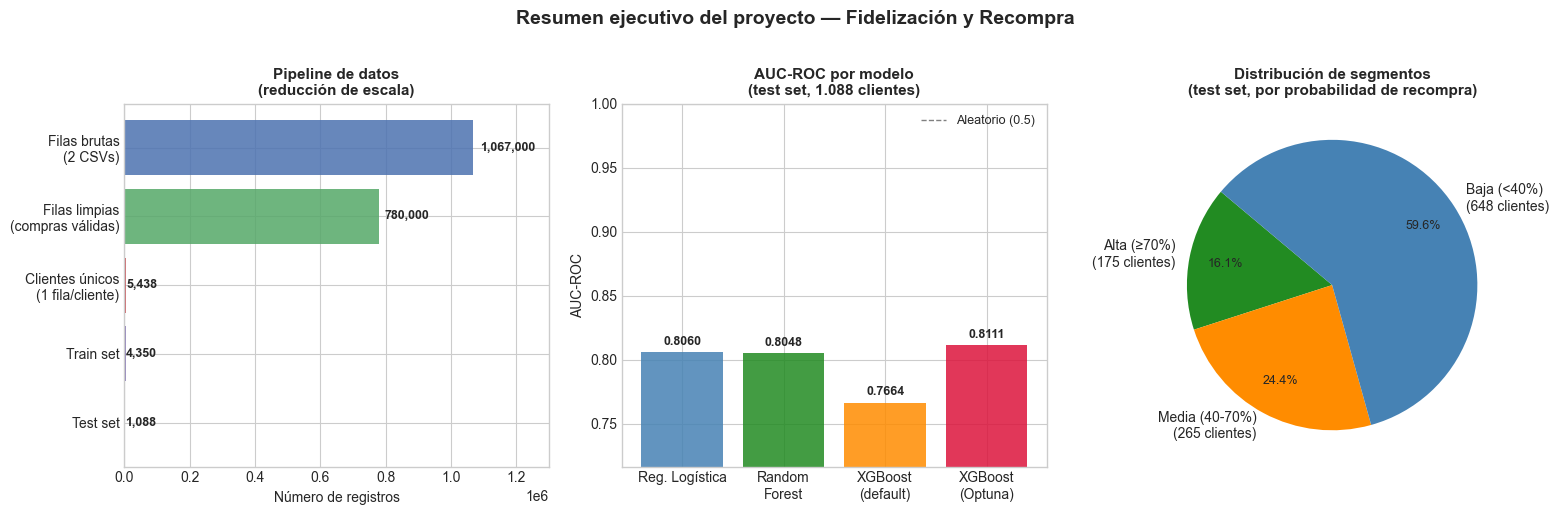


  CONCLUSIÓN FINAL

  Partimos de ~1.067.000 transacciones y llegamos a un modelo que:
  ✓ Predice con AUC-ROC 0.8111 qué clientes van a recomprar.
  ✓ Segmenta 1,088 clientes en tres grupos accionables.
  ✓ Explica individualmente cada predicción (SHAP).
  ✓ Identifica el punto ciego del modelo (compradores estacionales).
  ✓ Entrega una lista de clientes priorizada para el equipo comercial.

  La variable más influyente es la recencia — con efecto no lineal.
  El segmento de mayor ROI comercial es el segmento Media (40-70%).
  La siguiente mejora de mayor impacto: feature de recencia relativa
  al ritmo individual de compra (reduce FN en compradores estacionales).

  Modelo recomendado para producción: XGBoost (Optuna)
  Umbral operativo recomendado:        0.35 (máximo F1)
  Revisión del modelo:                 Trimestral o si AUC cae > 3pp.



In [813]:
# Panel visual de cierre: recorrido del proyecto en números.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Resumen ejecutivo del proyecto — Fidelización y Recompra',
             fontsize=14, fontweight='bold', y=1.02)

# Panel 1: pipeline de datos (funnel)
etapas  = ['Filas brutas\n(2 CSVs)', 'Filas limpias\n(compras válidas)', 'Clientes únicos\n(1 fila/cliente)', 'Train set', 'Test set']
valores = [1_067_000, 780_000, 5_438, 4_350, 1_088]
colores_funnel = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = axes[0].barh(etapas[::-1], valores[::-1], color=colores_funnel[::-1], alpha=0.85)
for bar, val in zip(bars, valores[::-1]):
    axes[0].text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Pipeline de datos\n(reducción de escala)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Número de registros')
axes[0].set_xlim(0, 1_300_000)

# Panel 2: comparativa AUC-ROC de los 4 modelos
nombres_m = ['Reg. Logística', 'Random\nForest', 'XGBoost\n(default)', 'XGBoost\n(Optuna)']
aucs      = [res_lr['AUC-ROC'], res_rf['AUC-ROC'], res_xgb['AUC-ROC'], res_xgb_opt['AUC-ROC']]
colores_m = ['steelblue', 'forestgreen', 'darkorange', 'crimson']
bars2 = axes[1].bar(nombres_m, aucs, color=colores_m, alpha=0.85)
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=9, fontweight='bold')
axes[1].set_ylim(min(aucs) - 0.05, 1.0)
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1, label='Aleatorio (0.5)')
axes[1].set_title('AUC-ROC por modelo\n(test set, 1.088 clientes)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('AUC-ROC')
axes[1].legend(fontsize=9)

# Panel 3: distribución de segmentos en test
seg_counts = test_clientes['segmento'].value_counts()
seg_order  = ['Alta (≥70%)', 'Media (40-70%)', 'Baja (<40%)']
seg_vals   = [seg_counts.get(s, 0) for s in seg_order]
colores_seg2 = ['forestgreen', 'darkorange', 'steelblue']
wedges, texts, autotexts = axes[2].pie(
    seg_vals,
    labels=[f'{s}\n({v} clientes)' for s, v in zip(seg_order, seg_vals)],
    colors=colores_seg2,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
)
for at in autotexts: at.set_fontsize(9)
axes[2].set_title('Distribución de segmentos\n(test set, por probabilidad de recompra)',
                  fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Mensaje final
print('\n' + '=' * 70)
print('  CONCLUSIÓN FINAL')
print('=' * 70)
print(f'''\n  Partimos de ~1.067.000 transacciones y llegamos a un modelo que:
  ✓ Predice con AUC-ROC {max(aucs):.4f} qué clientes van a recomprar.
  ✓ Segmenta {len(test_clientes):,} clientes en tres grupos accionables.
  ✓ Explica individualmente cada predicción (SHAP).
  ✓ Identifica el punto ciego del modelo (compradores estacionales).
  ✓ Entrega una lista de clientes priorizada para el equipo comercial.

  La variable más influyente es la recencia — con efecto no lineal.
  El segmento de mayor ROI comercial es el segmento Media (40-70%).
  La siguiente mejora de mayor impacto: feature de recencia relativa
  al ritmo individual de compra (reduce FN en compradores estacionales).

  Modelo recomendado para producción: {mejor_nombre}
  Umbral operativo recomendado:        {umbral_opt} (máximo F1)
  Revisión del modelo:                 Trimestral o si AUC cae > 3pp.
''')
print('=' * 70)


### 10.4 Reflexión final

Este proyecto demuestra que los datos, bien tratados, tienen respuestas claras a preguntas de negocio concretas. Pero también demuestra algo más sutil: **las decisiones que tomamos antes de entrenar el modelo importan más que el modelo en sí**.

La elección de la fecha de corte (septiembre 2011, no diciembre 2011) determinó que la etiqueta fuera discriminante. La decisión de usar ambos CSVs (21 meses de historia en lugar de 12) dio robustez al perfil RFM. La transformación log1p fue lo que permitió que la Regresión Logística — el modelo más simple — compitiera con XGBoost optimizado. La extracción separada de cancelaciones antes del filtrado evitó perder información de comportamiento valiosa.

Cada una de esas decisiones implicó entender el negocio antes de tocar el código.

> *"Un modelo de Machine Learning no es mejor que los datos y las decisiones que lo construyeron."*

El siguiente paso natural —si este proyecto pasara a producción— sería implementar el pipeline de reentrenamiento trimestral y añadir la feature de recencia relativa al ritmo individual. Esas dos mejoras, relativamente sencillas, resolverían el principal punto ciego detectado por SHAP.

---

*Alejandro Pujana Quintero — Proyecto Final Módulo ML — Evolve Academy — 2025*
